# Explainable AI for COVID-19 mortality prediction

Airidas Radzvilas and Alexander Kralev, University of Twente

We predict whether a COVID-19 patient dies using three blood biomarkers (LDH, CRP and lymphocyte %) from the Tongji Hospital dataset (Yan et al., 2020). Then we compare how well different XAI methods explain those predictions.

Two ways of looking at the data:
- **Tabular:** each patient becomes one row of 30 summary features, explained with SHAP and LIME.
- **Temporal:** each patient stays a sequence of measurements, fed to an LSTM and explained with Gradient x Input and WindowSHAP.

The data files (`time_series_375_preprocess_en.xlsx` and `time_series_test_110_preprocess_en.xlsx`) need to be in the same folder as this notebook.

## Setup
Install the libraries and check they import.

In [1]:

!pip install --upgrade xgboost --quiet         # main model
!pip install --upgrade shap --quiet
!pip install --upgrade lime --quiet
!pip install --upgrade lightgbm --quiet

!pip install --upgrade seaborn --quiet

# check everything imports
import importlib, sys

required = {
    "xgboost": "xgboost",
    "shap": "shap",
    "lime": "lime",
    "lightgbm": "lightgbm",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
}

print("=" * 45)
print("Library check:")
all_ok = True
for module, display_name in required.items():
    try:
        importlib.import_module(module)
        print(f"  [OK]  {display_name}")
    except ImportError:
        print(f"  [MISSING]  {display_name} - re-run install cell")
        all_ok = False
    except AttributeError as e:
        print(f"  [VERSION CONFLICT]  {display_name} - {e}")
        print(f"      -> Go to Runtime > Restart session, then re-run Cell 1.")
        all_ok = False

print("=" * 45)
if all_ok:
    print("All libraries ready. Proceed to Cell 2.")
else:
    print("Fix missing/conflicting libraries before continuing.")
    print("If you see a VERSION CONFLICT above: Runtime > Restart session,")
    print("then re-run this cell once (no need to reinstall again).")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Library check:
  [OK]  xgboost
  [OK]  shap
  [OK]  lime
  [OK]  lightgbm
  [OK]  scikit-learn
  [OK]  pandas
  [OK]  numpy
  [OK]  matplotlib
  [OK]  seaborn
  [OK]  scipy
All libraries ready. Proceed to Cell 2.


XGBoost 3 doesn't work with SHAP's TreeExplainer, so we check the version.

In [2]:
import xgboost, shap
print("xgboost", xgboost.__version__)   # needs to be < 3.0 for TreeExplainer
print("shap", shap.__version__)

xgboost 3.2.0
shap 0.49.1


Imports and the settings used in the rest of the notebook.

In [3]:

import os
import time
import warnings
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    classification_report,
)
from sklearn.calibration import calibration_curve

# xgboost, with a fallback if it breaks
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("[OK] XGBoost loaded")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print(f"[WARN] XGBoost failed to load ({type(e).__name__}) - will use HistGradientBoostingClassifier as fallback")
    print(f"       If this looks like a version conflict: Runtime > Restart session, then re-run from Cell 1.")

try:
    import shap
    SHAP_AVAILABLE = True
    print("[OK] SHAP loaded")
except Exception as e:
    SHAP_AVAILABLE = False
    raise ImportError(
        f"SHAP failed to load ({type(e).__name__}: {e}). "
        f"SHAP is required for this project. "
        f"Go to Runtime > Restart session, then re-run Cell 1 and this cell."
    )

try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
    print("[OK] LIME loaded")
except Exception as e:
    LIME_AVAILABLE = False
    print("[WARN] LIME not found - LIME cells will be skipped")

from scipy.stats import spearmanr

# settings

RANDOM_STATE    = 42
VAL_SIZE        = 0.20        # part of train used for validation
NOISE_SCALE     = 0.05        # noise for the stability test (5% of std)
LIME_N_SAMPLES  = 5000
FLIPPING_K_LIST = [1, 3, 5, 10, 20]  # k values for the deletion test
TOP_K_SPARSITY  = [3, 5, 10]
N_BOOTSTRAP     = 1000        # for the CIs, test set has few deaths

# time windows (hours after admission), None = whole stay
TIME_WINDOWS_HOURS = {
    "full": None,
    "24h":  24,
    "48h":  48,
    "72h":  72,
}

# the 3 biomarkers that are in both files, renamed to short names
BIOMARKER_RENAME = {
    "Lactate dehydrogenase":            "LDH",
    "Hypersensitive c-reactive protein":"CRP",
    "(%)lymphocyte":                    "LYMPH",
}
BIOMARKERS = list(BIOMARKER_RENAME.values())

# output folder

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"[OK] Output folder ready at: {OUTPUT_DIR.resolve()}")

# plot style

plt.rcParams.update({
    "figure.dpi":       150,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

print()
print("=" * 45)
print("All imports done. Settings confirmed.")
print(f"  Random state : {RANDOM_STATE}")
print(f"  Val size     : {VAL_SIZE}")
print(f"  Outputs      : {OUTPUT_DIR}/")
print("=" * 45)

[OK] XGBoost loaded
[OK] SHAP loaded
[OK] LIME loaded
[OK] Output folder ready at: /home/jovyan/XAI/XAI_research /outputs

All imports done. Settings confirmed.
  Random state : 42
  Val size     : 0.2
  Outputs      : outputs/


## Loading the data
The data has one row per measurement, and `PATIENT_ID` is only filled in on each patient's first row. We forward-fill it, otherwise grouping by patient would drop almost all rows. We also compute the hours since admission for every measurement, which we need for the time windows later.

In [4]:
TRAIN_PATH = "time_series_375_preprocess_en.xlsx"
TEST_PATH  = "time_series_test_110_preprocess_en.xlsx"

# 1. Load and forward-fill

print("Loading training file...")
df_train_raw = pd.read_excel(TRAIN_PATH)
print(f"  Shape before ffill: {df_train_raw.shape}")
print(f"  Blank PATIENT_ID rows: {df_train_raw['PATIENT_ID'].isnull().sum()} / {len(df_train_raw)}")

df_train_raw["PATIENT_ID"] = df_train_raw["PATIENT_ID"].ffill()
print(f"  Patients after ffill: {df_train_raw['PATIENT_ID'].nunique()}")

print("\nLoading test file...")
df_test_raw = pd.read_excel(TEST_PATH)
print(f"  Shape before ffill: {df_test_raw.shape}")
print(f"  Blank PATIENT_ID rows: {df_test_raw['PATIENT_ID'].isnull().sum()} / {len(df_test_raw)}")

df_test_raw["PATIENT_ID"] = df_test_raw["PATIENT_ID"].ffill()
print(f"  Patients after ffill: {df_test_raw['PATIENT_ID'].nunique()}")

# 2. Target column and class distribution

TARGET_COL = "outcome"   # 1 = died, 0 = survived

train_outcome = df_train_raw.groupby("PATIENT_ID")[TARGET_COL].first()
test_outcome  = df_test_raw.groupby("PATIENT_ID")[TARGET_COL].first()

print(f"\n[OK] Target column: '{TARGET_COL}' (1 = died, 0 = survived)")
print(f"\nTrain patient-level outcome distribution:")
print(train_outcome.value_counts().rename({0: "survived", 1: "died"}))
print(f"\nTest patient-level outcome distribution:")
print(test_outcome.value_counts().rename({0: "survived", 1: "died"}))

# 3. Rename the 3 biomarkers

print(f"\n[OK] Shared biomarkers (renamed to short codes):")
for original, short in BIOMARKER_RENAME.items():
    print(f"  '{original}' -> {short}")

df_train_raw = df_train_raw.rename(columns=BIOMARKER_RENAME)
df_test_raw  = df_test_raw.rename(columns=BIOMARKER_RENAME)

# 4. Parse dates and compute hours_since_admission

for df in [df_train_raw, df_test_raw]:
    df["RE_DATE"]         = pd.to_datetime(df["RE_DATE"], errors="coerce")
    df["Admission time"]  = pd.to_datetime(df["Admission time"], errors="coerce")
    df["Discharge time"]  = pd.to_datetime(df["Discharge time"], errors="coerce")
    df["hours_since_admission"] = (
        (df["RE_DATE"] - df["Admission time"]).dt.total_seconds() / 3600
    )

neg_train = (df_train_raw["hours_since_admission"] < 0).sum()
neg_test  = (df_test_raw["hours_since_admission"] < 0).sum()
print(f"\nRows with negative hours_since_admission (data issue if > 0):")
print(f"  Train: {neg_train}   Test: {neg_test}")
if neg_train > 0 or neg_test > 0:
    print("  [WARN] Negative values will be dropped before windowing in Cell 5.")

print(f"\nhours_since_admission summary (training set):")
print(df_train_raw["hours_since_admission"].describe().round(1))

# 5. Save inspection files

overview = pd.DataFrame({
    "column":        df_train_raw.columns,
    "dtype":         df_train_raw.dtypes.astype(str).values,
    "missing_count": df_train_raw.isnull().sum().values,
    "missing_pct":   (df_train_raw.isnull().sum().values / len(df_train_raw) * 100).round(2),
    "in_test_file":  [c in df_test_raw.columns for c in df_train_raw.columns],
})
overview.to_csv(OUTPUT_DIR / "data_overview.csv", index=False)

class_dist_train = pd.DataFrame({
    "outcome": ["survived (0)", "died (1)"],
    "n_patients": [
        (train_outcome == 0).sum(),
        (train_outcome == 1).sum(),
    ],
})
class_dist_train.to_csv(OUTPUT_DIR / "class_distribution_train.csv", index=False)

class_dist_test = pd.DataFrame({
    "outcome": ["survived (0)", "died (1)"],
    "n_patients": [
        (test_outcome == 0).sum(),
        (test_outcome == 1).sum(),
    ],
})
class_dist_test.to_csv(OUTPUT_DIR / "class_distribution_test.csv", index=False)

missing_train = overview[["column", "missing_count", "missing_pct"]].sort_values(
    "missing_pct", ascending=False
)
missing_train.to_csv(OUTPUT_DIR / "missingness_summary_train.csv", index=False)

missing_test = pd.DataFrame({
    "column":        df_test_raw.columns,
    "missing_count": df_test_raw.isnull().sum().values,
    "missing_pct":   (df_test_raw.isnull().sum().values / len(df_test_raw) * 100).round(2),
}).sort_values("missing_pct", ascending=False)
missing_test.to_csv(OUTPUT_DIR / "missingness_summary_test.csv", index=False)

print("\n[OK] Saved: data_overview.csv")
print("[OK] Saved: class_distribution_train.csv")
print("[OK] Saved: class_distribution_test.csv")
print("[OK] Saved: missingness_summary_train.csv")
print("[OK] Saved: missingness_summary_test.csv")

print("\n" + "=" * 50)
print("Cell 3 complete.")
print(f"  BIOMARKERS = {BIOMARKERS}")
print(f"  TARGET_COL = '{TARGET_COL}'")
print("=" * 50)

Loading training file...
  Shape before ffill: (6120, 81)
  Blank PATIENT_ID rows: 5745 / 6120
  Patients after ffill: 375

Loading test file...
  Shape before ffill: (757, 8)
  Blank PATIENT_ID rows: 647 / 757
  Patients after ffill: 110

[OK] Target column: 'outcome' (1 = died, 0 = survived)

Train patient-level outcome distribution:
outcome
survived    201
died        174
Name: count, dtype: int64

Test patient-level outcome distribution:
outcome
survived    97
died        13
Name: count, dtype: int64

[OK] Shared biomarkers (renamed to short codes):
  'Lactate dehydrogenase' -> LDH
  'Hypersensitive c-reactive protein' -> CRP
  '(%)lymphocyte' -> LYMPH

Rows with negative hours_since_admission (data issue if > 0):
  Train: 0   Test: 0

hours_since_admission summary (training set):
count    6106.0
mean      108.4
std       114.7
min         1.2
25%        11.5
50%        66.6
75%       176.3
max       527.8
Name: hours_since_admission, dtype: float64

[OK] Saved: data_overview.csv
[

## Leakage check
Discharge time is only known at the end of the stay, so it can't be a feature. Same for the ids and the target. Here we check that no column with a suspicious name ends up in the features.

In [5]:
# keywords that should never show up in a feature name
FORBIDDEN_FEATURE_NAMES = [
    "discharge", "death", "dead", "survival", "outcome",
    "length_of_stay", "los", "final", "result", "days_to_death",
    "days_until_discharge",
]

# ids, timestamps and the target are never features
ALWAYS_EXCLUDE_COLS = [
    "PATIENT_ID", "RE_DATE", "Admission time", "Discharge time",
    "hours_since_admission",  # only used to filter rows
    TARGET_COL,
]

print("Columns always excluded from modeling (structural / leakage):")
for col in ALWAYS_EXCLUDE_COLS:
    print(f"  - {col}")

# 1. Check all column names for the keywords

leakage_rows = []
for col in df_train_raw.columns:
    col_lower = col.lower().replace(" ", "_").replace("-", "_")
    matched = [kw for kw in FORBIDDEN_FEATURE_NAMES if kw in col_lower]

    leakage_rows.append({
        "feature":           col,
        "matched_keywords":  ", ".join(matched),
        "name_flag":         len(matched) > 0,
        "always_excluded":   col in ALWAYS_EXCLUDE_COLS,
        "is_shared_biomarker": col in BIOMARKERS,
    })

leakage_df = pd.DataFrame(leakage_rows)
flagged = leakage_df[leakage_df["name_flag"] & ~leakage_df["always_excluded"]]

print(f"\nColumns matching forbidden keywords but NOT already excluded:")
if len(flagged) == 0:
    print("  None. All keyword-flagged columns are already in the exclusion list.")
else:
    print(flagged[["feature", "matched_keywords"]].to_string(index=False))

leakage_df.to_csv(OUTPUT_DIR / "leakage_feature_check.csv", index=False)
print("\n[OK] Saved: leakage_feature_check.csv")

# 2. Biomarkers are fine

print(f"\n[OK] Confirmed shared biomarkers used as model inputs: {BIOMARKERS}")
print("[OK] None of these match forbidden keywords (verified above).")

print("\n" + "=" * 50)
print("Cell 4 complete. Leakage rules locked in:")
print(f"  ALWAYS_EXCLUDE_COLS = {ALWAYS_EXCLUDE_COLS}")
print("  Only LDH, CRP, LYMPH temporal summaries will be used as features.")
print("=" * 50)

Columns always excluded from modeling (structural / leakage):
  - PATIENT_ID
  - RE_DATE
  - Admission time
  - Discharge time
  - hours_since_admission
  - outcome

Columns matching forbidden keywords but NOT already excluded:
  None. All keyword-flagged columns are already in the exclusion list.

[OK] Saved: leakage_feature_check.csv

[OK] Confirmed shared biomarkers used as model inputs: ['LDH', 'CRP', 'LYMPH']
[OK] None of these match forbidden keywords (verified above).

Cell 4 complete. Leakage rules locked in:
  ALWAYS_EXCLUDE_COLS = ['PATIENT_ID', 'RE_DATE', 'Admission time', 'Discharge time', 'hours_since_admission', 'outcome']
  Only LDH, CRP, LYMPH temporal summaries will be used as features.


## Features
Each patient gets 10 features per biomarker: first, last, min, max, mean, std, range, slope per day, number of measurements and missing rate. That gives 30 features per patient. It is a function because we reuse it for the 24h/48h/72h windows.

In [6]:
def compute_slope_per_day(hours: np.ndarray, values: np.ndarray) -> float:
    """Slope of a linear fit of value vs time in days. NaN if < 2 points."""
    mask = ~np.isnan(values)
    if mask.sum() < 2:
        return np.nan
    days = hours[mask] / 24.0
    vals = values[mask]
    if np.ptp(days) == 0:   # all at the same time
        return np.nan
    slope = np.polyfit(days, vals, deg=1)[0]
    return slope


def aggregate_patient_features(df_long: pd.DataFrame, biomarkers: list) -> pd.DataFrame:
    """Long format (one row per measurement) -> one row per patient with 10 features per biomarker."""
    rows = []

    for patient_id, group in df_long.groupby("PATIENT_ID"):
        group = group.sort_values("hours_since_admission")
        patient_row = {
            "PATIENT_ID": patient_id,
            "outcome":    group["outcome"].iloc[0],
        }

        n_total_rows = len(group)

        for marker in biomarkers:
            values = group[marker].to_numpy(dtype=float)
            hours  = group["hours_since_admission"].to_numpy(dtype=float)
            valid_mask = ~np.isnan(values)
            n_valid = valid_mask.sum()

            if n_valid == 0:
                # never measured in this window
                patient_row[f"{marker}_first"]         = np.nan
                patient_row[f"{marker}_last"]          = np.nan
                patient_row[f"{marker}_min"]           = np.nan
                patient_row[f"{marker}_max"]           = np.nan
                patient_row[f"{marker}_mean"]          = np.nan
                patient_row[f"{marker}_std"]           = np.nan
                patient_row[f"{marker}_range"]         = np.nan
                patient_row[f"{marker}_slope_per_day"] = np.nan
                patient_row[f"{marker}_count"]         = 0
                patient_row[f"{marker}_missing_rate"]  = 1.0
                continue

            valid_values = values[valid_mask]
            valid_hours  = hours[valid_mask]

            patient_row[f"{marker}_first"]         = valid_values[0]   # sorted by time above
            patient_row[f"{marker}_last"]          = valid_values[-1]
            patient_row[f"{marker}_min"]           = np.min(valid_values)
            patient_row[f"{marker}_max"]           = np.max(valid_values)
            patient_row[f"{marker}_mean"]          = np.mean(valid_values)
            patient_row[f"{marker}_std"]           = np.std(valid_values) if n_valid > 1 else 0.0
            patient_row[f"{marker}_range"]         = np.max(valid_values) - np.min(valid_values)
            patient_row[f"{marker}_slope_per_day"] = compute_slope_per_day(hours, values)
            patient_row[f"{marker}_count"]         = int(n_valid)
            patient_row[f"{marker}_missing_rate"]  = 1.0 - (n_valid / n_total_rows)

        rows.append(patient_row)

    return pd.DataFrame(rows)


# run on the full stay

print("Aggregating training set (full-stay window)...")
df_train_agg = aggregate_patient_features(df_train_raw, BIOMARKERS)
print(f"  Result shape: {df_train_agg.shape}  (expected: 375 rows x 32 cols)")

print("\nAggregating test set (full-stay window)...")
df_test_agg = aggregate_patient_features(df_test_raw, BIOMARKERS)
print(f"  Result shape: {df_test_agg.shape}  (expected: 110 rows x 32 cols)")

# check patient 1 against what we counted by hand

check = df_train_agg[df_train_agg["PATIENT_ID"] == 1.0]
print("\nSanity check - patient 1 (expected LDH_count=5, CRP_count=3, LYMPH_count=5):")
print(check[["LDH_count", "CRP_count", "LYMPH_count",
             "LDH_first", "LDH_last", "LDH_slope_per_day"]].to_string(index=False))

# save feature list

feature_cols = [c for c in df_train_agg.columns if c not in ["PATIENT_ID", "outcome"]]
pd.DataFrame({"feature": feature_cols}).to_csv(
    OUTPUT_DIR / "aggregation_feature_list.csv", index=False
)
print(f"\n[OK] Saved: aggregation_feature_list.csv ({len(feature_cols)} features)")

print("\n" + "=" * 50)
print("Cell 5 complete.")
print(f"  df_train_agg : {df_train_agg.shape}")
print(f"  df_test_agg  : {df_test_agg.shape}")
print(f"  Feature columns ({len(feature_cols)}): {feature_cols}")
print("=" * 50)

Aggregating training set (full-stay window)...
  Result shape: (375, 32)  (expected: 375 rows x 32 cols)

Aggregating test set (full-stay window)...
  Result shape: (110, 32)  (expected: 110 rows x 32 cols)

Sanity check - patient 1 (expected LDH_count=5, CRP_count=3, LYMPH_count=5):
 LDH_count  CRP_count  LYMPH_count  LDH_first  LDH_last  LDH_slope_per_day
         5          3            5      306.0     206.0          -6.399278

[OK] Saved: aggregation_feature_list.csv (30 features)

Cell 5 complete.
  df_train_agg : (375, 32)
  df_test_agg  : (110, 32)
  Feature columns (30): ['LDH_first', 'LDH_last', 'LDH_min', 'LDH_max', 'LDH_mean', 'LDH_std', 'LDH_range', 'LDH_slope_per_day', 'LDH_count', 'LDH_missing_rate', 'CRP_first', 'CRP_last', 'CRP_min', 'CRP_max', 'CRP_mean', 'CRP_std', 'CRP_range', 'CRP_slope_per_day', 'CRP_count', 'CRP_missing_rate', 'LYMPH_first', 'LYMPH_last', 'LYMPH_min', 'LYMPH_max', 'LYMPH_mean', 'LYMPH_std', 'LYMPH_range', 'LYMPH_slope_per_day', 'LYMPH_count', 'LY

## Split, imputation and scaling
80/20 train/validation split per patient, stratified on outcome. The imputer and scaler are fitted on the train split only so nothing leaks from validation or test. Trees use the unscaled data, logistic regression the scaled data.

In [7]:
# 1. Train/val split per patient, stratified

feature_cols = [c for c in df_train_agg.columns if c not in ["PATIENT_ID", "outcome"]]

X_full = df_train_agg[feature_cols].copy()
y_full = df_train_agg["outcome"].copy()
ids_full = df_train_agg["PATIENT_ID"].copy()

X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_full, y_full, ids_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_full,
)

print(f"Train split : {X_train.shape[0]} patients  (deaths: {y_train.sum()}, {y_train.mean():.1%})")
print(f"Val split   : {X_val.shape[0]} patients  (deaths: {y_val.sum()}, {y_val.mean():.1%})")

# external test set
X_test = df_test_agg[feature_cols].copy()
y_test = df_test_agg["outcome"].copy()
ids_test = df_test_agg["PATIENT_ID"].copy()

print(f"Test set    : {X_test.shape[0]} patients  (deaths: {y_test.sum()}, {y_test.mean():.1%})")

# 2. Median imputation (fit on train only)

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)

X_train_imp = pd.DataFrame(
    imputer.transform(X_train), columns=feature_cols, index=X_train.index
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val), columns=feature_cols, index=X_val.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test), columns=feature_cols, index=X_test.index
)

print(f"\n[OK] Median imputation fitted on training split, applied to val and test.")
print(f"  Remaining NaNs after imputation - train: {X_train_imp.isnull().sum().sum()}, "
      f"val: {X_val_imp.isnull().sum().sum()}, test: {X_test_imp.isnull().sum().sum()}")

# 3. Scaled copy for logistic regression

scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imp), columns=feature_cols, index=X_train_imp.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imp), columns=feature_cols, index=X_val_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp), columns=feature_cols, index=X_test_imp.index
)

print(f"[OK] Scaling fitted on training split (mean=0, std=1), applied to val and test.")

# 4. Class weight for xgboost

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"\nClass balance in training split: {n_neg} survived, {n_pos} died")
print(f"  scale_pos_weight for XGBoost = {scale_pos_weight:.3f}")

print("\n" + "=" * 50)
print("Cell 6 complete. Ready for model training.")
print("  Unscaled (for trees):  X_train_imp, X_val_imp, X_test_imp")
print("  Scaled (for LogReg):   X_train_scaled, X_val_scaled, X_test_scaled")
print("  Targets:               y_train, y_val, y_test")
print("=" * 50)

Train split : 300 patients  (deaths: 139, 46.3%)
Val split   : 75 patients  (deaths: 35, 46.7%)
Test set    : 110 patients  (deaths: 13, 11.8%)

[OK] Median imputation fitted on training split, applied to val and test.
  Remaining NaNs after imputation - train: 0, val: 0, test: 0
[OK] Scaling fitted on training split (mean=0, std=1), applied to val and test.

Class balance in training split: 161 survived, 139 died
  scale_pos_weight for XGBoost = 1.158

Cell 6 complete. Ready for model training.
  Unscaled (for trees):  X_train_imp, X_val_imp, X_test_imp
  Scaled (for LogReg):   X_train_scaled, X_val_scaled, X_test_scaled
  Targets:               y_train, y_val, y_test


## Models
Logistic regression and a depth-3 decision tree are models we can read directly, so they work as a reference. XGBoost is the main model and the one we explain.

Training Logistic Regression...
[OK] Logistic Regression trained.

Training Decision Tree (max_depth=3)...
[OK] Decision Tree trained.
[OK] Saved: decision_tree_rules_full.txt

Decision tree rules (preview):
|--- LDH_last <= 342.00
|   |--- CRP_missing_rate <= 0.96
|   |   |--- CRP_last <= 99.70
|   |   |   |--- class: 0
|   |   |--- CRP_last >  99.70
|   |   |   |--- class: 1
|   |--- CRP_missing_rate >  0.96
|   |   |--- LYMPH_missing_rate <= 0.84
|   |   |   |--- class: 0
|   |   |--- LYMPH_missing_rate >  0.84
|   |   |   |--- class: 1
|--- LDH_last >  342.00
|   |--- CRP_last <= 15.35
|   |   |--- LYMPH_last <= 4.25
|   |   |   |--- class: 1
|   |   |--- LYMPH_last >  4.25
|   |   |   |--- class: 0
|   |--- CRP_last >  15.35
|   |   |--- CRP_min <= 148.30
|   |   |   |--- class: 1
|   |   |--


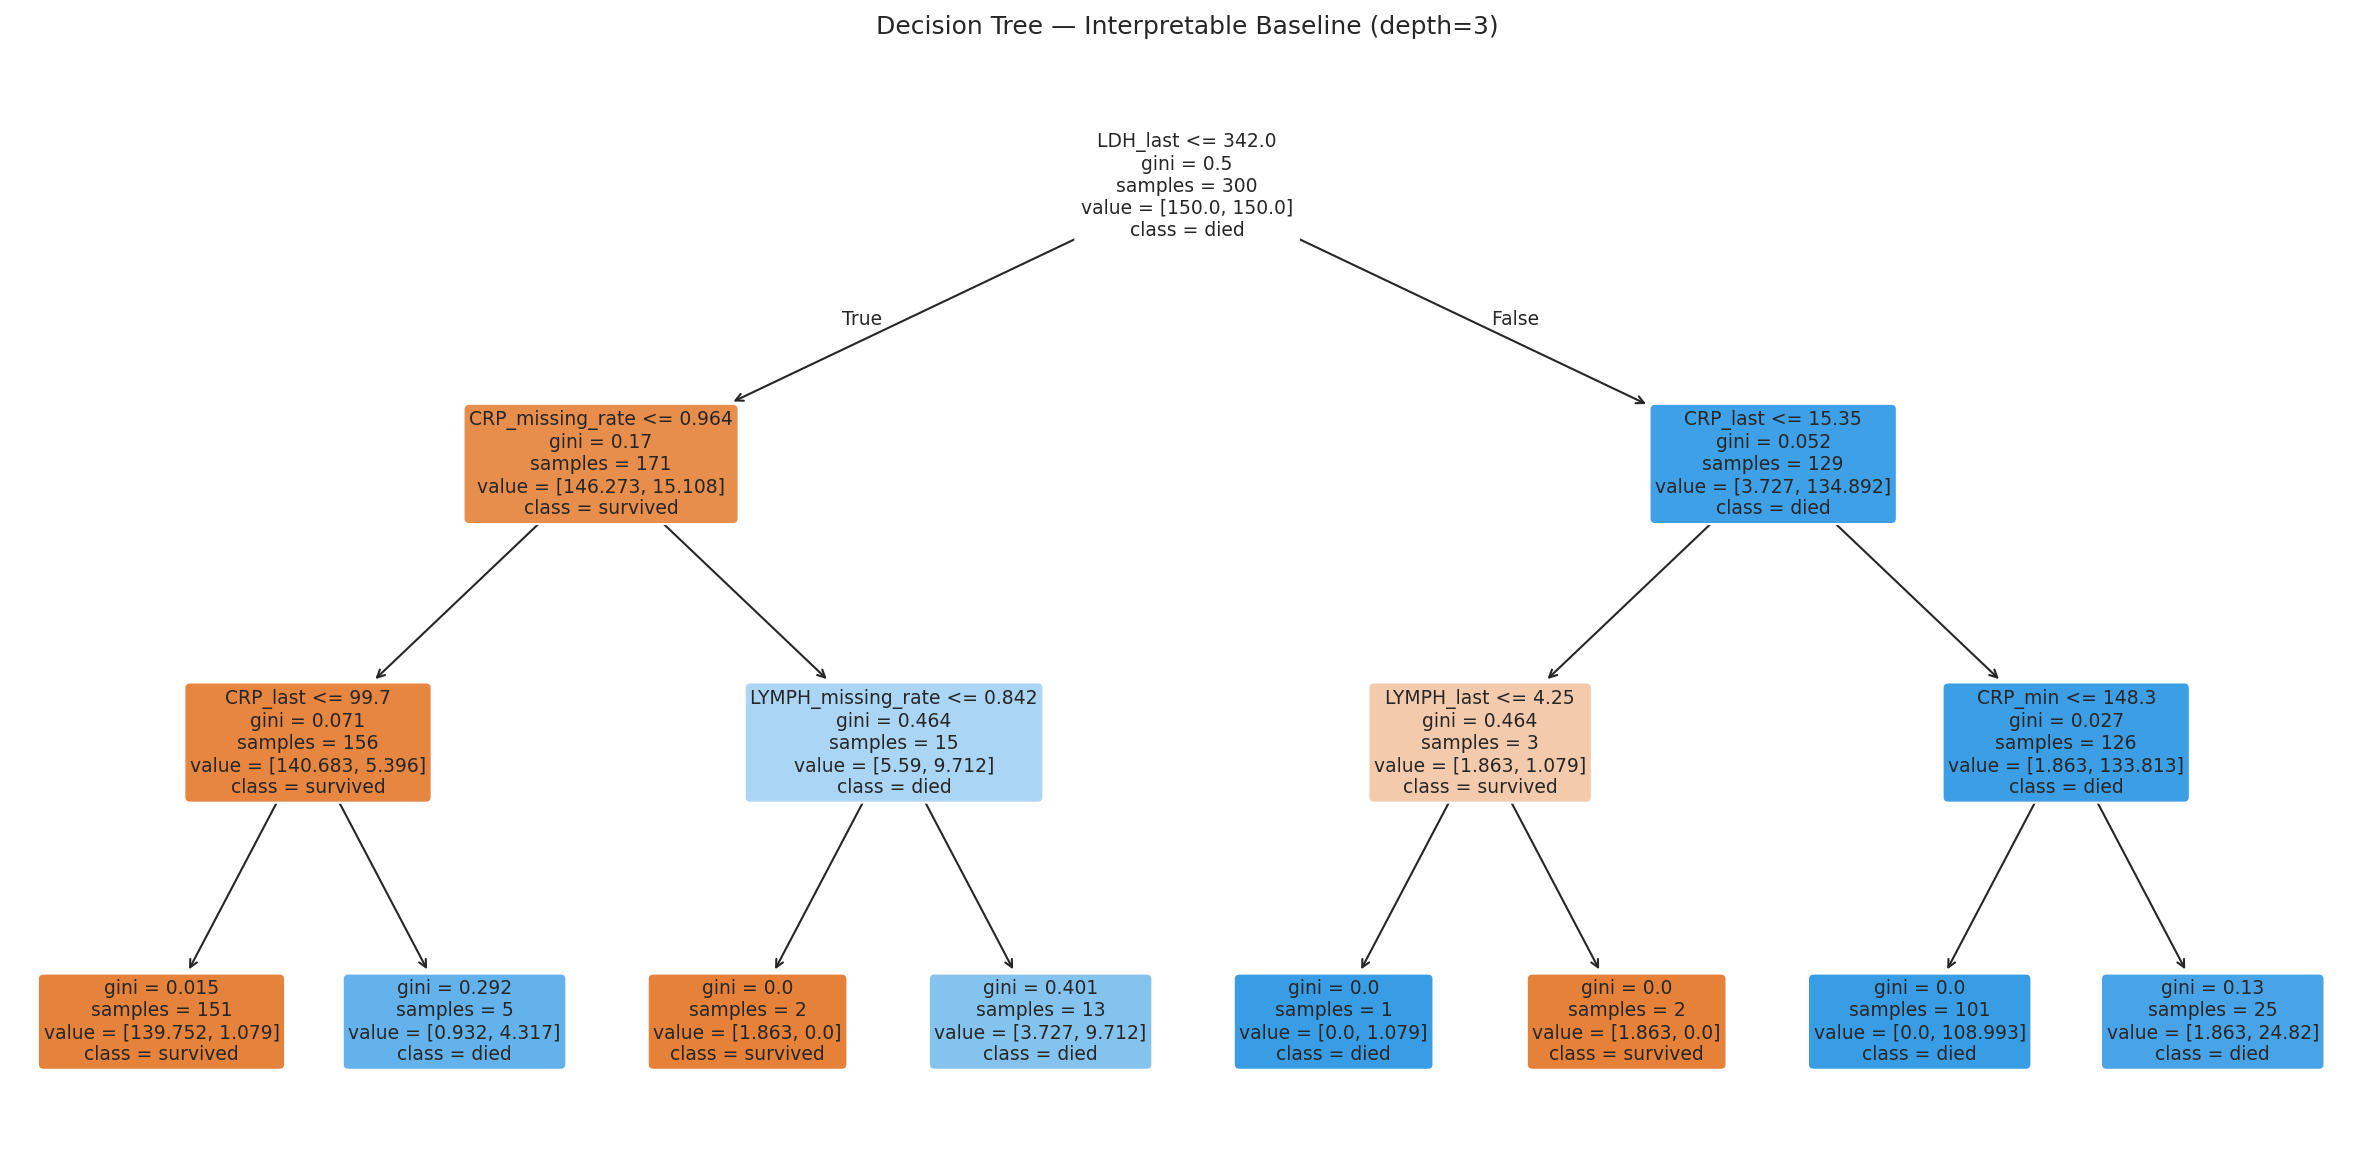

[OK] Saved: decision_tree_plot_full.png

Training XGBoost (scale_pos_weight=1.158)...
[OK] Main gradient boosting model trained.

Cell 7 complete. Trained models:
  model_logreg : Logistic Regression (uses X_*_scaled)
  model_tree   : Decision Tree depth=3 (uses X_*_imp)
  model_xgb    : XGBoost / fallback (uses X_*_imp)


In [8]:
# 1. Logistic regression (scaled)

print("Training Logistic Regression...")
model_logreg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
model_logreg.fit(X_train_scaled, y_train)
print("[OK] Logistic Regression trained.")

# 2. Decision tree, depth 3

print("\nTraining Decision Tree (max_depth=3)...")
model_tree = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
model_tree.fit(X_train_imp, y_train)
print("[OK] Decision Tree trained.")

# save the rules and a plot of the tree
tree_rules = export_text(model_tree, feature_names=feature_cols)
with open(OUTPUT_DIR / "decision_tree_rules_full.txt", "w") as f:
    f.write(tree_rules)
print("[OK] Saved: decision_tree_rules_full.txt")
print("\nDecision tree rules (preview):")
print(tree_rules[:600])

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    model_tree, feature_names=feature_cols,
    class_names=["survived", "died"],
    filled=True, rounded=True, fontsize=9, ax=ax,
)
ax.set_title("Decision Tree - Interpretable Baseline (depth=3)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decision_tree_plot_full.png", dpi=150)
plt.show()
print("[OK] Saved: decision_tree_plot_full.png")

# 3. XGBoost (main model)

print(f"\nTraining XGBoost (scale_pos_weight={scale_pos_weight:.3f})...")

if XGBOOST_AVAILABLE:
    model_xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    )
else:
    print("[WARN] XGBoost unavailable - falling back to HistGradientBoostingClassifier")
    model_xgb = HistGradientBoostingClassifier(
        max_depth=4,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    )

model_xgb.fit(X_train_imp, y_train)
print("[OK] Main gradient boosting model trained.")

print("\n" + "=" * 50)
print("Cell 7 complete. Trained models:")
print("  model_logreg : Logistic Regression (uses X_*_scaled)")
print("  model_tree   : Decision Tree depth=3 (uses X_*_imp)")
print("  model_xgb    : XGBoost / fallback (uses X_*_imp)")
print("=" * 50)

## Evaluation
ROC-AUC, PR-AUC, F1, recall and precision on the external test set (110 patients). The test set only has 13 deaths, so we bootstrap 1000 times to get confidence intervals.

MODEL EVALUATION - Full-stay window, external test set (n=110)

--- Logistic Regression ---
  ROC-AUC : 1.000  (95% CI: [1.000, 1.000])
  PR-AUC  : 1.000  (95% CI: [1.000, 1.000])
  Accuracy: 0.955   F1: 0.762   Recall: 0.615   Precision: 1.000   Specificity: 1.000
  Confusion matrix [TN=97, FP=0, FN=5, TP=8]

--- Decision Tree ---
  ROC-AUC : 0.873  (95% CI: [0.687, 0.994])
  PR-AUC  : 0.703  (95% CI: [0.431, 0.947])
  Accuracy: 0.964   F1: 0.846   Recall: 0.846   Precision: 0.846   Specificity: 0.979
  Confusion matrix [TN=95, FP=2, FN=2, TP=11]

--- XGBoost (main model) ---
  ROC-AUC : 0.994  (95% CI: [0.982, 1.000])
  PR-AUC  : 0.959  (95% CI: [0.844, 1.000])
  Accuracy: 0.973   F1: 0.889   Recall: 0.923   Precision: 0.857   Specificity: 0.979
  Confusion matrix [TN=95, FP=2, FN=1, TP=12]

[OK] Saved: model_performance_full.csv
               model  roc_auc  pr_auc  accuracy    f1  recall  precision
 Logistic Regression    1.000   1.000     0.955 0.762   0.615      1.000
       Dec

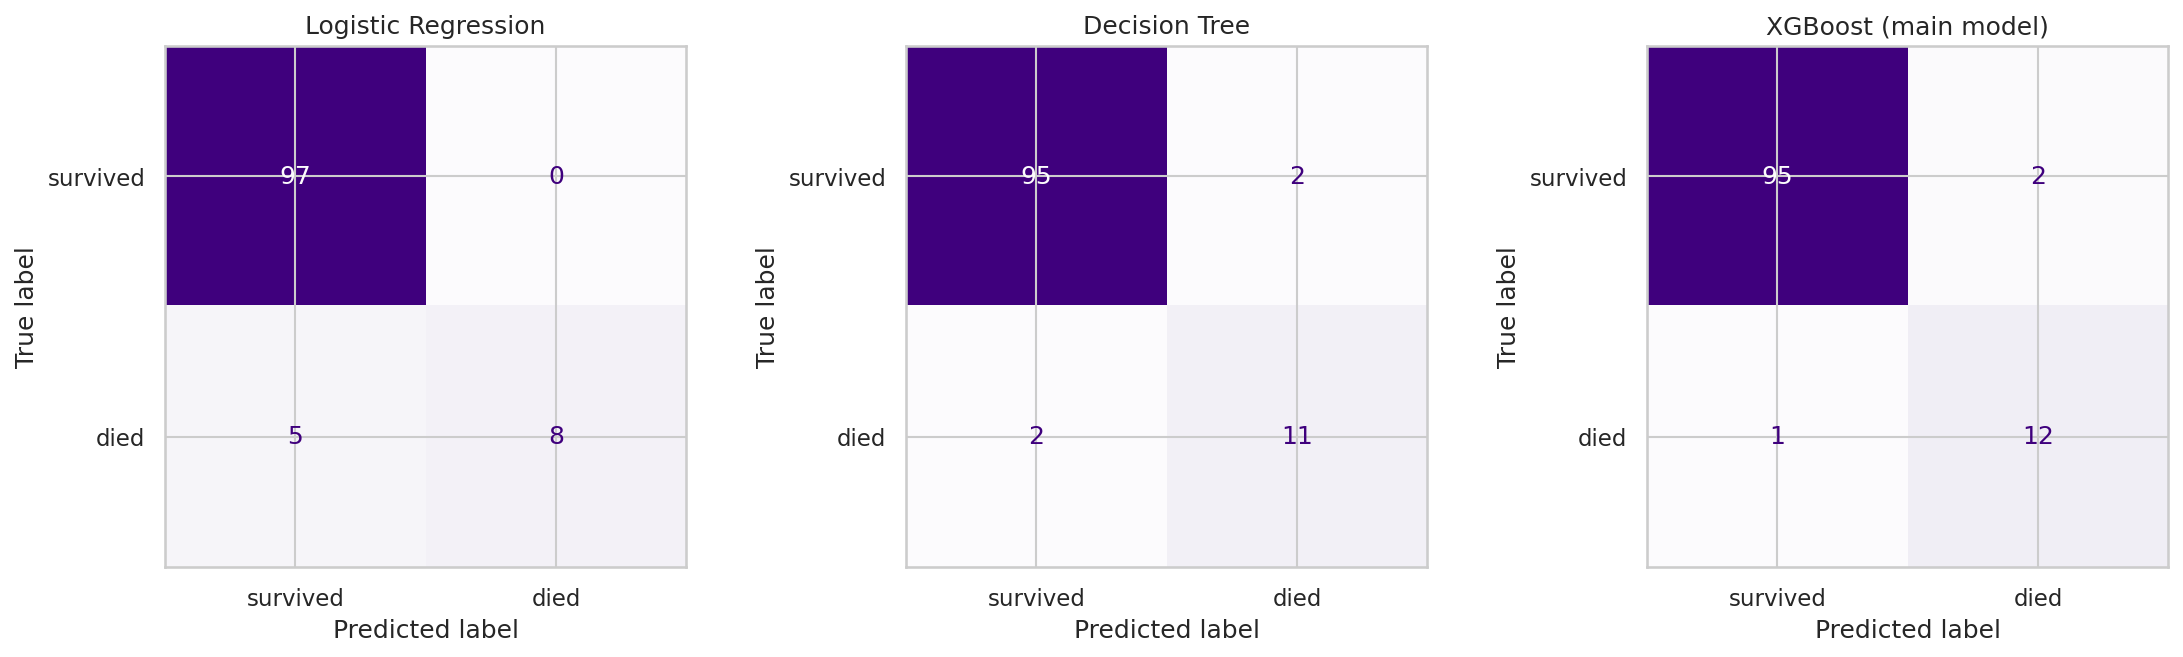

[OK] Saved: confusion_matrix_full.png


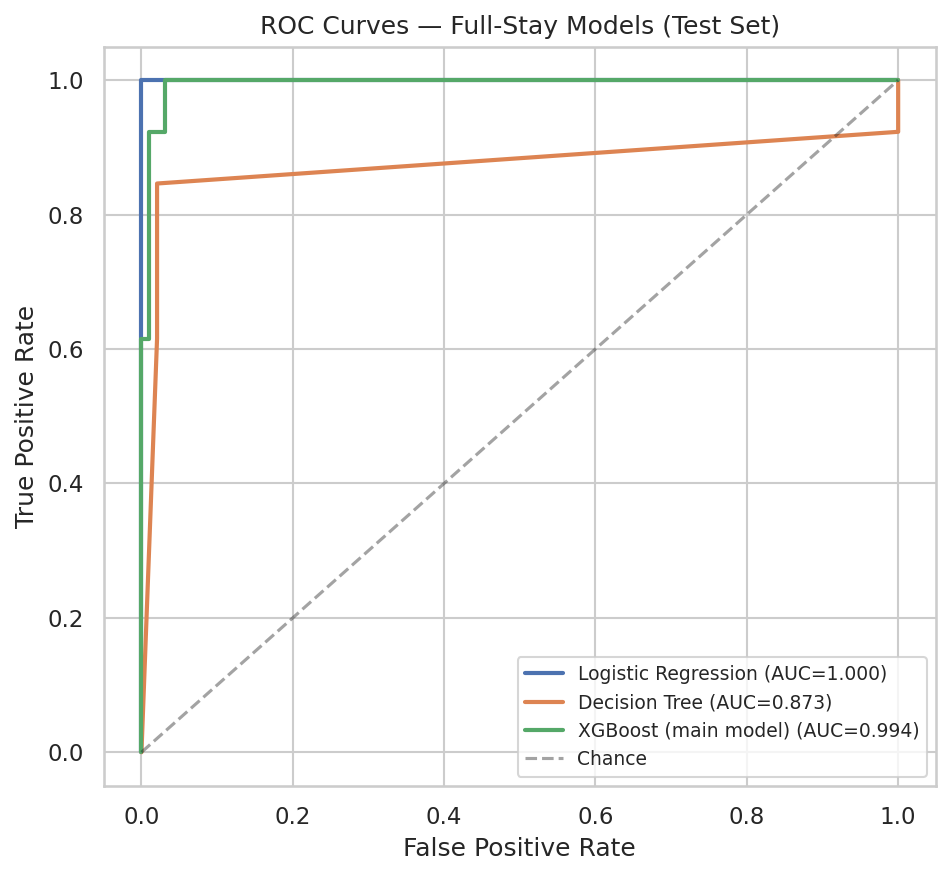

[OK] Saved: roc_curve_full.png


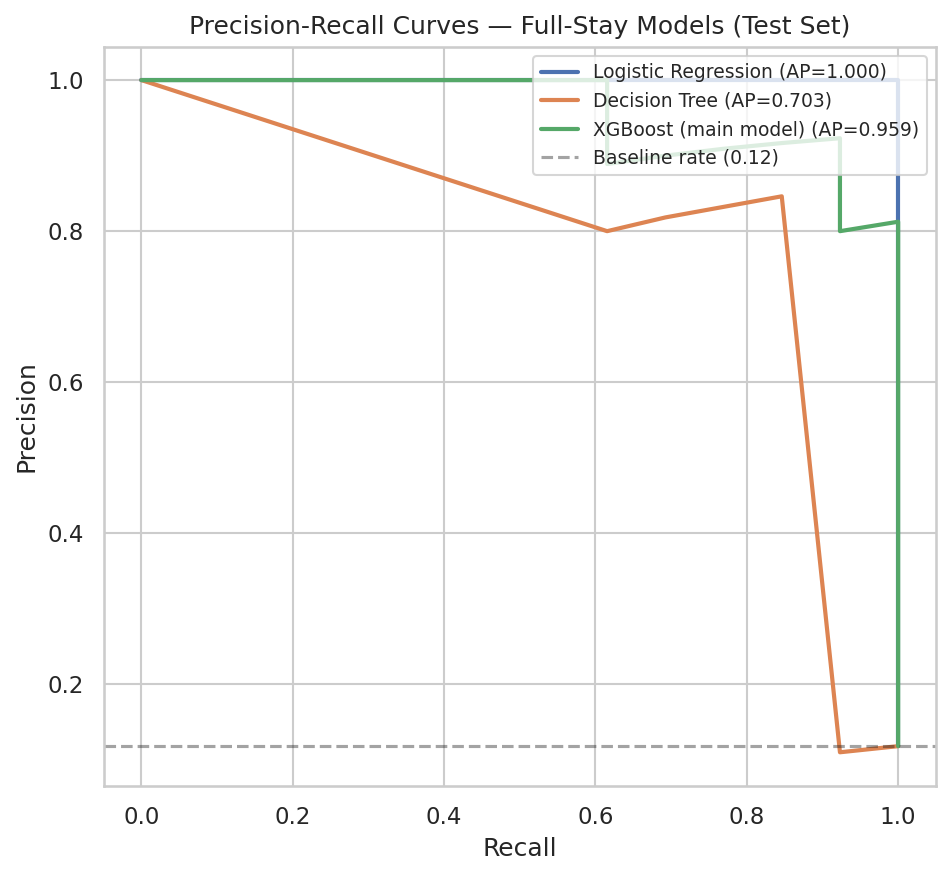

[OK] Saved: pr_curve_full.png

Cell 8 complete.
  Best ROC-AUC model: Logistic Regression
  Best PR-AUC model:  Logistic Regression

[NOTE - near-perfect separation]
Some models get ROC-AUC close to 1. This fits the dataset: Yan et al. (2020) found that
LDH, lymphocytes and hs-CRP alone predict mortality with over 90% accuracy. Our test set
only has 13 deaths though, so the confidence intervals above say more than the point
estimates.


In [9]:
def bootstrap_auc_ci(y_true, y_proba, metric_func, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_STATE):
    """95% CI with bootstrap, skips resamples with only one class."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)

    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_t, y_p = y_true[idx], y_proba[idx]
        if len(np.unique(y_t)) < 2:
            continue  # resample with only one class, skip
        scores.append(metric_func(y_t, y_p))

    if len(scores) == 0:
        return np.nan, np.nan, np.nan
    scores = np.array(scores)
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def evaluate_classifier(model, X_test_eval, y_test_eval, model_name: str,
                         threshold: float = 0.5) -> dict:
    """All metrics for one model on one test set."""
    y_proba = model.predict_proba(X_test_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_test_eval, y_proba)
    pr_auc  = average_precision_score(y_test_eval, y_proba)
    acc     = accuracy_score(y_test_eval, y_pred)
    f1      = f1_score(y_test_eval, y_pred, zero_division=0)
    recall  = recall_score(y_test_eval, y_pred, zero_division=0)
    prec    = precision_score(y_test_eval, y_pred, zero_division=0)

    cm = confusion_matrix(y_test_eval, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # 95% CIs
    roc_mean, roc_lo, roc_hi = bootstrap_auc_ci(y_test_eval, y_proba, roc_auc_score)
    pr_mean,  pr_lo,  pr_hi  = bootstrap_auc_ci(y_test_eval, y_proba, average_precision_score)

    print(f"\n--- {model_name} ---")
    print(f"  ROC-AUC : {roc_auc:.3f}  (95% CI: [{roc_lo:.3f}, {roc_hi:.3f}])")
    print(f"  PR-AUC  : {pr_auc:.3f}  (95% CI: [{pr_lo:.3f}, {pr_hi:.3f}])")
    print(f"  Accuracy: {acc:.3f}   F1: {f1:.3f}   Recall: {recall:.3f}   "
          f"Precision: {prec:.3f}   Specificity: {specificity:.3f}")
    print(f"  Confusion matrix [TN={tn}, FP={fp}, FN={fn}, TP={tp}]")

    return {
        "model": model_name,
        "roc_auc": roc_auc, "roc_auc_ci_low": roc_lo, "roc_auc_ci_high": roc_hi,
        "pr_auc": pr_auc, "pr_auc_ci_low": pr_lo, "pr_auc_ci_high": pr_hi,
        "accuracy": acc, "f1": f1, "recall": recall, "precision": prec,
        "specificity": specificity,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "y_proba": y_proba, "y_pred": y_pred,
    }


# evaluate on the test set

print("=" * 50)
print("MODEL EVALUATION - Full-stay window, external test set (n=110)")
print("=" * 50)

results_logreg = evaluate_classifier(model_logreg, X_test_scaled, y_test, "Logistic Regression")
results_tree   = evaluate_classifier(model_tree,   X_test_imp,    y_test, "Decision Tree")
results_xgb    = evaluate_classifier(model_xgb,    X_test_imp,    y_test, "XGBoost (main model)")

all_results = [results_logreg, results_tree, results_xgb]

# save table

perf_table = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_proba", "y_pred"]}
    for r in all_results
])
perf_table.to_csv(OUTPUT_DIR / "model_performance_full.csv", index=False)
print(f"\n[OK] Saved: model_performance_full.csv")
print(perf_table[["model", "roc_auc", "pr_auc", "accuracy", "f1", "recall", "precision"]]
      .round(3).to_string(index=False))

# confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, r in zip(axes, all_results):
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    disp = ConfusionMatrixDisplay(cm, display_labels=["survived", "died"])
    disp.plot(ax=ax, cmap="Purples", colorbar=False)
    ax.set_title(r["model"])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_full.png", dpi=150)
plt.show()
print("[OK] Saved: confusion_matrix_full.png")

# ROC curves

fig, ax = plt.subplots(figsize=(6.5, 6))
for r in all_results:
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{r['model']} (AUC={r['roc_auc']:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Full-Stay Models (Test Set)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_full.png", dpi=150)
plt.show()
print("[OK] Saved: roc_curve_full.png")

# PR curves

fig, ax = plt.subplots(figsize=(6.5, 6))
for r in all_results:
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, r["y_proba"])
    ax.plot(rec_curve, prec_curve, label=f"{r['model']} (AP={r['pr_auc']:.3f})", linewidth=2)
baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color="k", linestyle="--", alpha=0.4,
           label=f"Baseline rate ({baseline_rate:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves - Full-Stay Models (Test Set)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pr_curve_full.png", dpi=150)
plt.show()
print("[OK] Saved: pr_curve_full.png")

print("\n" + "=" * 50)
print("Cell 8 complete.")
print("  Best ROC-AUC model:", perf_table.loc[perf_table["roc_auc"].idxmax(), "model"])
print("  Best PR-AUC model: ", perf_table.loc[perf_table["pr_auc"].idxmax(), "model"])
print("=" * 50)

# print a warning if a model is close to perfect
near_perfect = perf_table[perf_table["roc_auc"] >= 0.995]
if len(near_perfect) > 0:
    print("\n[NOTE - near-perfect separation]")
    print(textwrap.fill(
        "Some models get ROC-AUC close to 1. This fits the dataset: Yan et al. (2020) found that "
        "LDH, lymphocytes and hs-CRP alone predict mortality with over 90% accuracy. Our test set only "
        "has 13 deaths though, so the confidence intervals above say more than the point estimates.",
        width=88
    ))

## SHAP
Global plots (beeswarm and bar) for all three models, and a local plot for one patient the model correctly predicted as high risk. The decision tree explainer returns values for both classes, so we take the death class.

Computing SHAP values...
  Logistic Regression SHAP shape: (110, 30)
  Decision Tree SHAP shape:       (110, 30)


PermutationExplainer explainer: 111it [00:10,  3.37s/it]                 


  XGBoost SHAP shape:             (110, 30)
[OK] SHAP values computed for all three models.

Generating global SHAP plots...


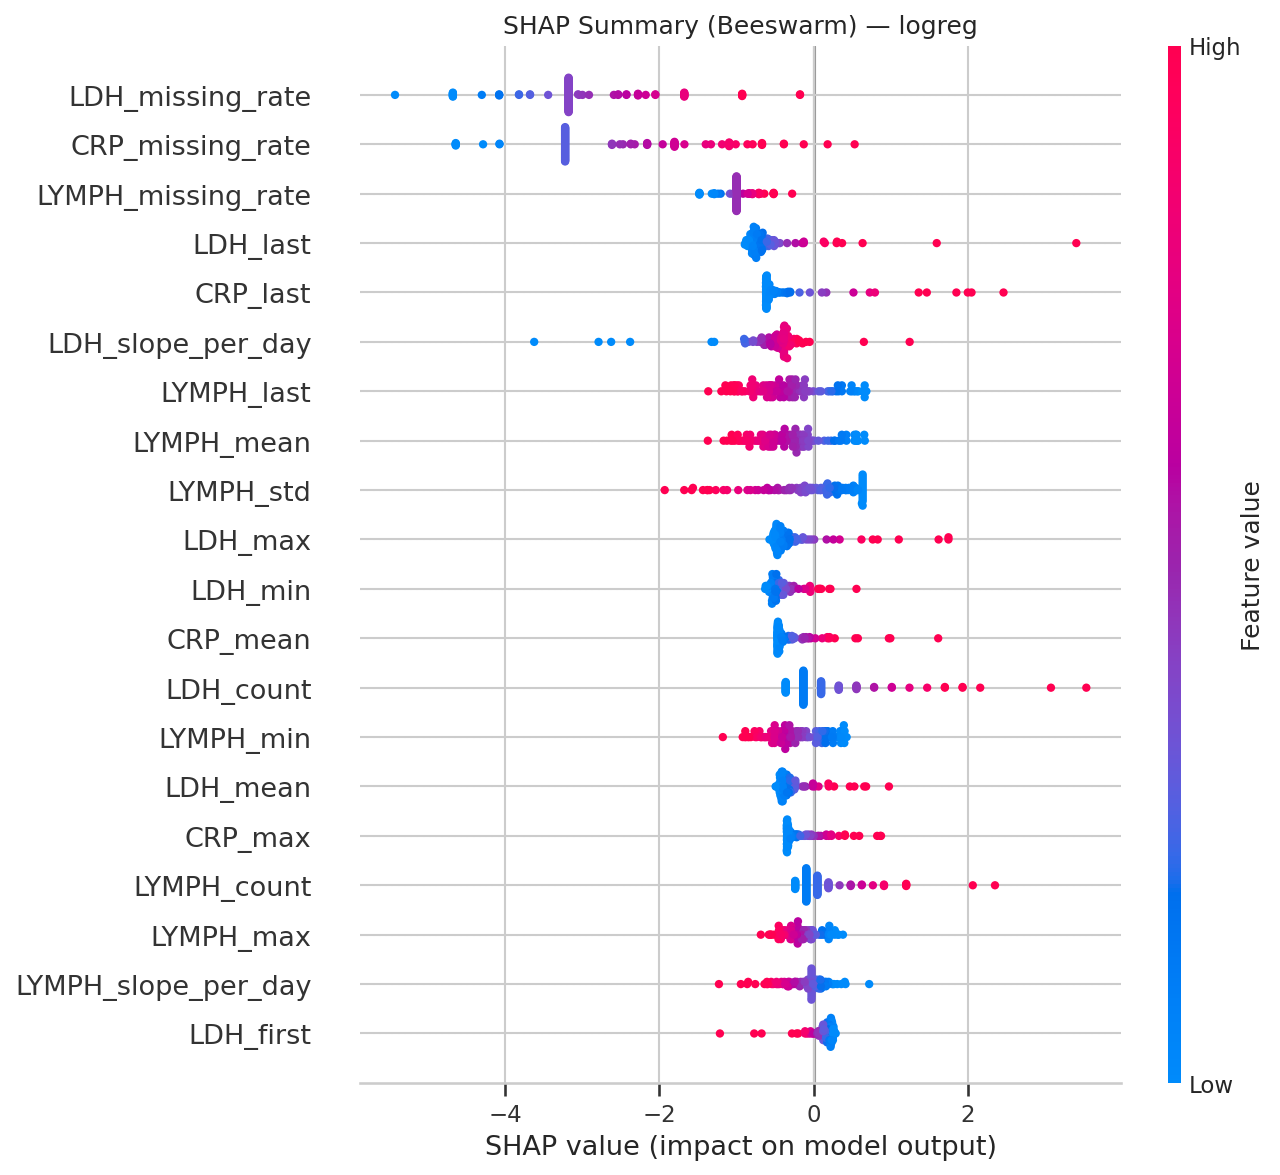

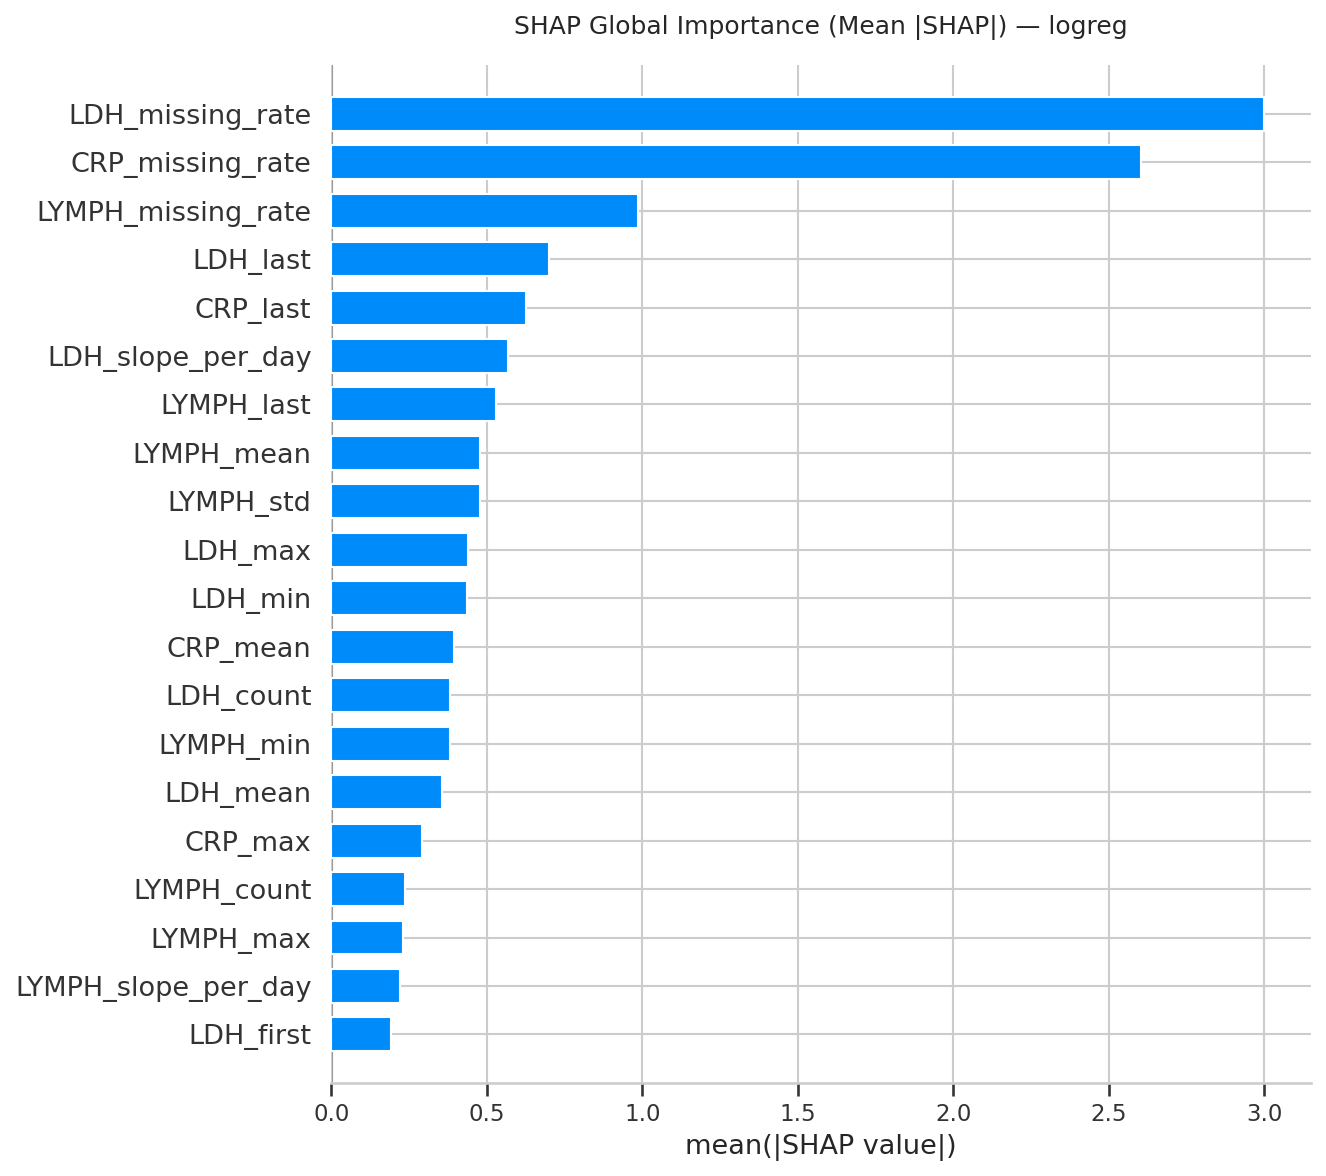

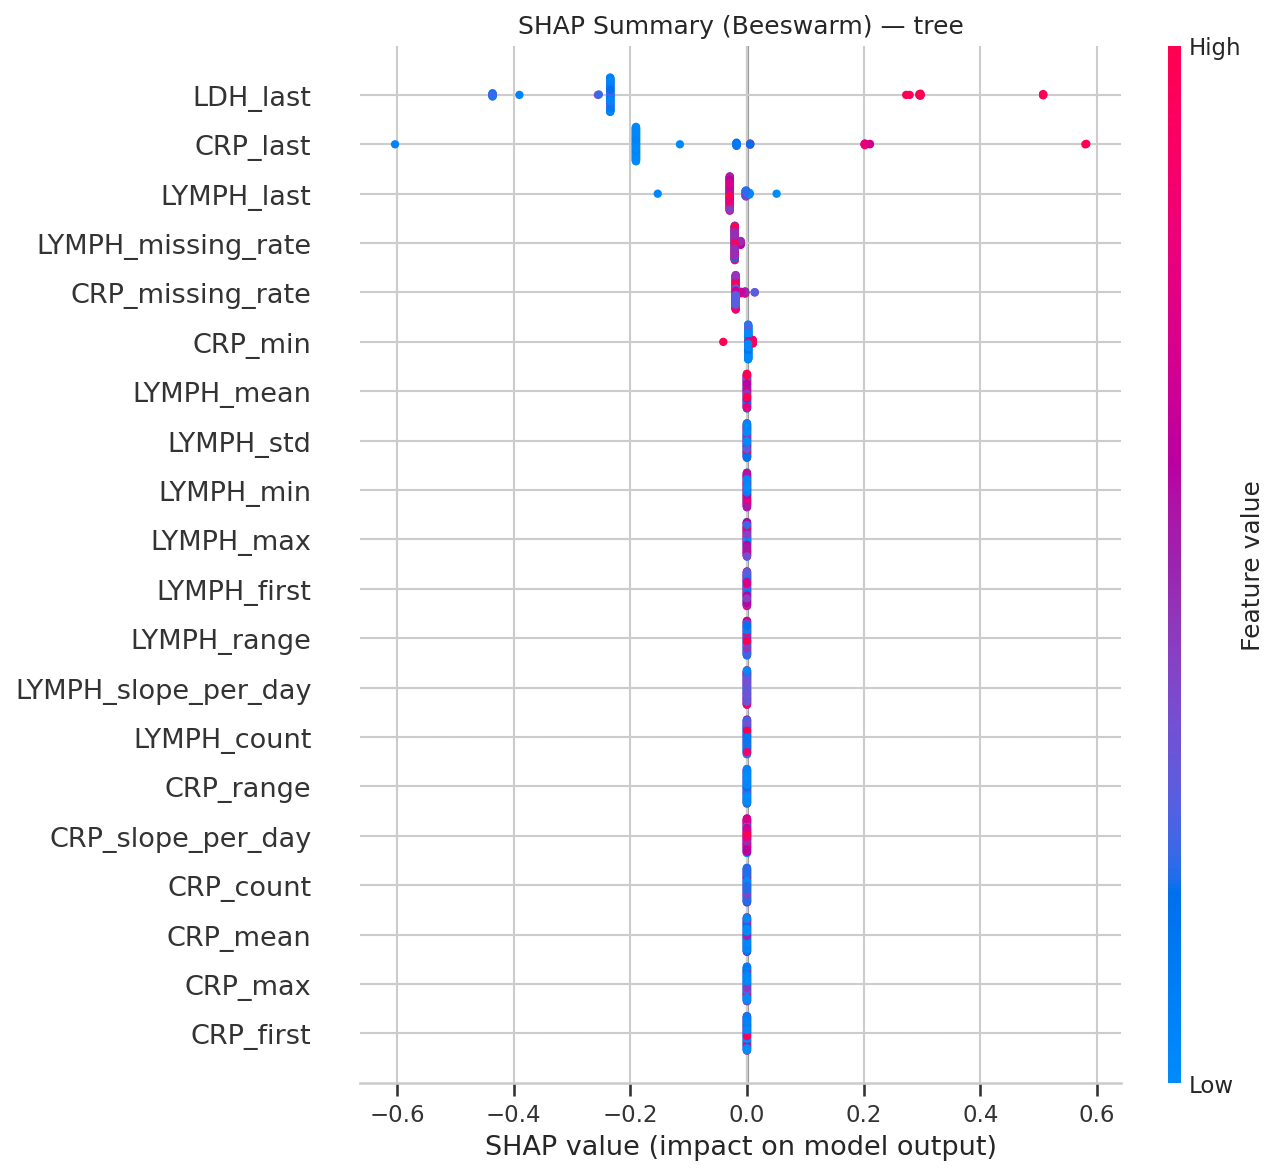

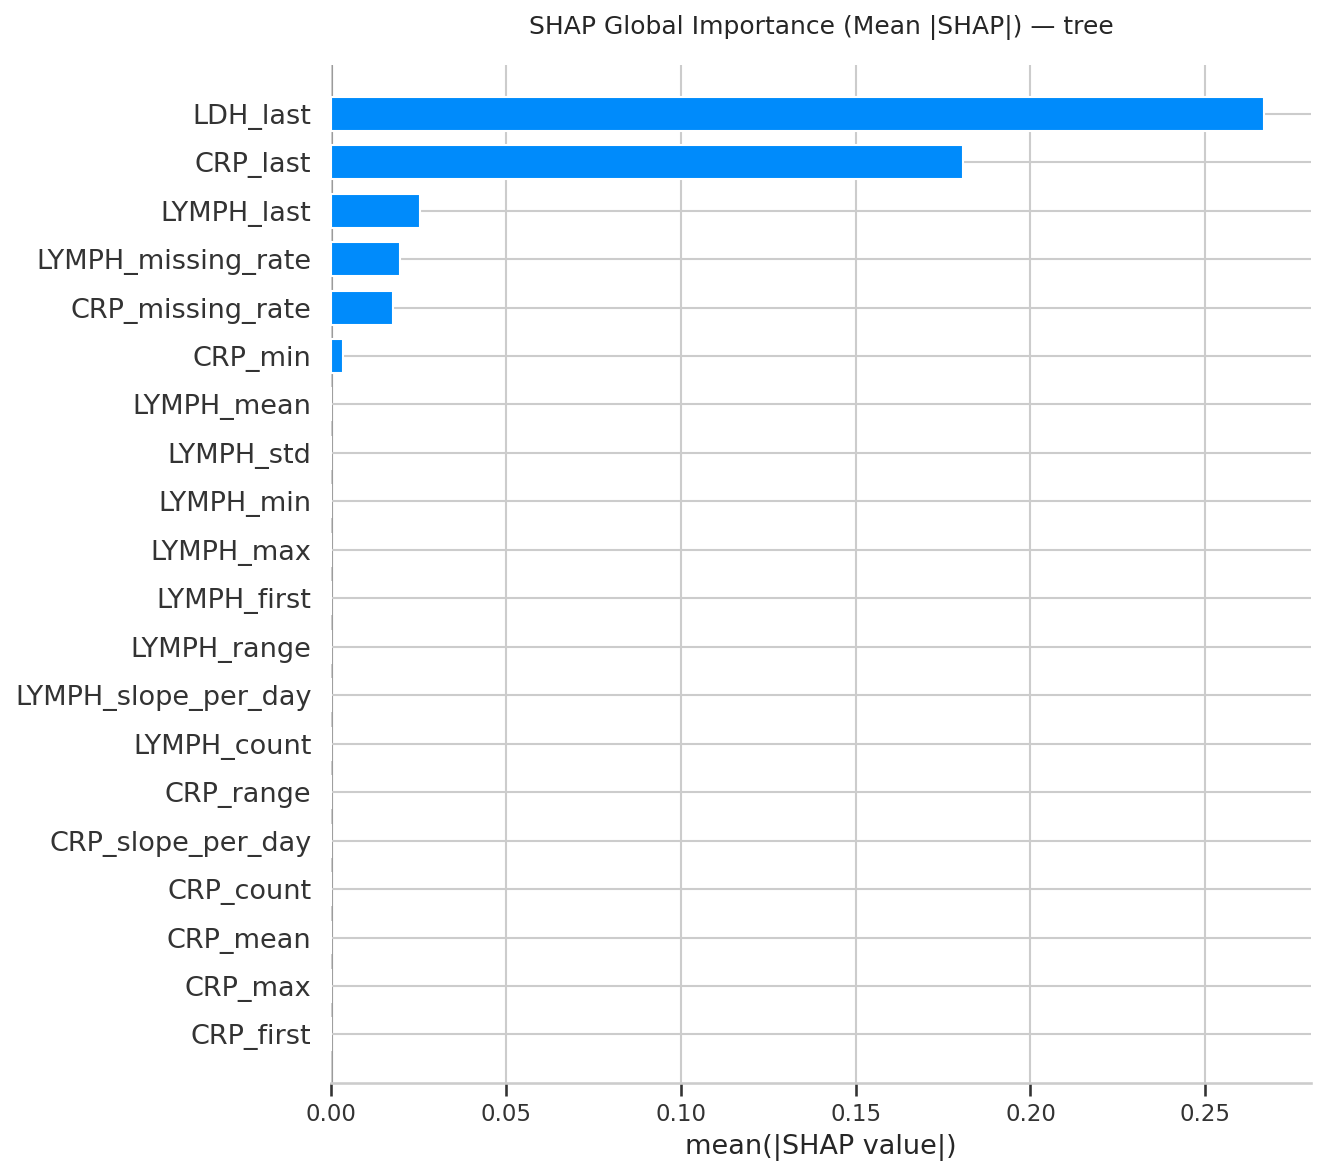

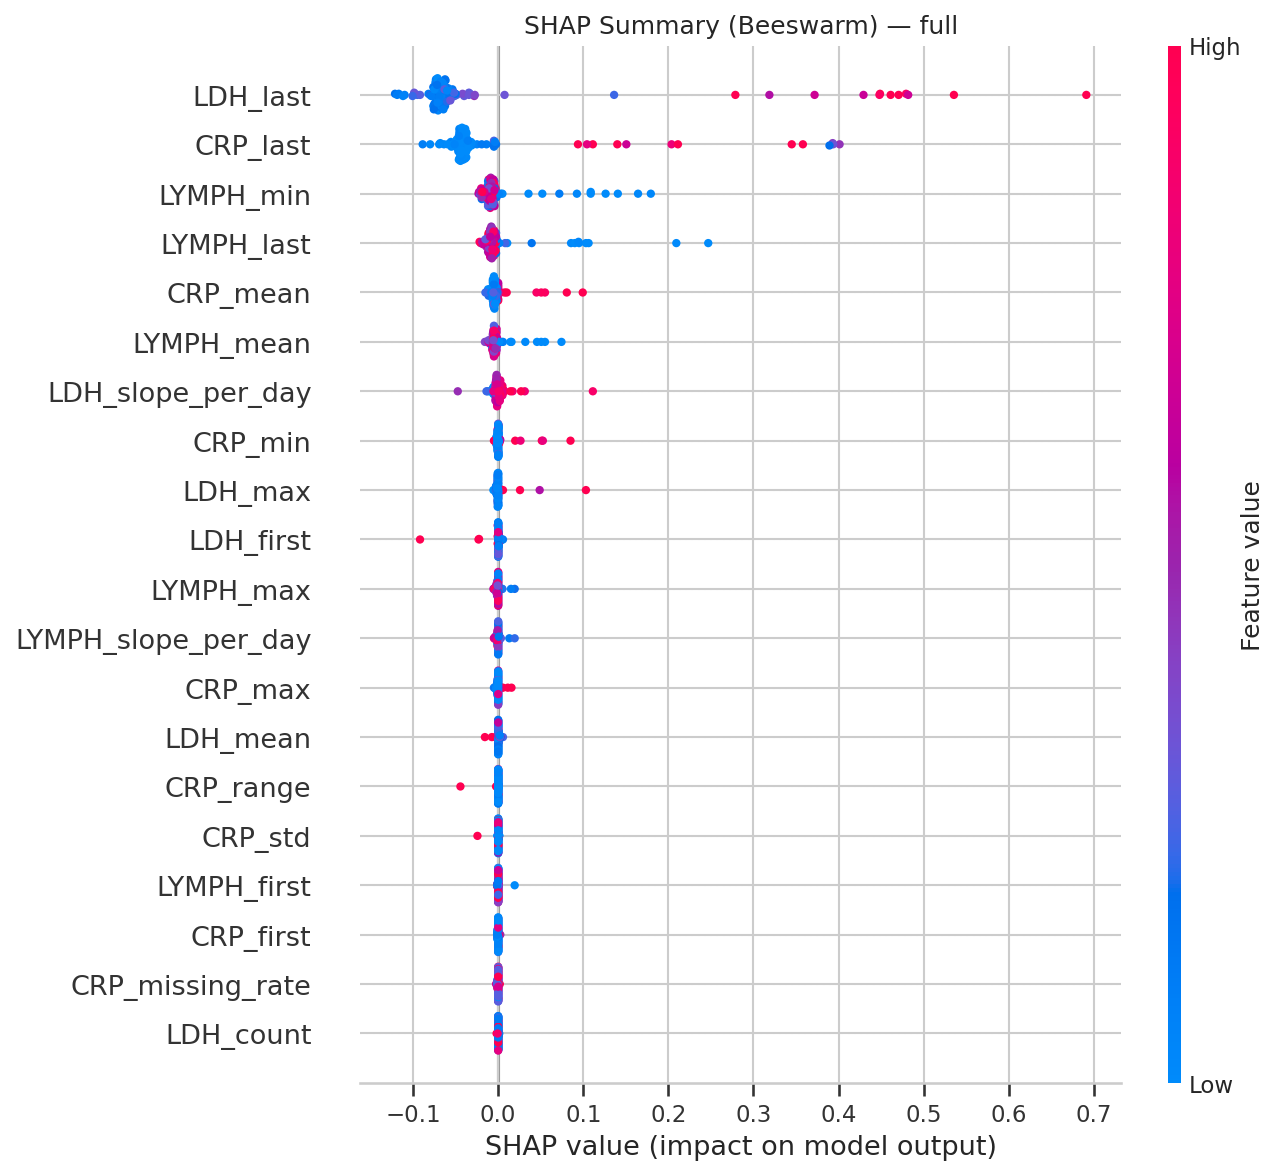

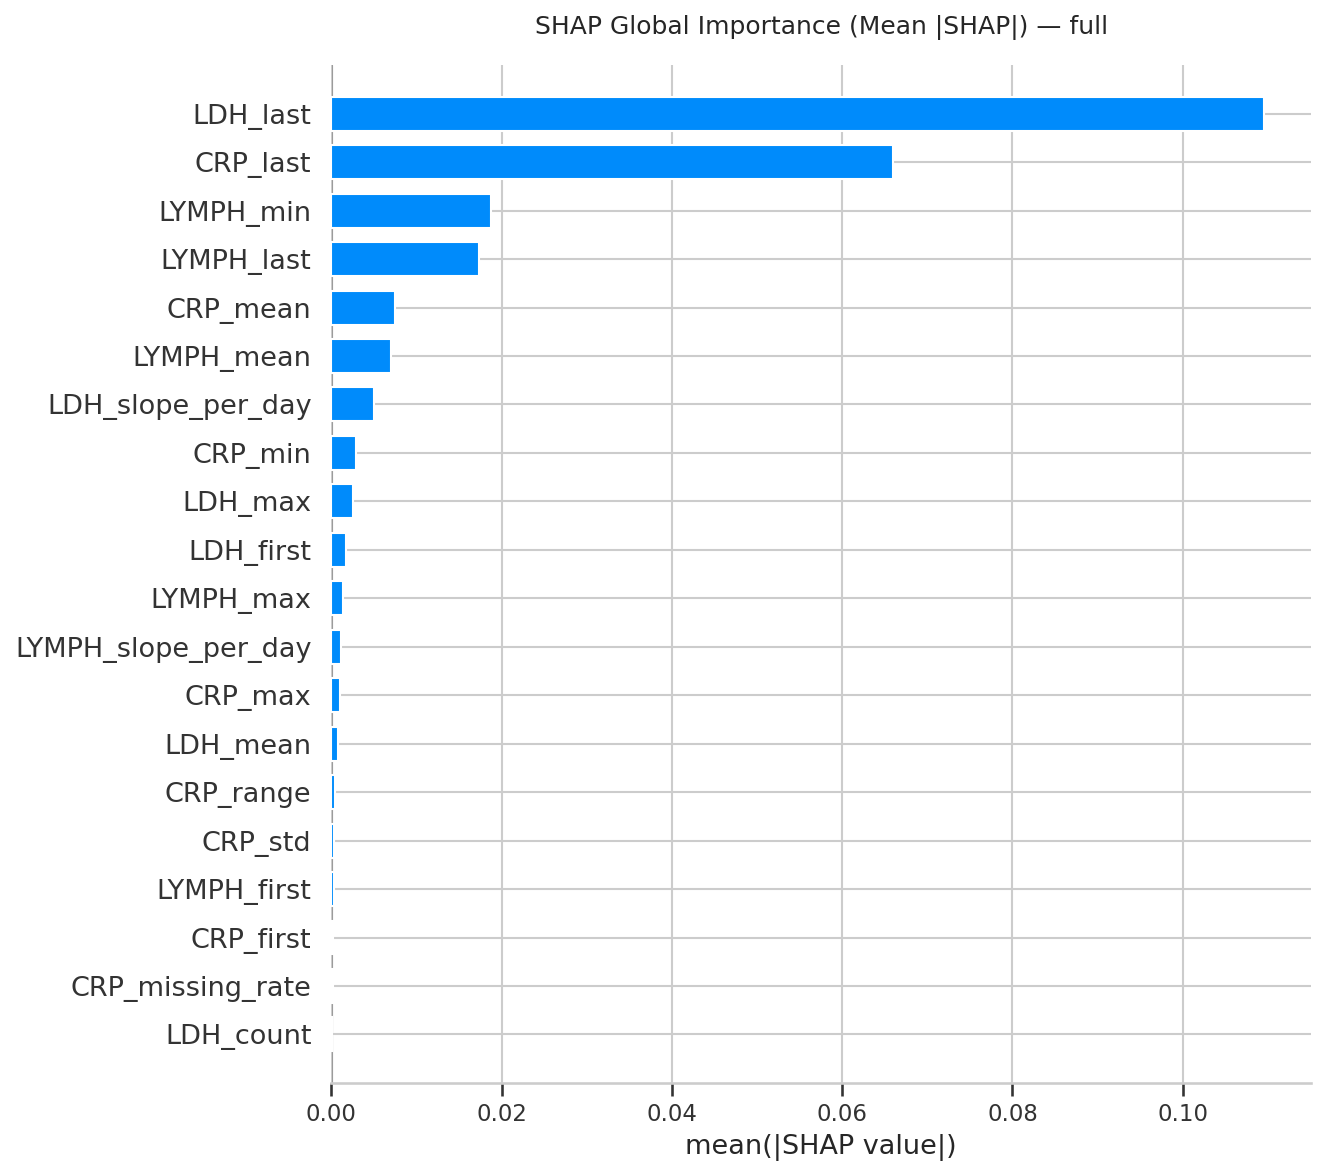

[OK] Saved beeswarm + bar plots for all 3 models.

[OK] Saved: shap_importance_full.csv

Top 10 global SHAP features (XGBoost, main model):
          feature  mean_abs_shap
         LDH_last       0.109580
         CRP_last       0.066017
        LYMPH_min       0.018761
       LYMPH_last       0.017347
         CRP_mean       0.007460
       LYMPH_mean       0.007045
LDH_slope_per_day       0.004972
          CRP_min       0.002903
          LDH_max       0.002557
        LDH_first       0.001693

High-risk true-positive example: PATIENT_ID=91.0, predicted probability=0.997


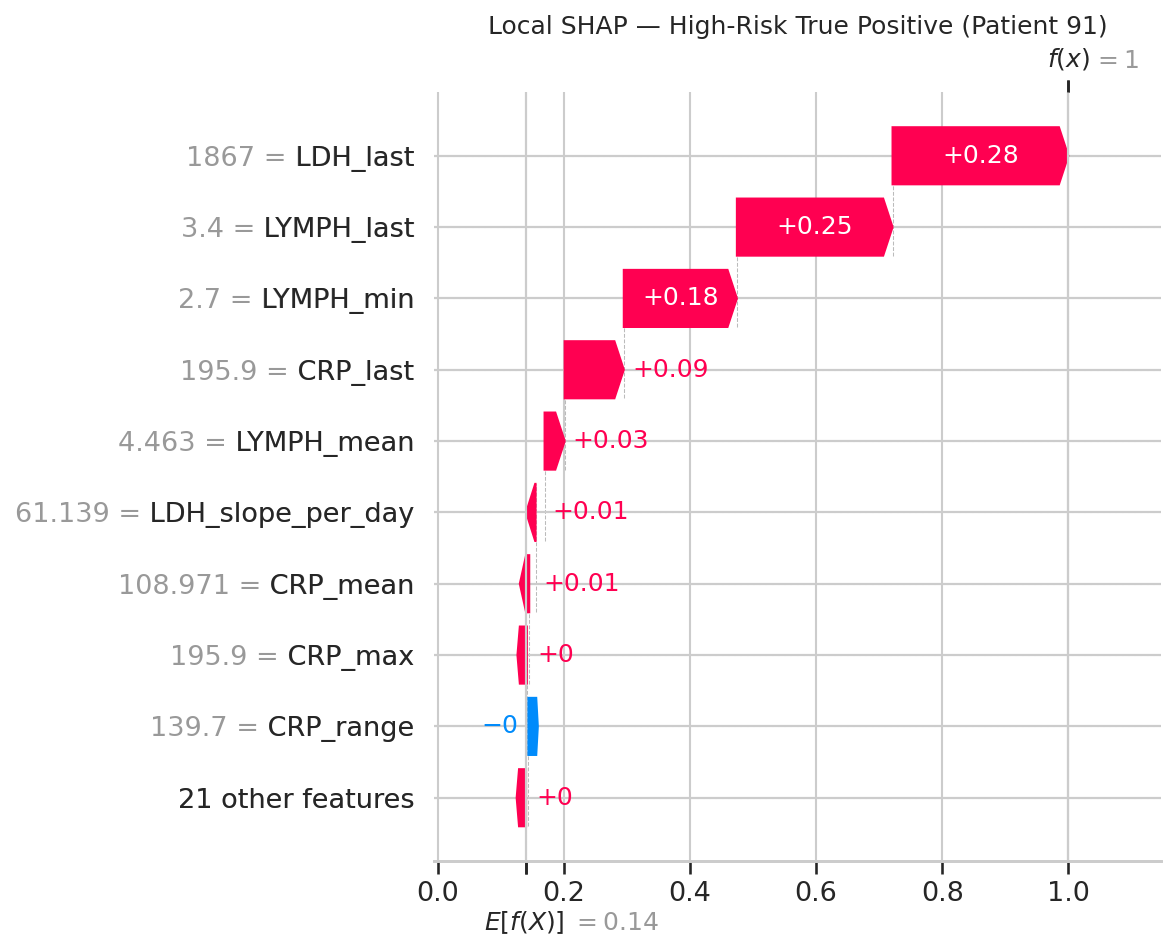

[OK] Saved: shap_local_highrisk_full.png

Cell 9 complete.
  shap_vals_logreg, shap_vals_tree, shap_vals_xgb computed.
  Use shap_vals_xgb + explainer_xgb in later cells (faithfulness, stability, etc).


In [10]:
def get_shap_values_for_positive_class(shap_explanation) -> np.ndarray:
    """Always return (n_samples, n_features) for the death class."""
    values = shap_explanation.values
    if values.ndim == 3:
        # decision tree gives (n, features, 2), take the death class
        return values[:, :, 1]
    return values


# 1. SHAP values for the three models

print("Computing SHAP values...")

# logistic regression, use the whole train set as background (default is 100)
masker_logreg = shap.maskers.Independent(X_train_scaled, max_samples=len(X_train_scaled))
explainer_logreg = shap.LinearExplainer(model_logreg, masker_logreg)
shap_exp_logreg = explainer_logreg(X_test_scaled)
shap_vals_logreg = get_shap_values_for_positive_class(shap_exp_logreg)
print(f"  Logistic Regression SHAP shape: {shap_vals_logreg.shape}")

# decision tree
explainer_tree = shap.TreeExplainer(model_tree)
shap_exp_tree = explainer_tree(X_test_imp)
shap_vals_tree = get_shap_values_for_positive_class(shap_exp_tree)
print(f"  Decision Tree SHAP shape:       {shap_vals_tree.shape}")

# xgboost 3 saves base_score as '[5E-1]' which shap can't read, so set it to a float
booster = model_xgb.get_booster()
booster.set_param({"base_score": 0.5})
model_xgb._Booster = booster

# model-agnostic (permutation) explainer on predict
explainer_xgb = shap.Explainer(model_xgb.predict, X_test_imp)
shap_exp_xgb = explainer_xgb(X_test_imp)
shap_vals_xgb = get_shap_values_for_positive_class(shap_exp_xgb)
print(f"  XGBoost SHAP shape:             {shap_vals_xgb.shape}")

print("[OK] SHAP values computed for all three models.")

# 2. Beeswarm and bar plots

def save_global_shap_plots(shap_values: np.ndarray, X_data: pd.DataFrame,
                            model_tag: str, feature_names: list):
    """Saves a beeswarm and a bar plot of global SHAP importance."""
    plt.figure(figsize=(9, 8))
    shap.summary_plot(shap_values, X_data, feature_names=feature_names,
                       show=False, plot_size=None)
    plt.title(f"SHAP Summary (Beeswarm) - {model_tag}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_summary_beeswarm_{model_tag}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(9, 8))
    shap.summary_plot(shap_values, X_data, feature_names=feature_names,
                       plot_type="bar", show=False, plot_size=None)
    plt.title(f"SHAP Global Importance (Mean |SHAP|) - {model_tag}", pad=15)
    plt.xlabel("mean(|SHAP value|)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_global_bar_{model_tag}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


print("\nGenerating global SHAP plots...")
save_global_shap_plots(shap_vals_logreg, X_test_scaled, "logreg", feature_cols)
save_global_shap_plots(shap_vals_tree,   X_test_imp,    "tree",   feature_cols)
save_global_shap_plots(shap_vals_xgb,    X_test_imp,    "full",   feature_cols)
print("[OK] Saved beeswarm + bar plots for all 3 models.")

# 3. Mean |SHAP| table for xgboost

mean_abs_shap_xgb = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_vals_xgb).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

mean_abs_shap_xgb.to_csv(OUTPUT_DIR / "shap_importance_full.csv", index=False)
print(f"\n[OK] Saved: shap_importance_full.csv")
print("\nTop 10 global SHAP features (XGBoost, main model):")
print(mean_abs_shap_xgb.head(10).to_string(index=False))

# 4. One high risk patient that the model got right

y_proba_xgb = results_xgb["y_proba"]
tp_mask = (y_test.values == 1) & (results_xgb["y_pred"] == 1)
tp_indices = np.where(tp_mask)[0]

if len(tp_indices) > 0:
    # take the most confident one
    best_tp_idx = tp_indices[np.argmax(y_proba_xgb[tp_indices])]
    patient_id_tp = ids_test.iloc[best_tp_idx]

    print(f"\nHigh-risk true-positive example: PATIENT_ID={patient_id_tp}, "
          f"predicted probability={y_proba_xgb[best_tp_idx]:.3f}")

    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_vals_xgb[best_tp_idx],
            base_values=float(shap_exp_xgb.base_values[best_tp_idx]),
            data=X_test_imp.iloc[best_tp_idx].values,
            feature_names=feature_cols,
        ),
        show=False,
    )
    plt.title(f"Local SHAP - High-Risk True Positive (Patient {int(patient_id_tp)})")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "shap_local_highrisk_full.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("[OK] Saved: shap_local_highrisk_full.png")
else:
    print("[WARN] No true positives found for XGBoost - skipping local high-risk plot.")

print("\n" + "=" * 50)
print("Cell 9 complete.")
print("  shap_vals_logreg, shap_vals_tree, shap_vals_xgb computed.")
print("  Use shap_vals_xgb + explainer_xgb in later cells (faithfulness, stability, etc).")
print("=" * 50)

## LIME
LIME on XGBoost for the same patient as the SHAP local plot, plus a low risk patient and the errors. We also run it on 25 test patients for the comparisons below. LIME is slow (5000 samples per patient), which is why it's a subset.

[OK] LIME explainer built using training split as background.

Selected patients for local LIME explanations:
  True positive (high-risk) index: 90 (patient 91)
  True negative (low-risk) index:  1 (patient 2)
  False positive index: 39
  False negative index: 60

Generating local LIME explanations...


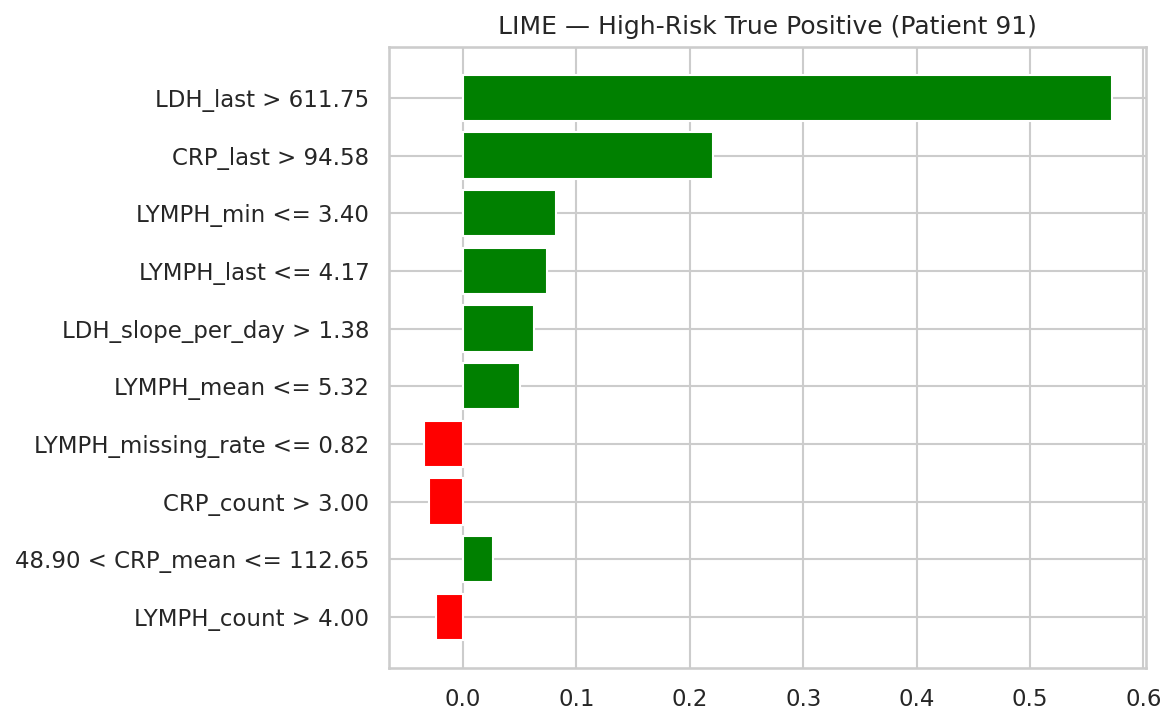

  [OK] High-Risk True Positive: saved lime_local_highrisk_full.html + .png


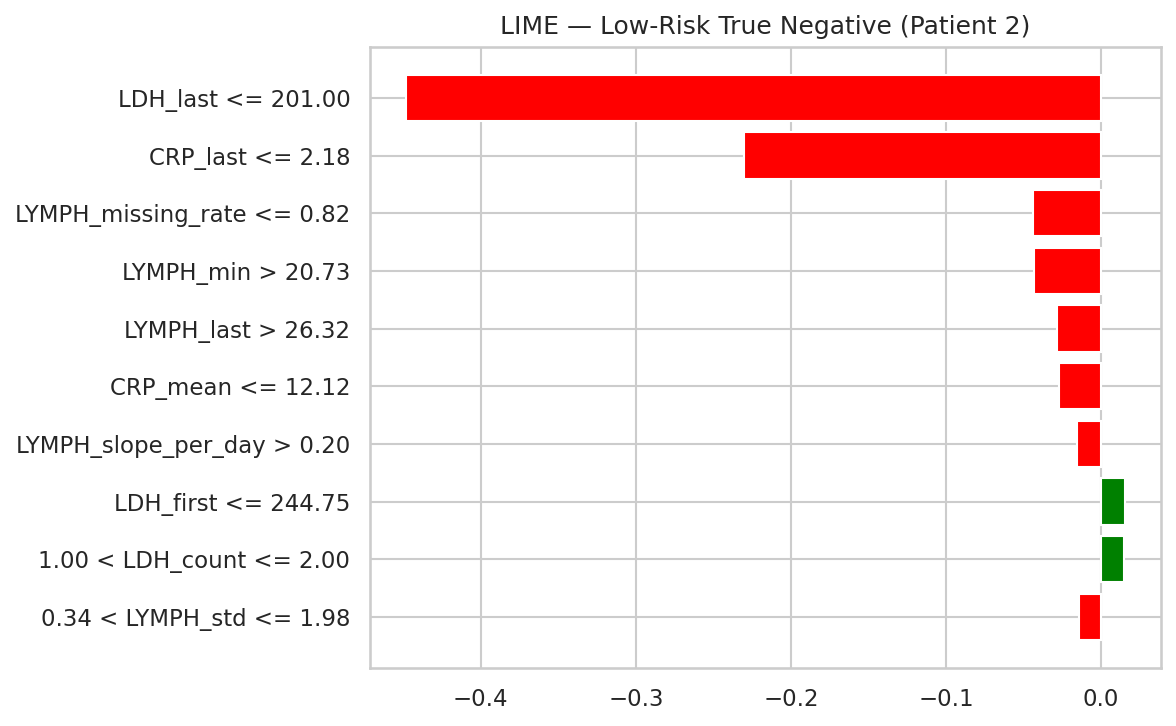

  [OK] Low-Risk True Negative: saved lime_local_lowsurvival_full.html + .png


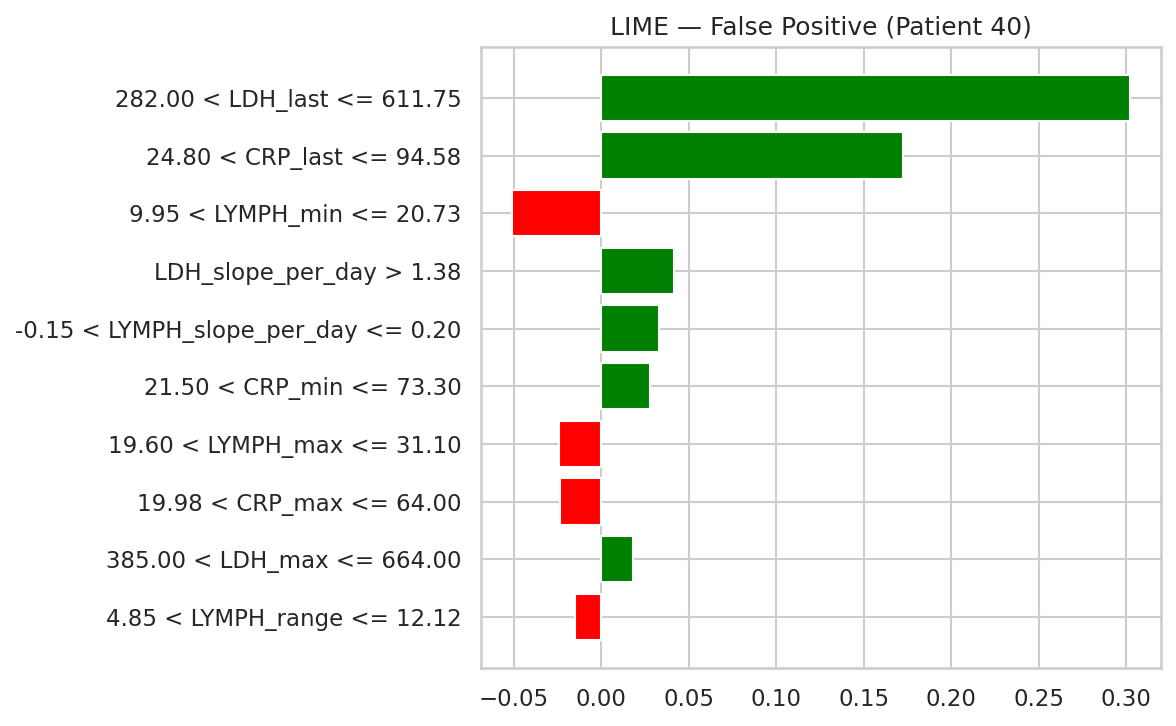

  [OK] False Positive: saved lime_local_falsepositive_full.html + .png


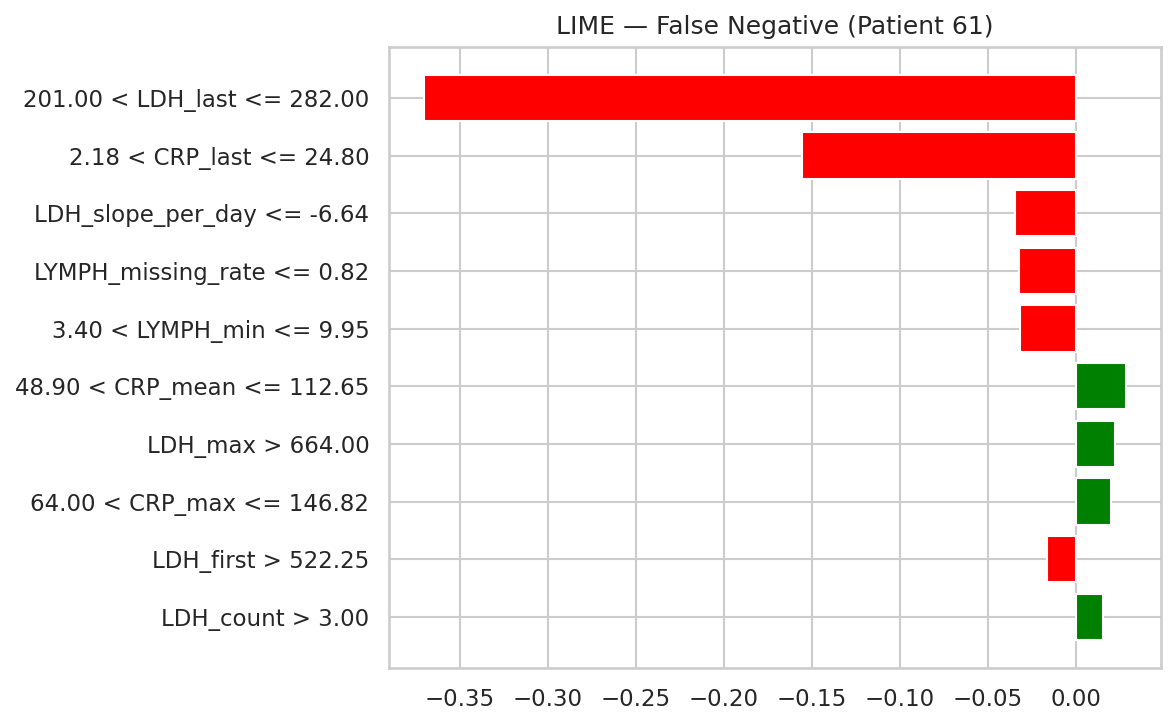

  [OK] False Negative: saved lime_local_falsenegative_full.html + .png

Running LIME on a 25-patient subset for quantitative comparison...
[OK] Saved: lime_importance_selected_patients_full.csv (25 patients, avg runtime 0.05s/patient)

Cell 10 complete.
  lime_explainer, lime_subset_indices, lime_importance_df available.
  lime_runtimes saved for Cell 14 (runtime comparison).


In [11]:
if not LIME_AVAILABLE:
    print("[WARN] LIME not available - skipping this cell. "
          "SHAP-only comparison will be used in later cells.")
else:
    # 1. LIME explainer, sampling from the (unscaled) train data

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_imp.values,
        feature_names=feature_cols,
        class_names=["survived", "died"],
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )
    print("[OK] LIME explainer built using training split as background.")

    predict_fn_xgb = lambda x: model_xgb.predict_proba(
        pd.DataFrame(x, columns=feature_cols)
    )

    # 2. Pick the same kinds of patients as for SHAP

    y_pred_xgb = results_xgb["y_pred"]
    y_test_arr = y_test.values

    tp_mask = (y_test_arr == 1) & (y_pred_xgb == 1)
    tn_mask = (y_test_arr == 0) & (y_pred_xgb == 0)
    fp_mask = (y_test_arr == 0) & (y_pred_xgb == 1)
    fn_mask = (y_test_arr == 1) & (y_pred_xgb == 0)

    # same patient as in the SHAP local plot
    tp_indices = np.where(tp_mask)[0]
    idx_tp = tp_indices[np.argmax(results_xgb["y_proba"][tp_indices])] if len(tp_indices) > 0 else None

    # lowest predicted risk
    tn_indices = np.where(tn_mask)[0]
    idx_tn = tn_indices[np.argmin(results_xgb["y_proba"][tn_indices])] if len(tn_indices) > 0 else None

    fp_indices = np.where(fp_mask)[0]
    idx_fp = fp_indices[0] if len(fp_indices) > 0 else None

    fn_indices = np.where(fn_mask)[0]
    idx_fn = fn_indices[0] if len(fn_indices) > 0 else None

    print(f"\nSelected patients for local LIME explanations:")
    print(f"  True positive (high-risk) index: {idx_tp}"
          f"{' (patient ' + str(int(ids_test.iloc[idx_tp])) + ')' if idx_tp is not None else ''}")
    print(f"  True negative (low-risk) index:  {idx_tn}"
          f"{' (patient ' + str(int(ids_test.iloc[idx_tn])) + ')' if idx_tn is not None else ''}")
    print(f"  False positive index: {idx_fp if idx_fp is not None else 'none available'}")
    print(f"  False negative index: {idx_fn if idx_fn is not None else 'none available'}")

    # 3. Local LIME plots

    def explain_and_save(idx: int, tag: str, label: str):
        """LIME for one patient, saves html and png."""
        if idx is None:
            print(f"  [SKIP] {label} - no such patient in this test set.")
            return None

        exp = lime_explainer.explain_instance(
            X_test_imp.iloc[idx].values,
            predict_fn_xgb,
            num_features=10,
            num_samples=LIME_N_SAMPLES,
        )

        exp.save_to_file(str(OUTPUT_DIR / f"lime_local_{tag}_full.html"))

        fig = exp.as_pyplot_figure()
        fig.set_size_inches(8, 5)
        plt.title(f"LIME - {label} (Patient {int(ids_test.iloc[idx])})")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"lime_local_{tag}_full.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

        print(f"  [OK] {label}: saved lime_local_{tag}_full.html + .png")
        return exp

    print("\nGenerating local LIME explanations...")
    lime_exp_tp = explain_and_save(idx_tp, "highrisk", "High-Risk True Positive")
    lime_exp_tn = explain_and_save(idx_tn, "lowsurvival", "Low-Risk True Negative")
    lime_exp_fp = explain_and_save(idx_fp, "falsepositive", "False Positive")
    lime_exp_fn = explain_and_save(idx_fn, "falsenegative", "False Negative")

    # 4. Run LIME on a subset of patients for the comparisons later

    N_LIME_SUBSET = min(25, len(X_test_imp))
    rng = np.random.default_rng(RANDOM_STATE)
    lime_subset_indices = rng.choice(len(X_test_imp), size=N_LIME_SUBSET, replace=False)

    print(f"\nRunning LIME on a {N_LIME_SUBSET}-patient subset for quantitative comparison...")
    lime_importance_rows = []
    lime_runtimes = []

    for i in lime_subset_indices:
        t0 = time.time()
        exp = lime_explainer.explain_instance(
            X_test_imp.iloc[i].values,
            predict_fn_xgb,
            num_features=len(feature_cols),
            num_samples=LIME_N_SAMPLES,
        )
        elapsed = time.time() - t0
        lime_runtimes.append(elapsed)

        # LIME gives conditions like 'LDH_last > 400', map them back to feature names
        for condition, weight in exp.as_list():
            # longest match, so LDH_max doesn't match LDH_max_x
            matched_feature = max(
                (f for f in feature_cols if f in condition),
                key=len, default=None
            )
            if matched_feature:
                lime_importance_rows.append({
                    "patient_index": i,
                    "patient_id": ids_test.iloc[i],
                    "feature": matched_feature,
                    "lime_weight": weight,
                })

    lime_importance_df = pd.DataFrame(lime_importance_rows)
    lime_importance_df.to_csv(OUTPUT_DIR / "lime_importance_selected_patients_full.csv", index=False)

    print(f"[OK] Saved: lime_importance_selected_patients_full.csv "
          f"({N_LIME_SUBSET} patients, avg runtime {np.mean(lime_runtimes):.2f}s/patient)")

print("\n" + "=" * 50)
print("Cell 10 complete.")
if LIME_AVAILABLE:
    print(f"  lime_explainer, lime_subset_indices, lime_importance_df available.")
    print(f"  lime_runtimes saved for Cell 14 (runtime comparison).")
print("=" * 50)

## Faithfulness
Do the features SHAP and LIME rank highest actually matter to the model? We replace the top-k features with the training median and see how much the predicted death probability drops, compared with removing k random features. The median is used instead of 0 so the patient stays realistic.

Baseline (training median) values for occlusion:
LDH_first              338.00
LDH_last               282.00
LDH_min                266.00
LDH_max                385.00
LDH_mean               314.00
LDH_std                 31.50
LDH_range               70.00
LDH_slope_per_day       -3.34
LDH_count                2.00
LDH_missing_rate         0.86
CRP_first               52.50
CRP_last                24.80
CRP_min                 21.50
CRP_max                 64.00
CRP_mean                48.90
CRP_std                  4.10
CRP_range                8.20
CRP_slope_per_day       -2.56
CRP_count                2.00
CRP_missing_rate         0.88
LYMPH_first             14.40
LYMPH_last              13.85
LYMPH_min                9.95
LYMPH_max               19.60
LYMPH_mean              14.70
LYMPH_std                1.98
LYMPH_range              4.85
LYMPH_slope_per_day     -0.15
LYMPH_count              2.00
LYMPH_missing_rate       0.85

Running faithfulness evaluation on 28 test patient

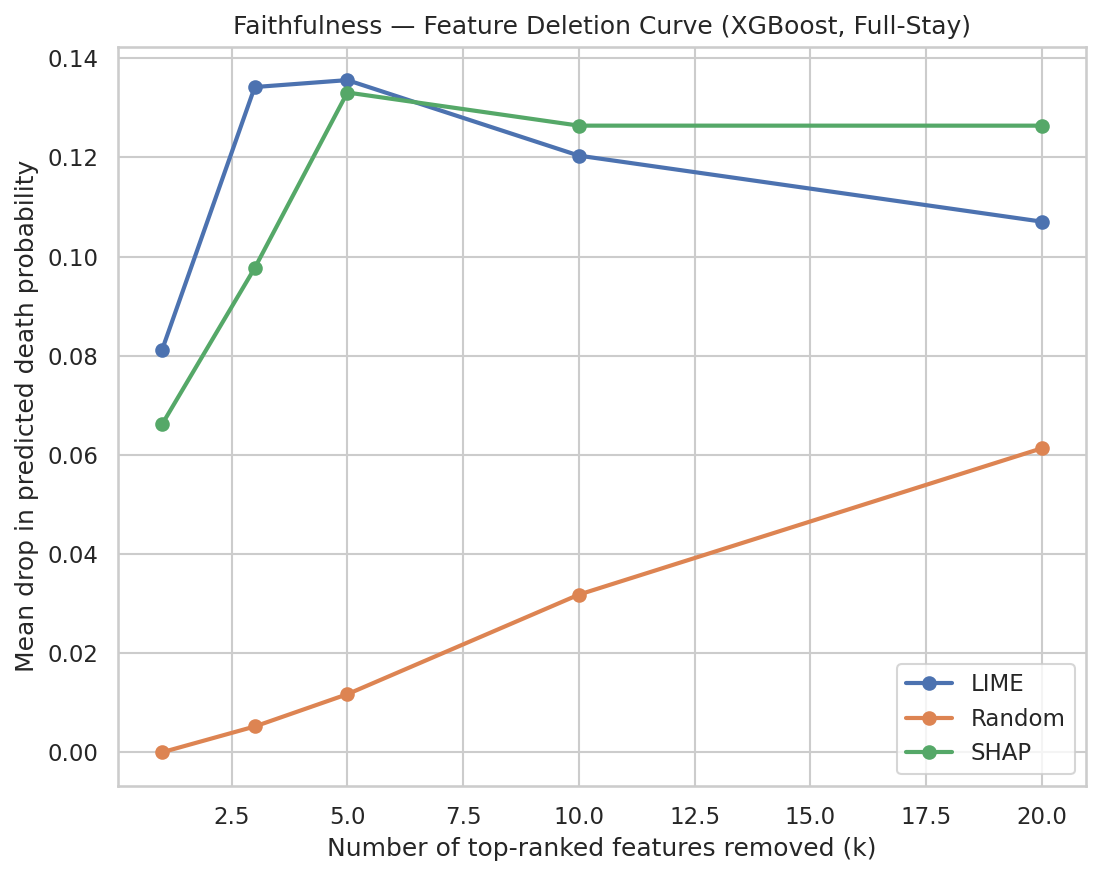

[OK] Saved: faithfulness_deletion_curve.png

Deletion AUC per method (higher = more faithful):
  SHAP: 2.307
  LIME: 2.262
  Random: 0.596

Cell 11 complete.
  SHAP outperforms random feature removal -> SHAP rankings appear faithful.
  SHAP outperforms LIME on this faithfulness test.


In [12]:
# 1. Training median per feature (used to "remove" a feature)

baseline_values = X_train_imp.median(axis=0)

print("Baseline (training median) values for occlusion:")
print(baseline_values.round(2).to_string())

# 2. Deletion functions

def run_feature_deletion(model, X_patient: pd.Series, feature_ranking: list,
                          baseline: pd.Series, k_list: list) -> dict:
    """Replace the top-k features with the median and return the drop in P(death) for each k."""
    original_proba = model.predict_proba(X_patient.to_frame().T)[0, 1]
    drops = {}

    for k in k_list:
        modified = X_patient.copy()
        top_k_features = feature_ranking[:k]
        modified[top_k_features] = baseline[top_k_features]
        new_proba = model.predict_proba(modified.to_frame().T)[0, 1]
        drops[k] = original_proba - new_proba

    return drops


def random_deletion_baseline(model, X_patient: pd.Series, all_features: list,
                              baseline: pd.Series, k_list: list,
                              n_repeats: int = 30, seed: int = RANDOM_STATE) -> dict:
    """Same thing but with k random features, averaged over n_repeats."""
    rng = np.random.default_rng(seed)
    original_proba = model.predict_proba(X_patient.to_frame().T)[0, 1]
    avg_drops = {k: [] for k in k_list}

    for _ in range(n_repeats):
        shuffled = rng.permutation(all_features)
        for k in k_list:
            modified = X_patient.copy()
            random_k_features = shuffled[:k]
            modified[random_k_features] = baseline[random_k_features]
            new_proba = model.predict_proba(modified.to_frame().T)[0, 1]
            avg_drops[k].append(original_proba - new_proba)

    return {k: np.mean(v) for k, v in avg_drops.items()}


# 3. Patients to test on

eval_indices = set()
for idx in [idx_tp, idx_tn, idx_fp, idx_fn]:
    if idx is not None:
        eval_indices.add(idx)
if LIME_AVAILABLE:
    eval_indices.update(lime_subset_indices.tolist())
eval_indices = sorted(eval_indices)

print(f"\nRunning faithfulness evaluation on {len(eval_indices)} test patients...")

# 4. Run for SHAP, LIME and random

faithfulness_rows = []

shap_abs_xgb = np.abs(shap_vals_xgb)

for i in eval_indices:
    X_patient = X_test_imp.iloc[i]
    patient_id = ids_test.iloc[i]

    # SHAP ranking
    shap_ranking = [feature_cols[j] for j in np.argsort(-shap_abs_xgb[i])]
    shap_drops = run_feature_deletion(model_xgb, X_patient, shap_ranking, baseline_values, FLIPPING_K_LIST)

    # random, 30 repeats
    random_drops = random_deletion_baseline(model_xgb, X_patient, feature_cols, baseline_values, FLIPPING_K_LIST)

    for k in FLIPPING_K_LIST:
        faithfulness_rows.append({
            "patient_index": i, "patient_id": patient_id, "method": "SHAP",
            "k": k, "probability_drop": shap_drops[k],
        })
        faithfulness_rows.append({
            "patient_index": i, "patient_id": patient_id, "method": "Random",
            "k": k, "probability_drop": random_drops[k],
        })

    # LIME ranking, only for the LIME subset
    if LIME_AVAILABLE and i in lime_subset_indices:
        patient_lime = lime_importance_df[lime_importance_df["patient_index"] == i]
        if len(patient_lime) > 0:
            lime_ranking = (
                patient_lime.assign(abs_weight=patient_lime["lime_weight"].abs())
                .sort_values("abs_weight", ascending=False)["feature"]
                .tolist()
            )
            lime_drops = run_feature_deletion(model_xgb, X_patient, lime_ranking, baseline_values, FLIPPING_K_LIST)
            for k in FLIPPING_K_LIST:
                faithfulness_rows.append({
                    "patient_index": i, "patient_id": patient_id, "method": "LIME",
                    "k": k, "probability_drop": lime_drops[k],
                })

faithfulness_df = pd.DataFrame(faithfulness_rows)
faithfulness_df.to_csv(OUTPUT_DIR / "faithfulness_results.csv", index=False)
print(f"[OK] Saved: faithfulness_results.csv ({len(faithfulness_df)} rows)")

# 5. Mean drop per method and k

faithfulness_summary = (
    faithfulness_df.groupby(["method", "k"])["probability_drop"]
    .mean().reset_index().pivot(index="k", columns="method", values="probability_drop")
)
print("\nMean probability drop by method and k (higher = more faithful):")
print(faithfulness_summary.round(4).to_string())

# 6. Deletion curve

fig, ax = plt.subplots(figsize=(7.5, 6))
for method in faithfulness_summary.columns:
    ax.plot(faithfulness_summary.index, faithfulness_summary[method],
            marker="o", linewidth=2, label=method)
ax.set_xlabel("Number of top-ranked features removed (k)")
ax.set_ylabel("Mean drop in predicted death probability")
ax.set_title("Faithfulness - Feature Deletion Curve (XGBoost, Full-Stay)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "faithfulness_deletion_curve.png", dpi=150)
plt.show()
print("[OK] Saved: faithfulness_deletion_curve.png")

# 7. Area under the deletion curve

deletion_auc = {}
trapezoid_fn = getattr(np, "trapezoid", None) or np.trapz  # trapz was renamed in numpy 2
for method in faithfulness_summary.columns:
    deletion_auc[method] = trapezoid_fn(faithfulness_summary[method], x=faithfulness_summary.index)

print("\nDeletion AUC per method (higher = more faithful):")
for method, auc_val in sorted(deletion_auc.items(), key=lambda x: -x[1]):
    print(f"  {method}: {auc_val:.3f}")

print("\n" + "=" * 50)
print("Cell 11 complete.")
if deletion_auc.get("SHAP", 0) > deletion_auc.get("Random", 0):
    print("  SHAP outperforms random feature removal -> SHAP rankings appear faithful.")
if "LIME" in deletion_auc and deletion_auc.get("SHAP", 0) > deletion_auc.get("LIME", 0):
    print("  SHAP outperforms LIME on this faithfulness test.")
print("=" * 50)

## Stability
Add small noise (5% of the feature's std) to a patient and explain again. If the top features change a lot from such a small change, the explanation is not reliable. We measure top-5/top-10 overlap and Spearman correlation.

Continuous features perturbed with noise (27): ['LDH_first', 'LDH_last', 'LDH_min', 'LDH_max', 'LDH_mean', 'LDH_std', 'LDH_range', 'LDH_slope_per_day', 'LDH_missing_rate', 'CRP_first', 'CRP_last', 'CRP_min', 'CRP_max', 'CRP_mean', 'CRP_std', 'CRP_range', 'CRP_slope_per_day', 'CRP_missing_rate', 'LYMPH_first', 'LYMPH_last', 'LYMPH_min', 'LYMPH_max', 'LYMPH_mean', 'LYMPH_std', 'LYMPH_range', 'LYMPH_slope_per_day', 'LYMPH_missing_rate']
Count features excluded from noise (3): ['LDH_count', 'CRP_count', 'LYMPH_count']

Noise scale = 0.05 * training std, applied per feature.

Running stability test on 28 patients (SHAP)...
[OK] Saved: stability_results.csv (53 rows)

Mean stability metrics by method (higher = more stable):
        top5_overlap  top10_overlap  spearman_corr
method                                            
LIME           0.547          0.532          0.562
SHAP           0.730          0.648          0.769


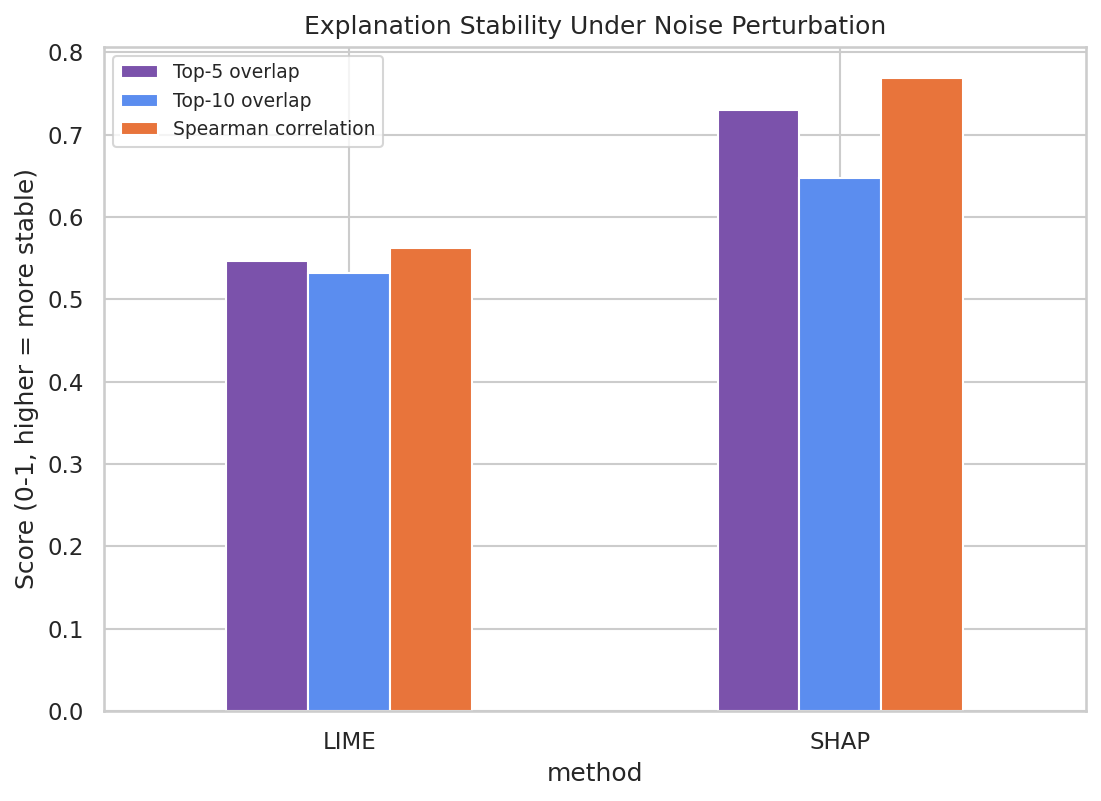

[OK] Saved: stability_barplot.png

Cell 12 complete.
  SHAP shows higher rank correlation under noise -> more stable.


In [13]:
# 1. Which features get noise (not the counts)

count_features = [c for c in feature_cols if c.endswith("_count")]
continuous_features = [c for c in feature_cols if c not in count_features]
# missing_rate is still perturbed, it is continuous even if it isn't a lab value

print(f"Continuous features perturbed with noise ({len(continuous_features)}): "
      f"{continuous_features}")
print(f"Count features excluded from noise ({len(count_features)}): {count_features}")

feature_stds = X_train_imp[continuous_features].std()
print(f"\nNoise scale = {NOISE_SCALE} * training std, applied per feature.")

# 2. Helpers

def get_top_k_features(values: np.ndarray, names: list, k: int) -> set:
    """Return the set of the k feature names with highest |value|."""
    order = np.argsort(-np.abs(values))[:k]
    return set(np.array(names)[order])


def jaccard_overlap(set_a: set, set_b: set) -> float:
    """Fraction of overlap between two top-k feature sets (0 to 1)."""
    if len(set_a) == 0 and len(set_b) == 0:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


# 3. Run for SHAP and LIME

rng_noise = np.random.default_rng(RANDOM_STATE)
stability_rows = []

print(f"\nRunning stability test on {len(eval_indices)} patients (SHAP)...")

for i in eval_indices:
    X_original = X_test_imp.iloc[i].copy()
    patient_id = ids_test.iloc[i]

    # noisy copy of the patient
    X_noisy = X_original.copy()
    noise = rng_noise.normal(0, NOISE_SCALE * feature_stds.values, size=len(continuous_features))
    X_noisy[continuous_features] = X_original[continuous_features].values + noise

    # SHAP original vs noisy
    shap_original = shap_vals_xgb[i]
    shap_noisy_exp = explainer_xgb(X_noisy.to_frame().T)
    shap_noisy = get_shap_values_for_positive_class(shap_noisy_exp)[0]

    top5_orig  = get_top_k_features(shap_original, feature_cols, 5)
    top5_noisy = get_top_k_features(shap_noisy, feature_cols, 5)
    top10_orig  = get_top_k_features(shap_original, feature_cols, 10)
    top10_noisy = get_top_k_features(shap_noisy, feature_cols, 10)

    spearman_corr, _ = spearmanr(shap_original, shap_noisy)

    stability_rows.append({
        "patient_index": i, "patient_id": patient_id, "method": "SHAP",
        "top5_overlap": jaccard_overlap(top5_orig, top5_noisy),
        "top10_overlap": jaccard_overlap(top10_orig, top10_noisy),
        "spearman_corr": spearman_corr,
    })

    # LIME original vs noisy (subset only)
    if LIME_AVAILABLE and i in lime_subset_indices:
        patient_lime_orig = lime_importance_df[lime_importance_df["patient_index"] == i]
        if len(patient_lime_orig) > 0:
            orig_weights = patient_lime_orig.set_index("feature")["lime_weight"]

            lime_noisy_exp = lime_explainer.explain_instance(
                X_noisy.values, predict_fn_xgb,
                num_features=len(feature_cols), num_samples=LIME_N_SAMPLES,
            )
            noisy_weights = pd.Series({
                (f := max((fc for fc in feature_cols if fc in cond), key=len, default=None)): w
                for cond, w in lime_noisy_exp.as_list() if
                max((fc for fc in feature_cols if fc in cond), key=len, default=None) is not None
            })

            # same feature order for both
            shared_feats = orig_weights.index.intersection(noisy_weights.index)
            if len(shared_feats) >= 5:
                orig_vals_aligned = orig_weights.reindex(feature_cols).fillna(0).values
                noisy_vals_aligned = noisy_weights.reindex(feature_cols).fillna(0).values

                top5_orig_l  = get_top_k_features(orig_vals_aligned, feature_cols, 5)
                top5_noisy_l = get_top_k_features(noisy_vals_aligned, feature_cols, 5)
                top10_orig_l  = get_top_k_features(orig_vals_aligned, feature_cols, 10)
                top10_noisy_l = get_top_k_features(noisy_vals_aligned, feature_cols, 10)

                spearman_corr_l, _ = spearmanr(orig_vals_aligned, noisy_vals_aligned)

                stability_rows.append({
                    "patient_index": i, "patient_id": patient_id, "method": "LIME",
                    "top5_overlap": jaccard_overlap(top5_orig_l, top5_noisy_l),
                    "top10_overlap": jaccard_overlap(top10_orig_l, top10_noisy_l),
                    "spearman_corr": spearman_corr_l,
                })

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(OUTPUT_DIR / "stability_results.csv", index=False)
print(f"[OK] Saved: stability_results.csv ({len(stability_df)} rows)")

# 4. Summary and plot

stability_summary = stability_df.groupby("method")[["top5_overlap", "top10_overlap", "spearman_corr"]].mean()
print("\nMean stability metrics by method (higher = more stable):")
print(stability_summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.5, 5.5))
stability_summary.plot(kind="bar", ax=ax, color=["#7B52AB", "#5B8DEF", "#E8743B"])
ax.set_ylabel("Score (0-1, higher = more stable)")
ax.set_title("Explanation Stability Under Noise Perturbation")
ax.set_xticklabels(stability_summary.index, rotation=0)
ax.legend(["Top-5 overlap", "Top-10 overlap", "Spearman correlation"], fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stability_barplot.png", dpi=150)
plt.show()
print("[OK] Saved: stability_barplot.png")

print("\n" + "=" * 50)
print("Cell 12 complete.")
if "LIME" in stability_summary.index and "SHAP" in stability_summary.index:
    more_stable = "SHAP" if stability_summary.loc["SHAP", "spearman_corr"] > stability_summary.loc["LIME", "spearman_corr"] else "LIME"
    print(f"  {more_stable} shows higher rank correlation under noise -> more stable.")
print("=" * 50)

## Sparsity and runtime
How many features are needed to cover 80% of the explanation (fewer is easier to read), the entropy of the attributions, and how long each method takes per patient.

[OK] Saved: sparsity_results.csv (53 rows)

Mean sparsity metrics by method:
(Out of 30 total features; lower n_features_for_80pct and lower entropy both mean a SIMPLER explanation)
        n_features_for_80pct  entropy  top3_concentration  top5_concentration  top10_concentration
method                                                                                            
LIME                   8.520    2.251               0.643               0.720                0.842
SHAP                   2.857    1.402               0.843               0.931                0.993

Measuring runtime per patient...
[OK] Saved: runtime_results.csv

Mean runtime per patient (seconds):
           method  mean_seconds_per_patient
             SHAP                    0.0358
             LIME                    0.0524
Feature Occlusion                    0.0200


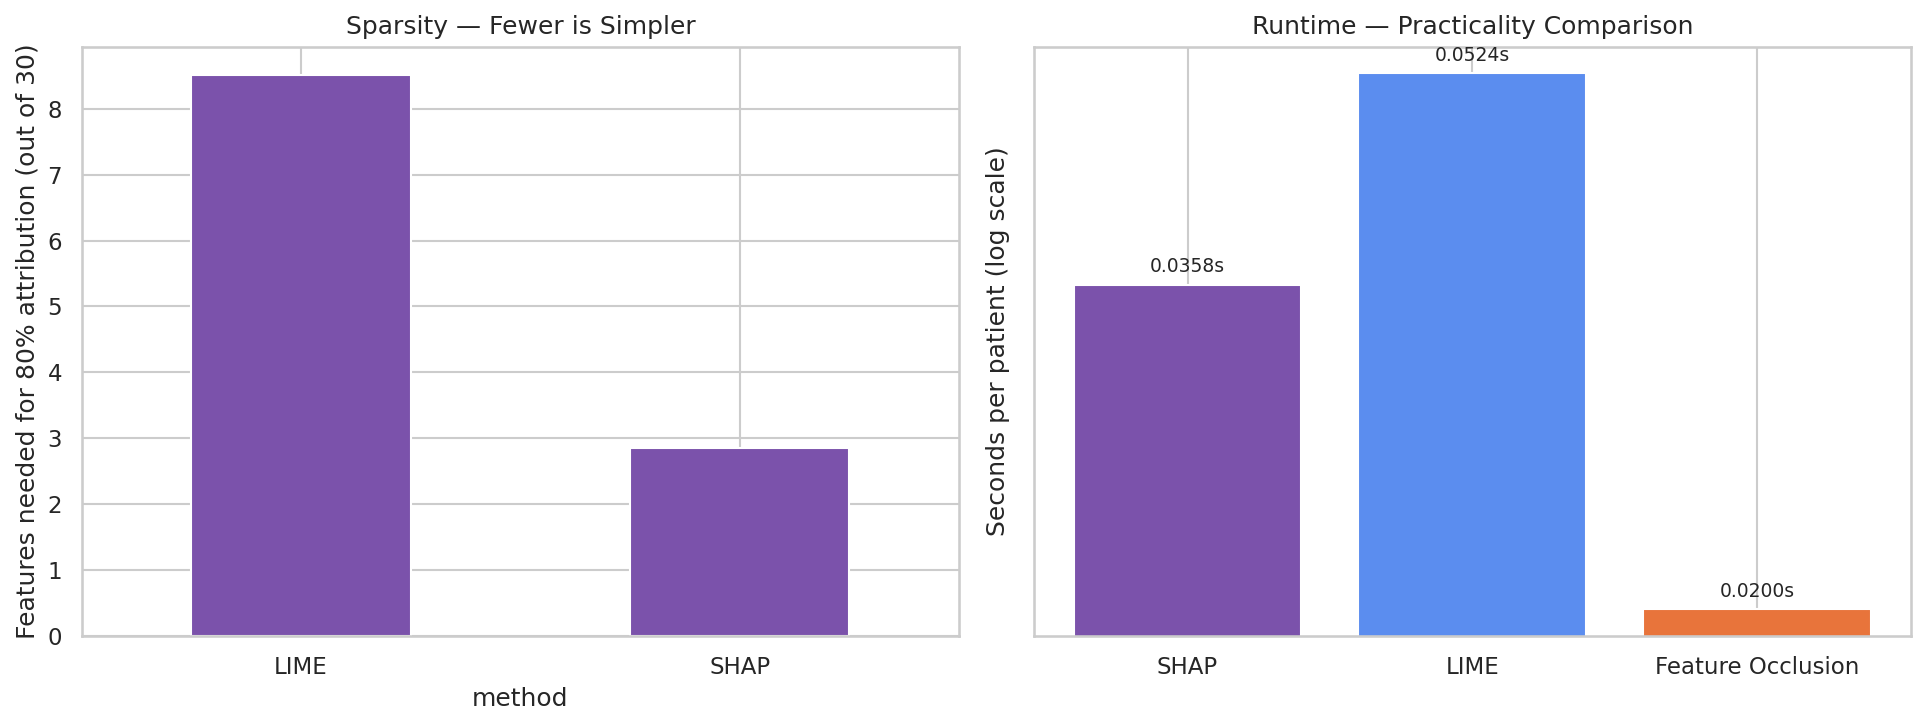

[OK] Saved: sparsity_runtime_combined.png

Cell 13 complete.
  Sparsity: lower n_features_for_80pct = simpler explanation
  Runtime: SHAP=0.0358s, LIME=0.0524s, Occlusion=0.0200s per patient


In [14]:
def sparsity_metrics_for_explanation(values: np.ndarray, feature_names: list) -> dict:
    """Features needed for 80% of |attribution|, entropy, and top-3/5/10 share."""
    abs_vals = np.abs(values)
    total = abs_vals.sum()

    if total == 0:
        return {"n_features_for_80pct": len(feature_names), "entropy": np.nan,
                "top3_concentration": np.nan, "top5_concentration": np.nan,
                "top10_concentration": np.nan}

    sorted_vals = np.sort(abs_vals)[::-1]
    cumulative = np.cumsum(sorted_vals) / total
    n_for_80 = int(np.searchsorted(cumulative, 0.80) + 1)

    probs = abs_vals / total
    probs_nonzero = probs[probs > 0]
    entropy = -np.sum(probs_nonzero * np.log(probs_nonzero))

    return {
        "n_features_for_80pct": n_for_80,
        "entropy": entropy,
        "top3_concentration": sorted_vals[:3].sum() / total,
        "top5_concentration": sorted_vals[:5].sum() / total,
        "top10_concentration": sorted_vals[:10].sum() / total,
    }


# 1. Sparsity for SHAP and LIME

sparsity_rows = []

for i in eval_indices:
    patient_id = ids_test.iloc[i]
    shap_metrics = sparsity_metrics_for_explanation(shap_vals_xgb[i], feature_cols)
    sparsity_rows.append({"patient_index": i, "patient_id": patient_id, "method": "SHAP", **shap_metrics})

    if LIME_AVAILABLE and i in lime_subset_indices:
        patient_lime = lime_importance_df[lime_importance_df["patient_index"] == i]
        if len(patient_lime) > 0:
            lime_vals_aligned = (
                patient_lime.set_index("feature")["lime_weight"]
                .reindex(feature_cols).fillna(0).values
            )
            lime_metrics = sparsity_metrics_for_explanation(lime_vals_aligned, feature_cols)
            sparsity_rows.append({"patient_index": i, "patient_id": patient_id, "method": "LIME", **lime_metrics})

sparsity_df = pd.DataFrame(sparsity_rows)
sparsity_df.to_csv(OUTPUT_DIR / "sparsity_results.csv", index=False)
print(f"[OK] Saved: sparsity_results.csv ({len(sparsity_df)} rows)")

sparsity_summary = sparsity_df.groupby("method")[
    ["n_features_for_80pct", "entropy", "top3_concentration", "top5_concentration", "top10_concentration"]
].mean()
print("\nMean sparsity metrics by method:")
print(f"(Out of {len(feature_cols)} total features; lower n_features_for_80pct and "
      f"lower entropy both mean a SIMPLER explanation)")
print(sparsity_summary.round(3).to_string())

# 2. Runtime (LIME was already timed when we ran it)

print("\nMeasuring runtime per patient...")

# SHAP, one patient at a time
shap_times = []
for i in eval_indices[:15]:  # 15 is enough
    t0 = time.time()
    _ = explainer_xgb(X_test_imp.iloc[[i]])
    shap_times.append(time.time() - t0)

# one full deletion run
occlusion_times = []
for i in eval_indices[:15]:
    t0 = time.time()
    shap_ranking = [feature_cols[j] for j in np.argsort(-shap_abs_xgb[i])]
    _ = run_feature_deletion(model_xgb, X_test_imp.iloc[i], shap_ranking, baseline_values, FLIPPING_K_LIST)
    occlusion_times.append(time.time() - t0)

runtime_summary = pd.DataFrame({
    "method": ["SHAP", "LIME", "Feature Occlusion"],
    "mean_seconds_per_patient": [
        np.mean(shap_times),
        np.mean(lime_runtimes) if LIME_AVAILABLE else np.nan,
        np.mean(occlusion_times),
    ],
})
runtime_summary.to_csv(OUTPUT_DIR / "runtime_results.csv", index=False)
print(f"[OK] Saved: runtime_results.csv")
print("\nMean runtime per patient (seconds):")
print(runtime_summary.round(4).to_string(index=False))

# 3. Plot

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# features needed for 80% of the attribution
ax = axes[0]
sparsity_summary["n_features_for_80pct"].plot(kind="bar", ax=ax, color="#7B52AB")
ax.set_ylabel(f"Features needed for 80% attribution (out of {len(feature_cols)})")
ax.set_title("Sparsity - Fewer is Simpler")
ax.set_xticklabels(sparsity_summary.index, rotation=0)

# runtime, log scale
ax = axes[1]
runtime_summary_plot = runtime_summary.dropna()
bars = ax.bar(runtime_summary_plot["method"], runtime_summary_plot["mean_seconds_per_patient"],
              color=["#7B52AB", "#5B8DEF", "#E8743B"][:len(runtime_summary_plot)])
ax.set_yscale("log")
ax.set_ylabel("Seconds per patient (log scale)")
ax.set_title("Runtime - Practicality Comparison")
ax.yaxis.set_major_formatter(matplotlib.ticker.LogFormatter())
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
# write the values on the bars, small ones are hard to see on log scale
for bar, val in zip(bars, runtime_summary_plot["mean_seconds_per_patient"]):
    ax.annotate(f"{val:.4f}s", (bar.get_x() + bar.get_width()/2, val),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sparsity_runtime_combined.png", dpi=150)
plt.show()
print("[OK] Saved: sparsity_runtime_combined.png")

print("\n" + "=" * 50)
print("Cell 13 complete.")
print(f"  Sparsity: lower n_features_for_80pct = simpler explanation")
print(f"  Runtime: SHAP={np.mean(shap_times):.4f}s, "
      f"LIME={np.mean(lime_runtimes) if LIME_AVAILABLE else float('nan'):.4f}s, "
      f"Occlusion={np.mean(occlusion_times):.4f}s per patient")
print("=" * 50)

## SHAP per biomarker
Sum the SHAP importance of the 10 features of each biomarker, so we get one number for LDH, CRP and LYMPH. This shows what the model relies on, not what causes death.

Feature -> biomarker mapping (sample):
  LDH_first -> LDH
  LDH_last -> LDH
  LDH_min -> LDH
  LDH_max -> LDH
  LDH_mean -> LDH

[OK] Saved: grouped_biomarker_shap_importance_full.csv

Grouped biomarker-level SHAP importance (XGBoost, full-stay):
biomarker  mean_abs_shap  share_of_total
      LDH         0.1197          0.4896
      CRP         0.0788          0.3222
    LYMPH         0.0460          0.1881


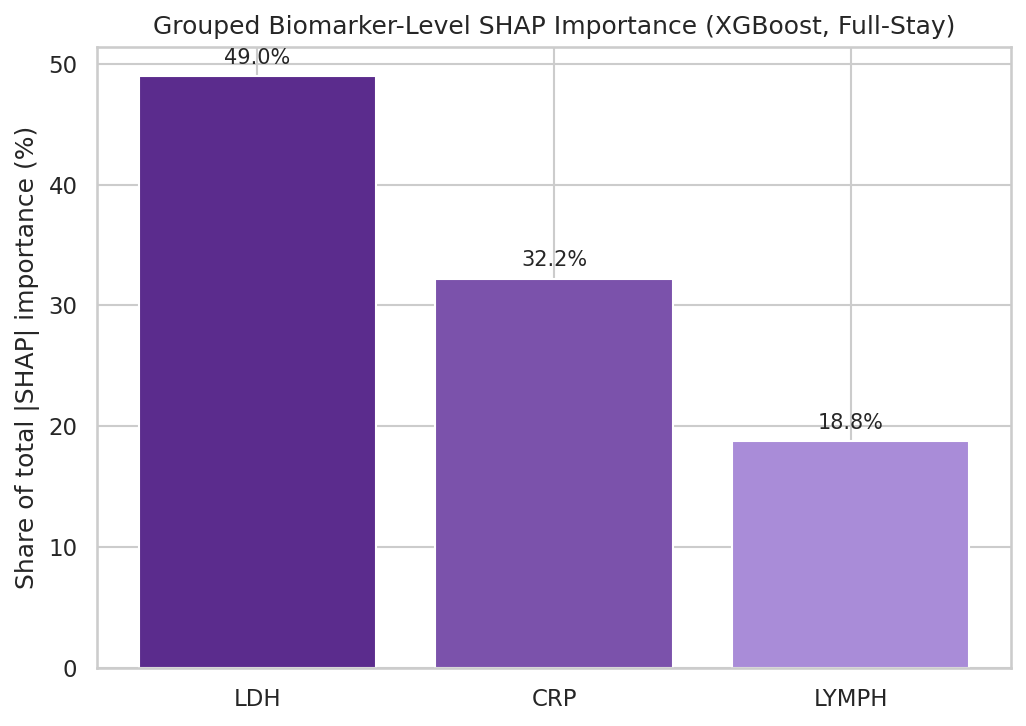

[OK] Saved: grouped_biomarker_shap_bar_full.png

[RESULT]
At the individual-feature level, ['LDH_last', 'CRP_last', 'LYMPH_min'] were the most
influential temporal features. At the biomarker-group level, LDH contributed the largest
share of total model explanation (49.0%), followed by CRP (32.2%). These results
indicate which variables influenced the trained model's predictions; they should not be
interpreted as evidence that these biomarkers causally determine COVID-19 mortality.

Cell 14 complete.
  Biomarker ranking: ['LDH', 'CRP', 'LYMPH']


In [15]:
# 1. Feature -> biomarker

def get_biomarker_for_feature(feature_name: str, biomarkers: list) -> str:
    """'LDH_last' -> 'LDH'"""
    for marker in biomarkers:
        if feature_name.startswith(marker + "_"):
            return marker
    return "other"


feature_to_biomarker = {f: get_biomarker_for_feature(f, BIOMARKERS) for f in feature_cols}

print("Feature -> biomarker mapping (sample):")
for f in feature_cols[:5]:
    print(f"  {f} -> {feature_to_biomarker[f]}")

# 2. Sum mean |SHAP| per biomarker

feature_importance = mean_abs_shap_xgb.copy()
feature_importance["biomarker"] = feature_importance["feature"].map(feature_to_biomarker)

grouped_importance = (
    feature_importance.groupby("biomarker")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
grouped_importance["share_of_total"] = (
    grouped_importance["mean_abs_shap"] / grouped_importance["mean_abs_shap"].sum()
)

grouped_importance.to_csv(OUTPUT_DIR / "grouped_biomarker_shap_importance_full.csv", index=False)
print(f"\n[OK] Saved: grouped_biomarker_shap_importance_full.csv")
print("\nGrouped biomarker-level SHAP importance (XGBoost, full-stay):")
print(grouped_importance.round(4).to_string(index=False))

# 3. Bar chart

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#5B2C8D", "#7B52AB", "#A98CD8"]
ax.bar(grouped_importance["biomarker"], grouped_importance["share_of_total"] * 100,
       color=colors[:len(grouped_importance)])
ax.set_ylabel("Share of total |SHAP| importance (%)")
ax.set_title("Grouped Biomarker-Level SHAP Importance (XGBoost, Full-Stay)")
for i, row in grouped_importance.iterrows():
    ax.text(i, row["share_of_total"] * 100 + 1, f"{row['share_of_total']*100:.1f}%",
            ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grouped_biomarker_shap_bar_full.png", dpi=150)
plt.show()
print("[OK] Saved: grouped_biomarker_shap_bar_full.png")

# 4. Print the result

top_biomarker = grouped_importance.iloc[0]
second_biomarker = grouped_importance.iloc[1]

print("\n[RESULT]")
print(textwrap.fill(
    f"At the individual-feature level, {feature_importance.nlargest(3, 'mean_abs_shap')['feature'].tolist()} "
    f"were the most influential temporal features. At the biomarker-group level, "
    f"{top_biomarker['biomarker']} contributed the largest share of total model explanation "
    f"({top_biomarker['share_of_total']*100:.1f}%), followed by {second_biomarker['biomarker']} "
    f"({second_biomarker['share_of_total']*100:.1f}%). These results indicate which variables "
    f"influenced the trained model's predictions; they should not be interpreted as evidence "
    f"that these biomarkers causally determine COVID-19 mortality.",
    width=88
))

print("\n" + "=" * 50)
print("Cell 14 complete.")
print(f"  Biomarker ranking: {grouped_importance['biomarker'].tolist()}")
print("=" * 50)

## Clever-Hans check
Earlier plots show missing_rate features fairly high up, especially for logistic regression. That would mean the model partly learns how often a patient was tested instead of the actual values. Here we measure how much of the SHAP importance goes to count and missing_rate features.

In [16]:
SUSPICIOUS_PATTERNS = ["count", "missing_rate"]
LEAKAGE_NAME_KEYWORDS = [
    "discharge", "death", "dead", "survival", "outcome",
    "length_of_stay", "los", "final", "result",
]

# 1. Check the feature names again

leakage_named_features = [
    f for f in feature_cols
    if any(kw in f.lower() for kw in LEAKAGE_NAME_KEYWORDS)
]

print(f"Leakage-named features found in final feature set: {len(leakage_named_features)}")
if leakage_named_features:
    print(f"  [CRITICAL] Found: {leakage_named_features} - these must be removed before proceeding.")
else:
    print("  [OK] None found. Confirms Cell 4's exclusion list worked correctly.")

# 2. Share of SHAP that goes to count / missing_rate features

def compute_suspicious_share(shap_values: np.ndarray, feature_names: list,
                              suspicious_patterns: list) -> dict:
    """Share of mean |SHAP| that goes to count / missing_rate features."""
    mean_abs = np.abs(shap_values).mean(axis=0)
    total = mean_abs.sum()

    is_suspicious = np.array([
        any(pat in f for pat in suspicious_patterns) for f in feature_names
    ])

    suspicious_share = mean_abs[is_suspicious].sum() / total
    suspicious_features_ranked = sorted(
        zip(np.array(feature_names)[is_suspicious], mean_abs[is_suspicious]),
        key=lambda x: -x[1]
    )

    return {
        "suspicious_share": suspicious_share,
        "suspicious_features_ranked": suspicious_features_ranked,
    }


leakage_check_rows = []
clever_hans_results = {}

for model_name, shap_vals in [
    ("Logistic Regression", shap_vals_logreg),
    ("Decision Tree", shap_vals_tree),
    ("XGBoost (main)", shap_vals_xgb),
]:
    result = compute_suspicious_share(shap_vals, feature_cols, SUSPICIOUS_PATTERNS)
    clever_hans_results[model_name] = result

    print(f"\n--- {model_name} ---")
    print(f"  Suspicious (count/missing_rate) feature share of total |SHAP|: "
          f"{result['suspicious_share']*100:.1f}%")
    print(f"  Top suspicious features:")
    for feat, val in result["suspicious_features_ranked"][:5]:
        print(f"    {feat}: {val:.4f}")

    for feat, val in result["suspicious_features_ranked"]:
        leakage_check_rows.append({
            "model": model_name, "feature": feat, "mean_abs_shap": val,
            "suspicious_share_of_model": result["suspicious_share"],
        })

leakage_check_df = pd.DataFrame(leakage_check_rows)
leakage_check_df.to_csv(OUTPUT_DIR / "leakage_feature_check.csv", index=False)
print(f"\n[OK] Saved: leakage_feature_check.csv")

# 3. Verdict per model
# we flag a model if more than 30% of the SHAP goes to these features (our own cutoff, not a stats test)

CLEVER_HANS_THRESHOLD = 0.30

verdict_lines = ["# Clever-Hans / Leakage Analysis Summary\n"]
verdict_lines.append(f"Suspicious feature patterns checked: {SUSPICIOUS_PATTERNS}")
verdict_lines.append(f"Leakage-named features in final feature set: "
                      f"{leakage_named_features if leakage_named_features else 'None found'}")
verdict_lines.append(f"\nDecision threshold: a model is flagged if suspicious "
                      f"(count/missing_rate) features account for more than "
                      f"{CLEVER_HANS_THRESHOLD*100:.0f}% of its total SHAP importance.\n")

for model_name, result in clever_hans_results.items():
    share = result["suspicious_share"]
    flagged = share > CLEVER_HANS_THRESHOLD
    verdict = "FLAGGED - relies meaningfully on process signals" if flagged else "OK - relies mainly on biomarker values"

    verdict_lines.append(f"## {model_name}")
    verdict_lines.append(f"- Suspicious feature share: {share*100:.1f}%")
    verdict_lines.append(f"- Verdict: {verdict}")
    top_3 = result["suspicious_features_ranked"][:3]
    if top_3:
        verdict_lines.append(f"- Top suspicious features: " +
                              ", ".join(f"{f} ({v:.3f})" for f, v in top_3))
    verdict_lines.append("")

verdict_lines.append("## Interpretation")
verdict_lines.append(textwrap.fill(
    "Missingness and measurement frequency may act as proxy signals for "
    "clinical severity, since sicker patients are typically monitored more "
    "closely. This is not necessarily an invalid signal for the model to use, "
    "but it limits how the explanations can be interpreted clinically: a high "
    "SHAP value for 'LYMPH_missing_rate' indicates the model is partly "
    "responding to how often a patient was tested, not solely to their "
    "lymphocyte percentage value itself. The linear model (Logistic Regression) "
    "relies on these proxy signals far more heavily than the tree-based models "
    "(Decision Tree, XGBoost), which lean more on direct biomarker values "
    "(LDH_last, CRP_last) with missingness as a secondary factor.",
    width=88
))
verdict_lines.append("")
verdict_lines.append(textwrap.fill(
    "These explanations indicate which variables influenced the model, not "
    "which variables causally determine mortality.",
    width=88
))

with open(OUTPUT_DIR / "clever_hans_summary.md", "w") as f:
    f.write("\n".join(verdict_lines))

print(f"\n[OK] Saved: clever_hans_summary.md")
print("\n" + "=" * 50)
print("CLEVER-HANS VERDICT SUMMARY:")
for model_name, result in clever_hans_results.items():
    share = result["suspicious_share"]
    flag = "FLAGGED" if share > CLEVER_HANS_THRESHOLD else "OK"
    print(f"  {model_name}: {share*100:.1f}% suspicious -> {flag}")
print("=" * 50)
print("\nCell 15 complete.")
print("=" * 50)

Leakage-named features found in final feature set: 0
  [OK] None found. Confirms Cell 4's exclusion list worked correctly.

--- Logistic Regression ---
  Suspicious (count/missing_rate) feature share of total |SHAP|: 50.5%
  Top suspicious features:
    LDH_missing_rate: 3.0008
    CRP_missing_rate: 2.6032
    LYMPH_missing_rate: 0.9856
    LDH_count: 0.3828
    LYMPH_count: 0.2369

--- Decision Tree ---
  Suspicious (count/missing_rate) feature share of total |SHAP|: 7.3%
  Top suspicious features:
    LYMPH_missing_rate: 0.0197
    CRP_missing_rate: 0.0177
    LDH_count: 0.0000
    LDH_missing_rate: 0.0000
    CRP_count: 0.0000

--- XGBoost (main) ---
  Suspicious (count/missing_rate) feature share of total |SHAP|: 0.2%
  Top suspicious features:
    CRP_missing_rate: 0.0002
    LDH_count: 0.0001
    CRP_count: 0.0001
    LDH_missing_rate: 0.0001
    LYMPH_count: 0.0000

[OK] Saved: leakage_feature_check.csv

[OK] Saved: clever_hans_summary.md

CLEVER-HANS VERDICT SUMMARY:
  Logistic

## SHAP per patient group
Mean SHAP for true/false positives and negatives, and for the highest and lowest risk quartiles. The idea is to see whether the missed deaths look different from the correctly predicted ones.

Patient group sizes (test set, n=110):
  True Positive: 12 patients
  True Negative: 95 patients
  False Positive: 2 patients  [CAUTION: very small group, treat as anecdotal]
  False Negative: 1 patients  [CAUTION: very small group, treat as anecdotal]
  High-risk quartile: 28 patients
  Low-risk quartile: 36 patients

[NOTE] Groups with fewer than 5 patients: [('False Positive', np.int64(2)), ('False Negative', np.int64(1))]. Their mean SHAP is just one or two patients, so we treat them as examples, not patterns.

[OK] Saved: patient_risk_groups.csv
[OK] Saved: group_shap_top_features.csv

Top 5 SHAP features per group:

  True Positive (n=12):
    1. LDH_last: |SHAP|=0.383 (+)
    2. CRP_last: |SHAP|=0.211 (+)
    3. LYMPH_min: |SHAP|=0.090 (+)
    4. LYMPH_last: |SHAP|=0.090 (+)
    5. CRP_mean: |SHAP|=0.030 (+)

  True Negative (n=95):
    1. LDH_last: |SHAP|=0.068 (-)
    2. CRP_last: |SHAP|=0.041 (-)
    3. LYMPH_min: |SHAP|=0.010 (-)
    4. LYMPH_last: |SHAP|=0.009 (-)
    5. CR

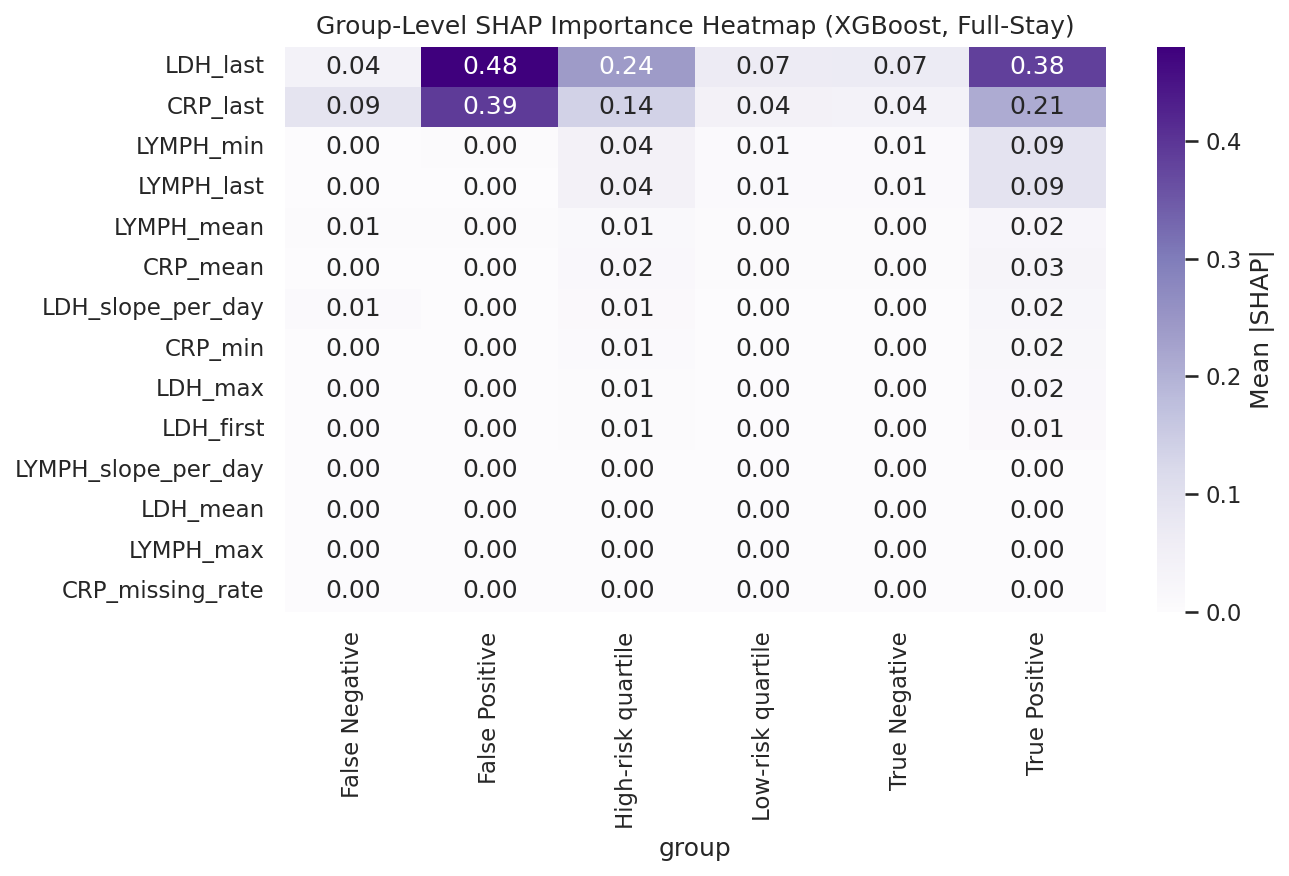


[OK] Saved: group_shap_heatmap.png

Cell 16 complete.


In [17]:
# 1. The 6 groups

y_proba_arr = results_xgb["y_proba"]
y_pred_arr = results_xgb["y_pred"]
y_test_arr = y_test.values

q75 = np.percentile(y_proba_arr, 75)
q25 = np.percentile(y_proba_arr, 25)

group_masks = {
    "True Positive":      (y_test_arr == 1) & (y_pred_arr == 1),
    "True Negative":      (y_test_arr == 0) & (y_pred_arr == 0),
    "False Positive":     (y_test_arr == 0) & (y_pred_arr == 1),
    "False Negative":     (y_test_arr == 1) & (y_pred_arr == 0),
    "High-risk quartile": y_proba_arr >= q75,
    "Low-risk quartile":  y_proba_arr <= q25,
}

print("Patient group sizes (test set, n=110):")
risk_groups_rows = []
SMALL_GROUP_THRESHOLD = 5  # warn if a group is smaller than this

small_groups = []
for group_name, mask in group_masks.items():
    n = mask.sum()
    flag = "  [CAUTION: very small group, treat as anecdotal]" if 0 < n < SMALL_GROUP_THRESHOLD else ""
    print(f"  {group_name}: {n} patients{flag}")
    if 0 < n < SMALL_GROUP_THRESHOLD:
        small_groups.append((group_name, n))
    for i in np.where(mask)[0]:
        risk_groups_rows.append({
            "patient_index": i,
            "patient_id": ids_test.iloc[i],
            "group": group_name,
            "actual_outcome": y_test_arr[i],
            "predicted_outcome": y_pred_arr[i],
            "predicted_probability": y_proba_arr[i],
        })

if small_groups:
    print(f"\n[NOTE] Groups with fewer than {SMALL_GROUP_THRESHOLD} patients: {small_groups}. "
          f"Their mean SHAP is just one or two patients, so we treat them as examples, not patterns.")

patient_risk_groups_df = pd.DataFrame(risk_groups_rows)
patient_risk_groups_df.to_csv(OUTPUT_DIR / "patient_risk_groups.csv", index=False)
print(f"\n[OK] Saved: patient_risk_groups.csv")

# 2. Mean SHAP per group, top 10

group_shap_rows = []

for group_name, mask in group_masks.items():
    if mask.sum() == 0:
        print(f"  [SKIP] {group_name} - no patients in this group.")
        continue

    group_shap_vals = shap_vals_xgb[mask]
    mean_abs = np.abs(group_shap_vals).mean(axis=0)
    mean_signed = group_shap_vals.mean(axis=0)

    top10_idx = np.argsort(-mean_abs)[:10]
    for rank, idx in enumerate(top10_idx, start=1):
        group_shap_rows.append({
            "group": group_name,
            "rank": rank,
            "feature": feature_cols[idx],
            "mean_abs_shap": mean_abs[idx],
            "mean_signed_shap": mean_signed[idx],
            "n_patients": mask.sum(),
        })

group_shap_df = pd.DataFrame(group_shap_rows)
group_shap_df.to_csv(OUTPUT_DIR / "group_shap_top_features.csv", index=False)
print(f"[OK] Saved: group_shap_top_features.csv")

print("\nTop 5 SHAP features per group:")
for group_name in group_masks.keys():
    subset = group_shap_df[group_shap_df["group"] == group_name].head(5)
    if len(subset) == 0:
        continue
    print(f"\n  {group_name} (n={subset['n_patients'].iloc[0]}):")
    for _, row in subset.iterrows():
        sign = "+" if row["mean_signed_shap"] >= 0 else "-"
        print(f"    {row['rank']}. {row['feature']}: |SHAP|={row['mean_abs_shap']:.3f} ({sign})")

# 3. Overlap of top features between groups

def get_top_k_set(group_name: str, k: int = 5) -> set:
    subset = group_shap_df[group_shap_df["group"] == group_name].nsmallest(k, "rank")
    return set(subset["feature"])

comparison_pairs = [
    ("True Positive", "False Negative"),   # both died
    ("True Negative", "False Positive"),   # both survived
    ("High-risk quartile", "Low-risk quartile"),
]

print("\nTop-5 feature overlap between related groups:")
for group_a, group_b in comparison_pairs:
    set_a, set_b = get_top_k_set(group_a), get_top_k_set(group_b)
    if len(set_a) == 0 or len(set_b) == 0:
        print(f"  {group_a} vs {group_b}: skipped (one group empty)")
        continue
    overlap = len(set_a & set_b) / len(set_a | set_b)
    print(f"  {group_a} vs {group_b}: {overlap:.2f} Jaccard overlap")
    if overlap < 0.5:
        print(f"    -> Notably different top features: "
              f"{group_a} unique = {set_a - set_b}, {group_b} unique = {set_b - set_a}")

# 4. Heatmap

heatmap_data = group_shap_df.pivot_table(
    index="feature", columns="group", values="mean_abs_shap", fill_value=0
)
# only features that are in some group's top 10
heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(9, max(6, len(heatmap_data) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Purples", ax=ax, cbar_kws={"label": "Mean |SHAP|"})
ax.set_title("Group-Level SHAP Importance Heatmap (XGBoost, Full-Stay)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "group_shap_heatmap.png", dpi=150)
plt.show()
print("\n[OK] Saved: group_shap_heatmap.png")

print("\n" + "=" * 50)
print("Cell 16 complete.")
print("=" * 50)

## PCA
The test patients projected to 2D, coloured by outcome, predicted risk and error type. Just a visual check that the two groups separate and that the errors sit near the border.

PCA fitted on training data (300 patients, 30 features).
  PC1 explains 36.3% of variance
  PC2 explains 16.2% of variance
  Total (PC1+PC2): 52.6%


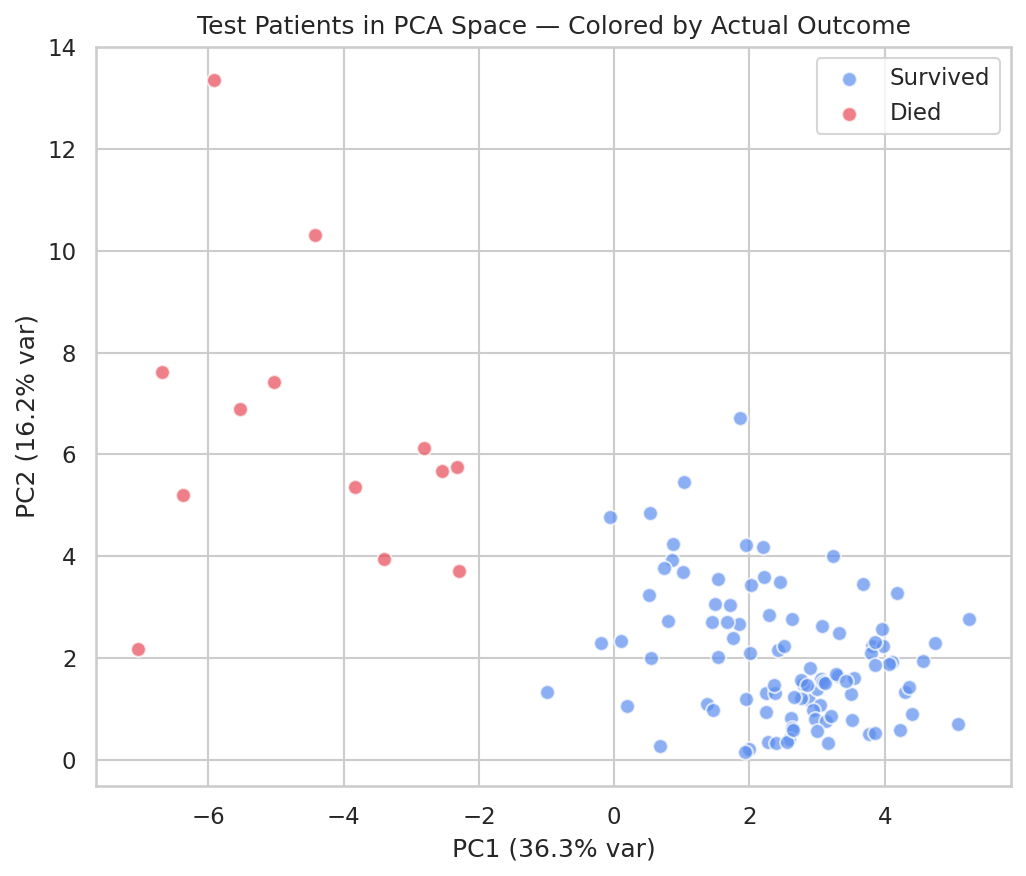

[OK] Saved: pca_patients_by_outcome.png


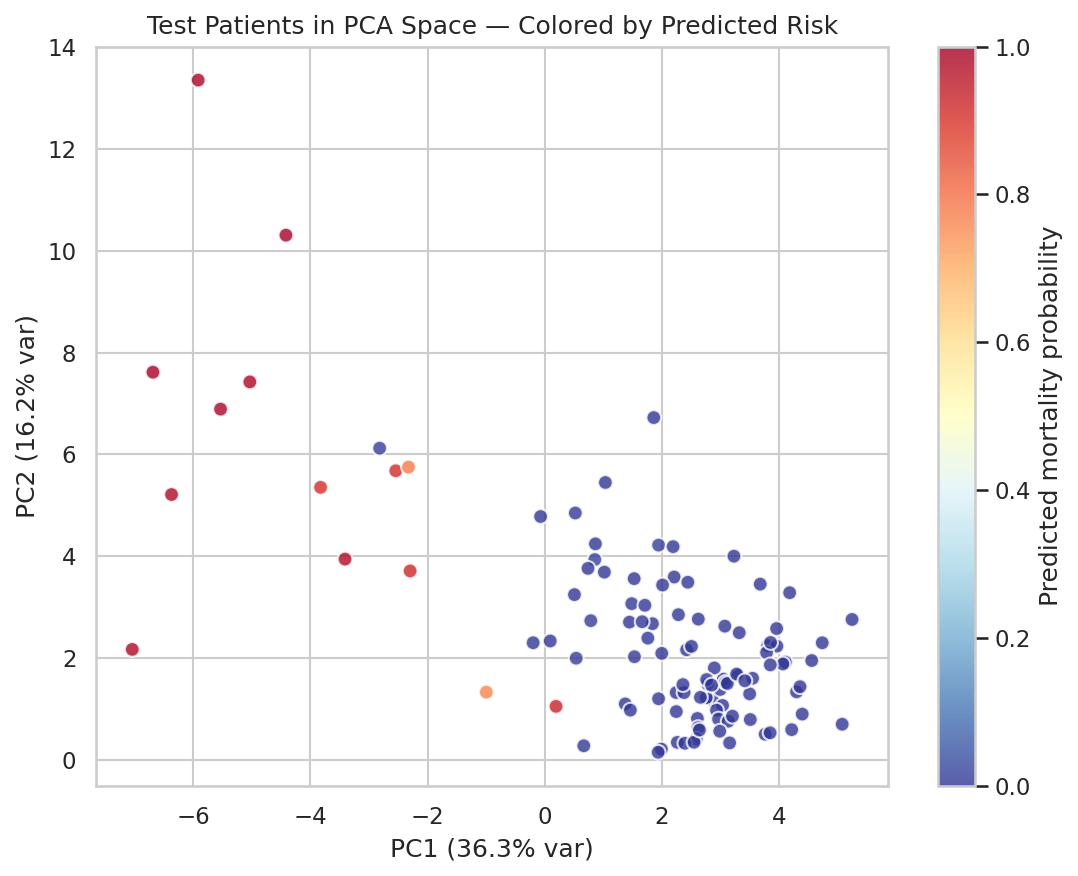

[OK] Saved: pca_patients_by_predicted_risk.png


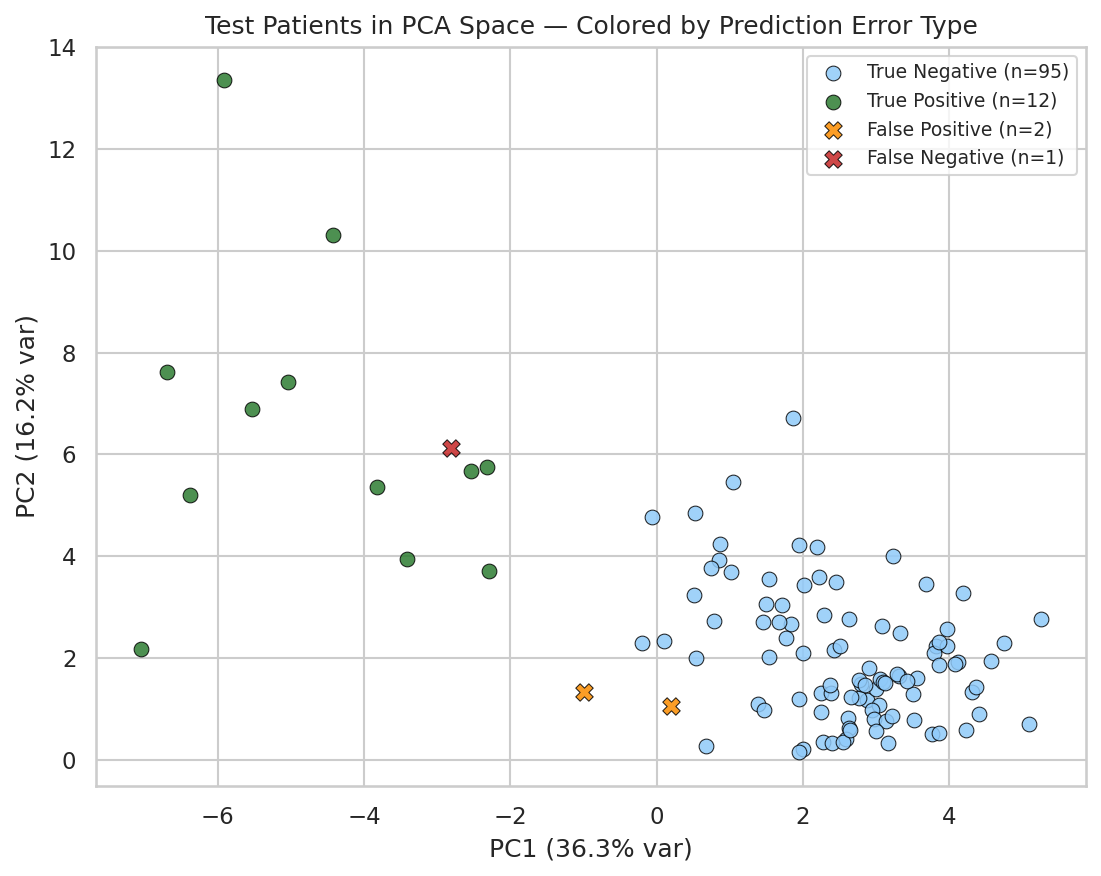

[OK] Saved: pca_patients_by_prediction_error.png

[INFO] UMAP not installed - skipping optional UMAP plots. PCA plots above already satisfy the dimensionality-reduction requirement.

Cell 17 complete.
  PCA: 52.6% variance explained by 2 components.


In [18]:
from sklearn.decomposition import PCA

# 0. Predictions and error types

y_test_arr = y_test.values
y_pred_arr = results_xgb["y_pred"]
y_proba_arr = results_xgb["y_proba"]

# 1. PCA fit on train, applied to test

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

test_pca = pca.transform(X_test_scaled)
explained_var = pca.explained_variance_ratio_

print(f"PCA fitted on training data ({X_train_scaled.shape[0]} patients, "
      f"{X_train_scaled.shape[1]} features).")
print(f"  PC1 explains {explained_var[0]*100:.1f}% of variance")
print(f"  PC2 explains {explained_var[1]*100:.1f}% of variance")
print(f"  Total (PC1+PC2): {explained_var.sum()*100:.1f}%")

# 2. Coloured by outcome

fig, ax = plt.subplots(figsize=(7, 6))
colors_outcome = {0: "#5B8DEF", 1: "#E84855"}
for outcome_val, label in [(0, "Survived"), (1, "Died")]:
    mask = y_test_arr == outcome_val
    ax.scatter(test_pca[mask, 0], test_pca[mask, 1],
               c=colors_outcome[outcome_val], label=label, alpha=0.7, s=50, edgecolors="white")
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
ax.set_title("Test Patients in PCA Space - Colored by Actual Outcome")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_patients_by_outcome.png", dpi=150)
plt.show()
print("[OK] Saved: pca_patients_by_outcome.png")

# 3. Coloured by predicted risk

fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(test_pca[:, 0], test_pca[:, 1], c=y_proba_arr,
                      cmap="RdYlBu_r", alpha=0.8, s=50, edgecolors="white", vmin=0, vmax=1)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Predicted mortality probability")
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
ax.set_title("Test Patients in PCA Space - Colored by Predicted Risk")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_patients_by_predicted_risk.png", dpi=150)
plt.show()
print("[OK] Saved: pca_patients_by_predicted_risk.png")

# 4. Coloured by error type

error_type = np.full(len(y_test_arr), "", dtype=object)
error_type[(y_test_arr == 1) & (y_pred_arr == 1)] = "True Positive"
error_type[(y_test_arr == 0) & (y_pred_arr == 0)] = "True Negative"
error_type[(y_test_arr == 0) & (y_pred_arr == 1)] = "False Positive"
error_type[(y_test_arr == 1) & (y_pred_arr == 0)] = "False Negative"

error_colors = {
    "True Positive":  "#2E7D32",
    "True Negative":  "#90CAF9",
    "False Positive": "#FB8C00",
    "False Negative": "#C62828",
}
error_markers = {
    "True Positive": "o", "True Negative": "o",
    "False Positive": "X", "False Negative": "X",
}

fig, ax = plt.subplots(figsize=(7.5, 6))
for label in ["True Negative", "True Positive", "False Positive", "False Negative"]:
    mask = error_type == label
    if mask.sum() == 0:
        continue
    ax.scatter(test_pca[mask, 0], test_pca[mask, 1],
               c=error_colors[label], marker=error_markers[label],
               label=f"{label} (n={mask.sum()})",
               alpha=0.85, s=70 if "False" in label else 50, edgecolors="black", linewidths=0.5)
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
ax.set_title("Test Patients in PCA Space - Colored by Prediction Error Type")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_patients_by_prediction_error.png", dpi=150)
plt.show()
print("[OK] Saved: pca_patients_by_prediction_error.png")

# 5. UMAP if it is installed

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("\n[INFO] UMAP not installed - skipping optional UMAP plots. "
          "PCA plots above already satisfy the dimensionality-reduction requirement.")

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    reducer.fit(X_train_scaled)
    test_umap = reducer.transform(X_test_scaled)

    fig, ax = plt.subplots(figsize=(7, 6))
    for outcome_val, label in [(0, "Survived"), (1, "Died")]:
        mask = y_test_arr == outcome_val
        ax.scatter(test_umap[mask, 0], test_umap[mask, 1],
                   c=colors_outcome[outcome_val], label=label, alpha=0.7, s=50, edgecolors="white")
    ax.set_title("Test Patients in UMAP Space - Colored by Actual Outcome")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "umap_patients_by_outcome.png", dpi=150)
    plt.show()
    print("[OK] Saved: umap_patients_by_outcome.png")

    fig, ax = plt.subplots(figsize=(7.5, 6))
    for label in ["True Negative", "True Positive", "False Positive", "False Negative"]:
        mask = error_type == label
        if mask.sum() == 0:
            continue
        ax.scatter(test_umap[mask, 0], test_umap[mask, 1],
                   c=error_colors[label], marker=error_markers[label],
                   label=f"{label} (n={mask.sum()})", alpha=0.85,
                   s=70 if "False" in label else 50, edgecolors="black", linewidths=0.5)
    ax.set_title("Test Patients in UMAP Space - Colored by Prediction Error Type")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "umap_patients_by_error_type.png", dpi=150)
    plt.show()
    print("[OK] Saved: umap_patients_by_error_type.png")

print("\n" + "=" * 50)
print("Cell 17 complete.")
print(f"  PCA: {explained_var.sum()*100:.1f}% variance explained by 2 components.")
print("=" * 50)

## Time windows
Same pipeline but only using measurements from the first 24, 48 or 72 hours after admission. This tests how early a prediction is possible. The patient splits stay the same as before.

In [19]:
import json

def safe_xgb_explainer(xgb_model, background):
    """
    TreeExplainer can't read base_score from xgboost 3 ('[5E-1]'), so we use the
    model-agnostic explainer on predict_proba. Values are approximate, not exact TreeSHAP.
    """
    f = lambda X: xgb_model.predict_proba(X)[:, 1]
    return shap.Explainer(f, background)


def filter_by_window(df_long: pd.DataFrame, max_hours) -> pd.DataFrame:
    """Only rows within max_hours of admission (None = everything)."""
    if max_hours is None:
        return df_long.copy()
    return df_long[df_long["hours_since_admission"] <= max_hours].copy()


def run_pipeline_for_window(window_name: str, max_hours,
                            train_patient_ids: np.ndarray, val_patient_ids: np.ndarray,
                            test_patient_ids: np.ndarray = None) -> dict:
    """
    Whole pipeline for one time window (aggregate, split, train, evaluate, SHAP).
    Uses the same patient splits as the full-stay models.
    """
    print(f"\n{'='*60}")
    print(f"RUNNING PIPELINE FOR WINDOW: {window_name}"
          f"{f' (<= {max_hours}h since admission)' if max_hours else ' (all measurements)'}")
    print(f"{'='*60}")

    # 1. filter rows by window and aggregate
    df_train_window = filter_by_window(df_train_raw, max_hours)
    df_test_window  = filter_by_window(df_test_raw, max_hours)

    agg_train = aggregate_patient_features(df_train_window, BIOMARKERS)
    agg_test  = aggregate_patient_features(df_test_window, BIOMARKERS)

    # 2. keep the same patient splits as before (patients with no data in the window drop out)
    agg_train_split = agg_train[agg_train["PATIENT_ID"].isin(train_patient_ids)].copy()
    agg_val_split   = agg_train[agg_train["PATIENT_ID"].isin(val_patient_ids)].copy()

    if test_patient_ids is not None:
        agg_test_split = agg_test[agg_test["PATIENT_ID"].isin(test_patient_ids)].copy()
    else:
        agg_test_split = agg_test.copy()

    n_train_dropped = len(train_patient_ids) - len(agg_train_split)
    n_val_dropped   = len(val_patient_ids) - len(agg_val_split)
    n_test_dropped  = (len(test_patient_ids) if test_patient_ids is not None else 110) - len(agg_test_split)

    print(f"  Patients with >=1 measurement in this window:")
    print(f"    Train: {len(agg_train_split)}/{len(train_patient_ids)} "
          f"({n_train_dropped} dropped, zero measurements)")
    print(f"    Val:   {len(agg_val_split)}/{len(val_patient_ids)} ({n_val_dropped} dropped)")
    print(f"    Test:  {len(agg_test_split)} ({n_test_dropped} dropped)")

    if len(agg_test_split) < 10 or agg_test_split["outcome"].sum() < 3:
        print(f"  [CAUTION] Very few test patients or deaths remain in this window. "
              f"Metrics below will be noisy - interpret with care.")

    # 3. imputer and scaler fit on this window's train data
    win_feature_cols = [c for c in agg_train_split.columns if c not in ["PATIENT_ID", "outcome"]]

    X_tr = agg_train_split[win_feature_cols]
    y_tr = agg_train_split["outcome"]
    X_va = agg_val_split[win_feature_cols]
    y_va = agg_val_split["outcome"]
    X_te = agg_test_split[win_feature_cols]
    y_te = agg_test_split["outcome"]
    ids_te = agg_test_split["PATIENT_ID"]

    win_imputer = SimpleImputer(strategy="median")
    win_imputer.fit(X_tr)
    X_tr_imp = pd.DataFrame(win_imputer.transform(X_tr), columns=win_feature_cols, index=X_tr.index)
    X_va_imp = pd.DataFrame(win_imputer.transform(X_va), columns=win_feature_cols, index=X_va.index)
    X_te_imp = pd.DataFrame(win_imputer.transform(X_te), columns=win_feature_cols, index=X_te.index)

    win_scaler = StandardScaler()
    win_scaler.fit(X_tr_imp)
    X_tr_scaled = pd.DataFrame(win_scaler.transform(X_tr_imp), columns=win_feature_cols, index=X_tr_imp.index)
    X_va_scaled = pd.DataFrame(win_scaler.transform(X_va_imp), columns=win_feature_cols, index=X_va_imp.index)
    X_te_scaled = pd.DataFrame(win_scaler.transform(X_te_imp), columns=win_feature_cols, index=X_te_imp.index)

    # 4. train the models
    n_pos_win = y_tr.sum()
    n_neg_win = len(y_tr) - n_pos_win
    win_scale_pos_weight = n_neg_win / n_pos_win if n_pos_win > 0 else 1.0

    win_model_logreg = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)
    win_model_logreg.fit(X_tr_scaled, y_tr)

    win_model_tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=RANDOM_STATE)
    win_model_tree.fit(X_tr_imp, y_tr)

    if XGBOOST_AVAILABLE:
        win_model_xgb = XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            scale_pos_weight=win_scale_pos_weight, random_state=RANDOM_STATE, eval_metric="logloss",
        )
    else:
        win_model_xgb = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE)
    win_model_xgb.fit(X_tr_imp, y_tr)

    print(f"  [OK] Trained 3 models on {len(X_tr)} patients "
          f"({n_pos_win} died, {n_neg_win} survived).")

    # 5. evaluate
    win_results = {}
    for model, X_eval, model_name in [
        (win_model_logreg, X_te_scaled, "Logistic Regression"),
        (win_model_tree,   X_te_imp,    "Decision Tree"),
        (win_model_xgb,    X_te_imp,    "XGBoost (main model)"),
    ]:
        win_results[model_name] = evaluate_classifier(model, X_eval, y_te, f"{model_name} [{window_name}]")

    # 6. SHAP
    win_masker = shap.maskers.Independent(X_tr_scaled, max_samples=len(X_tr_scaled))
    win_explainer_logreg = shap.LinearExplainer(win_model_logreg, win_masker)
    win_shap_logreg = get_shap_values_for_positive_class(win_explainer_logreg(X_te_scaled))

    win_explainer_tree = shap.TreeExplainer(win_model_tree)
    win_shap_tree = get_shap_values_for_positive_class(win_explainer_tree(X_te_imp))

    # xgboost: TreeExplainer breaks on xgboost 3 here, so use the model-agnostic one
    win_explainer_xgb = safe_xgb_explainer(win_model_xgb, X_tr_imp)
    win_shap_xgb = get_shap_values_for_positive_class(win_explainer_xgb(X_te_imp))

    print(f"  [OK] SHAP computed for all 3 models.")

    return {
        "window_name": window_name,
        "max_hours": max_hours,
        "feature_cols": win_feature_cols,
        "X_train_imp": X_tr_imp, "X_val_imp": X_va_imp, "X_test_imp": X_te_imp,
        "X_train_scaled": X_tr_scaled, "X_val_scaled": X_va_scaled, "X_test_scaled": X_te_scaled,
        "y_train": y_tr, "y_val": y_va, "y_test": y_te, "ids_test": ids_te,
        "model_logreg": win_model_logreg, "model_tree": win_model_tree, "model_xgb": win_model_xgb,
        "results_logreg": win_results["Logistic Regression"],
        "results_tree": win_results["Decision Tree"],
        "results_xgb": win_results["XGBoost (main model)"],
        "shap_logreg": win_shap_logreg, "shap_tree": win_shap_tree, "shap_xgb": win_shap_xgb,
        "explainer_xgb": win_explainer_xgb,
        "n_train": len(X_tr), "n_val": len(X_va), "n_test": len(X_te),
        "n_test_dropped": n_test_dropped,
    }


print("[OK] Pipeline function 'run_pipeline_for_window' defined.")
print("  Ready to run for: full, 24h, 48h, 72h windows.")

[OK] Pipeline function 'run_pipeline_for_window' defined.
  Ready to run for: full, 24h, 48h, 72h windows.


Run all windows and compare the results.


RUNNING PIPELINE FOR WINDOW: 24h (<= 24h since admission)
  Patients with >=1 measurement in this window:
    Train: 269/300 (31 dropped, zero measurements)
    Val:   63/75 (12 dropped)
    Test:  98 (12 dropped)
  [OK] Trained 3 models on 269 patients (124 died, 145 survived).

--- Logistic Regression [24h] ---
  ROC-AUC : 0.887  (95% CI: [0.683, 0.993])
  PR-AUC  : 0.789  (95% CI: [0.557, 0.951])
  Accuracy: 0.898   F1: 0.667   Recall: 0.833   Precision: 0.556   Specificity: 0.907
  Confusion matrix [TN=78, FP=8, FN=2, TP=10]

--- Decision Tree [24h] ---
  ROC-AUC : 0.953  (95% CI: [0.909, 0.987])
  PR-AUC  : 0.704  (95% CI: [0.455, 0.887])
  Accuracy: 0.918   F1: 0.692   Recall: 0.750   Precision: 0.643   Specificity: 0.942
  Confusion matrix [TN=81, FP=5, FN=3, TP=9]

--- XGBoost (main model) [24h] ---
  ROC-AUC : 0.943  (95% CI: [0.878, 0.992])
  PR-AUC  : 0.814  (95% CI: [0.605, 0.963])
  Accuracy: 0.888   F1: 0.621   Recall: 0.750   Precision: 0.529   Specificity: 0.907
  Conf

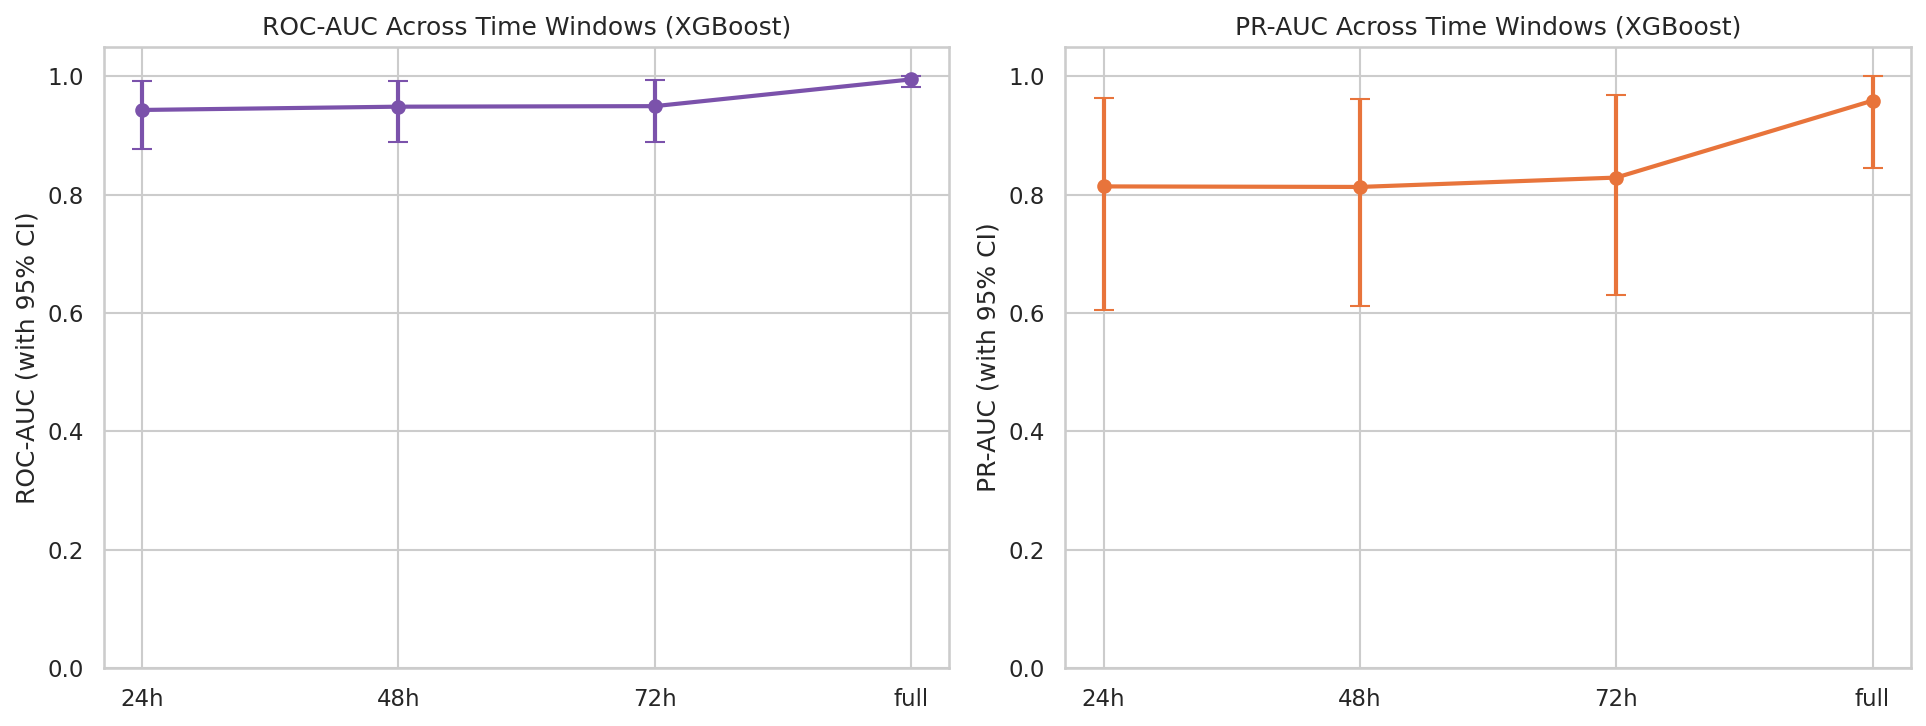

[OK] Saved: performance_across_windows.png

Cell 19 complete.
  window_results dict available with keys: full, 24h, 48h, 72h


In [20]:
train_ids = ids_train.values
val_ids = ids_val.values

# full stay is already done, just put it in the same format as the other windows
window_results = {"full": {
    "window_name": "full", "max_hours": None, "feature_cols": feature_cols,
    "X_train_imp": X_train_imp, "X_val_imp": X_val_imp, "X_test_imp": X_test_imp,
    "X_train_scaled": X_train_scaled, "X_val_scaled": X_val_scaled, "X_test_scaled": X_test_scaled,
    "y_train": y_train, "y_val": y_val, "y_test": y_test, "ids_test": ids_test,
    "model_logreg": model_logreg, "model_tree": model_tree, "model_xgb": model_xgb,
    "results_logreg": results_logreg, "results_tree": results_tree, "results_xgb": results_xgb,
    "shap_logreg": shap_vals_logreg, "shap_tree": shap_vals_tree, "shap_xgb": shap_vals_xgb,
    "explainer_xgb": explainer_xgb,
    "n_train": len(X_train_imp), "n_val": len(X_val_imp), "n_test": len(X_test_imp),
    "n_test_dropped": 0,
}}

for window_name, max_hours in [("24h", 24), ("48h", 48), ("72h", 72)]:
    window_results[window_name] = run_pipeline_for_window(window_name, max_hours, train_ids, val_ids)

print("\n[OK] All 4 windows processed: full, 24h, 48h, 72h")

# 2. Comparison table

comparison_rows = []
for window_name, wr in window_results.items():
    for model_key, model_label in [
        ("results_logreg", "Logistic Regression"),
        ("results_tree", "Decision Tree"),
        ("results_xgb", "XGBoost (main model)"),
    ]:
        r = wr[model_key]
        comparison_rows.append({
            "window": window_name,
            "model": model_label,
            "n_test_patients": wr["n_test"],
            "roc_auc": r["roc_auc"], "roc_auc_ci_low": r["roc_auc_ci_low"], "roc_auc_ci_high": r["roc_auc_ci_high"],
            "pr_auc": r["pr_auc"], "pr_auc_ci_low": r["pr_auc_ci_low"], "pr_auc_ci_high": r["pr_auc_ci_high"],
            "accuracy": r["accuracy"], "f1": r["f1"], "recall": r["recall"], "precision": r["precision"],
        })

comparison_df = pd.DataFrame(comparison_rows)

# one csv per window
for window_name in ["full", "24h", "48h", "72h"]:
    subset = comparison_df[comparison_df["window"] == window_name].drop(columns=["window"])
    subset.to_csv(OUTPUT_DIR / f"model_performance_{window_name}.csv", index=False)
print("[OK] Saved: model_performance_full.csv, model_performance_24h.csv, "
      "model_performance_48h.csv, model_performance_72h.csv")

# and one combined
comparison_df.to_csv(OUTPUT_DIR / "model_performance_all_windows.csv", index=False)
print("[OK] Saved: model_performance_all_windows.csv (combined)")

print("\nXGBoost (main model) performance across windows:")
xgb_comparison = comparison_df[comparison_df["model"] == "XGBoost (main model)"].set_index("window")
print(xgb_comparison[["n_test_patients", "roc_auc", "roc_auc_ci_low", "roc_auc_ci_high",
                       "pr_auc", "f1", "recall"]].round(3).to_string())

# 3. Plot AUCs per window

window_order = ["24h", "48h", "72h", "full"]
xgb_comparison_ordered = xgb_comparison.reindex(window_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(
    window_order, xgb_comparison_ordered["roc_auc"],
    yerr=[xgb_comparison_ordered["roc_auc"] - xgb_comparison_ordered["roc_auc_ci_low"],
          xgb_comparison_ordered["roc_auc_ci_high"] - xgb_comparison_ordered["roc_auc"]],
    fmt="o-", capsize=5, linewidth=2, color="#7B52AB",
)
ax.set_ylabel("ROC-AUC (with 95% CI)")
ax.set_title("ROC-AUC Across Time Windows (XGBoost)")
ax.set_ylim(0, 1.05)

ax = axes[1]
ax.errorbar(
    window_order, xgb_comparison_ordered["pr_auc"],
    yerr=[xgb_comparison_ordered["pr_auc"] - xgb_comparison_ordered["pr_auc_ci_low"],
          xgb_comparison_ordered["pr_auc_ci_high"] - xgb_comparison_ordered["pr_auc"]],
    fmt="o-", capsize=5, linewidth=2, color="#E8743B",
)
ax.set_ylabel("PR-AUC (with 95% CI)")
ax.set_title("PR-AUC Across Time Windows (XGBoost)")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_across_windows.png", dpi=150)
plt.show()
print("[OK] Saved: performance_across_windows.png")

print("\n" + "=" * 50)
print("Cell 19 complete.")
print("  window_results dict available with keys: full, 24h, 48h, 72h")
print("=" * 50)

SHAP plots and biomarker importance for every window, to see if the most important biomarker changes over time.

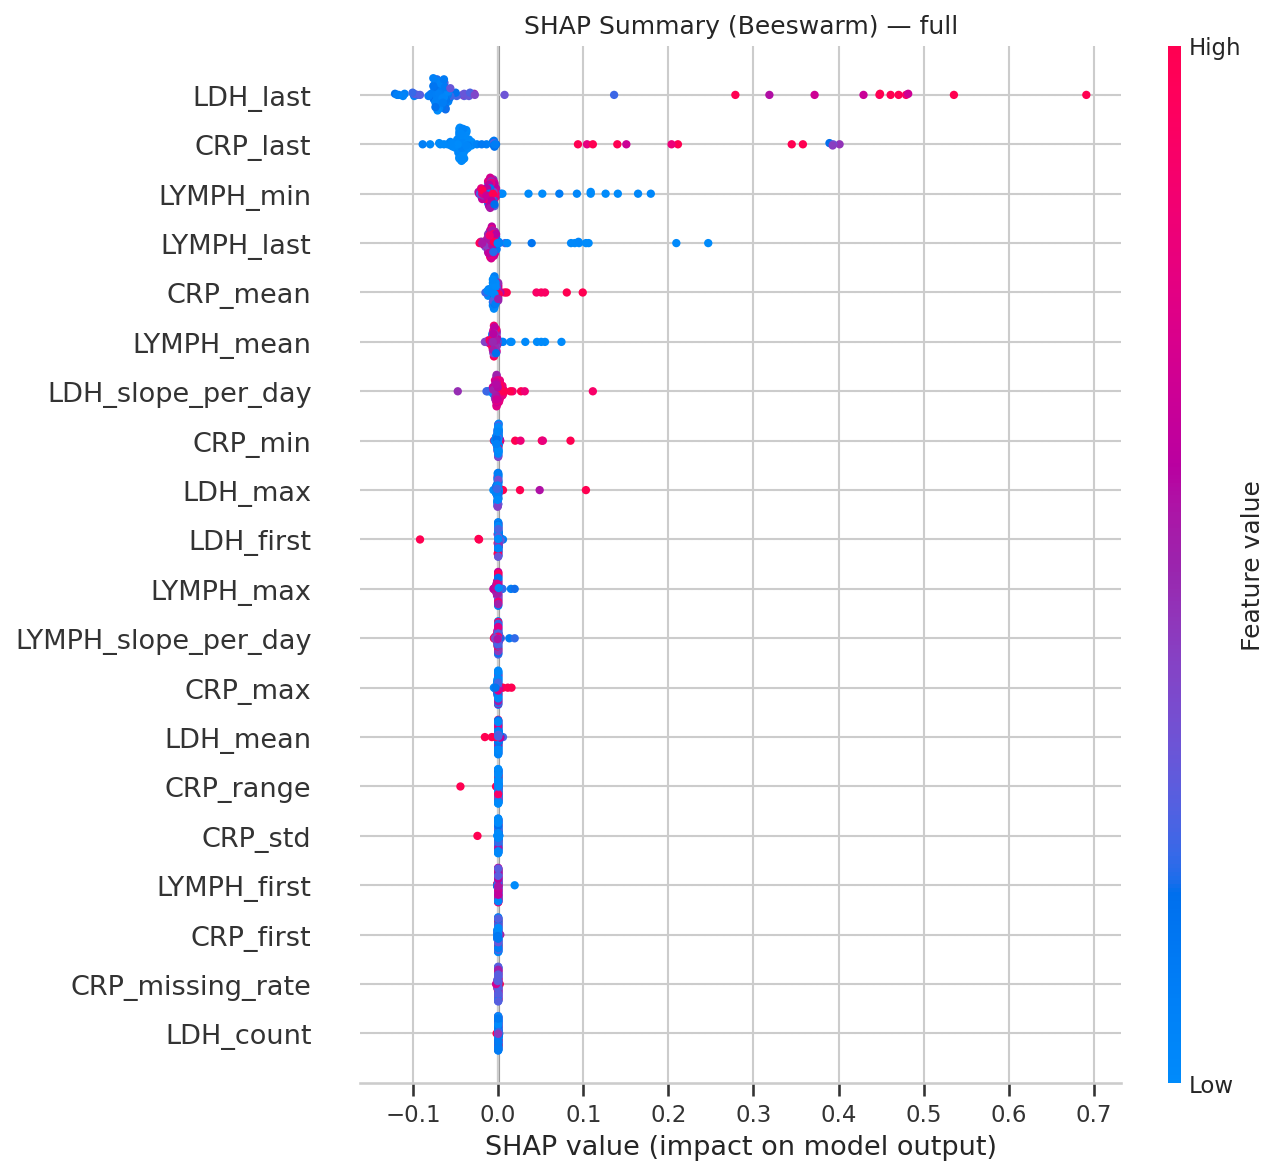

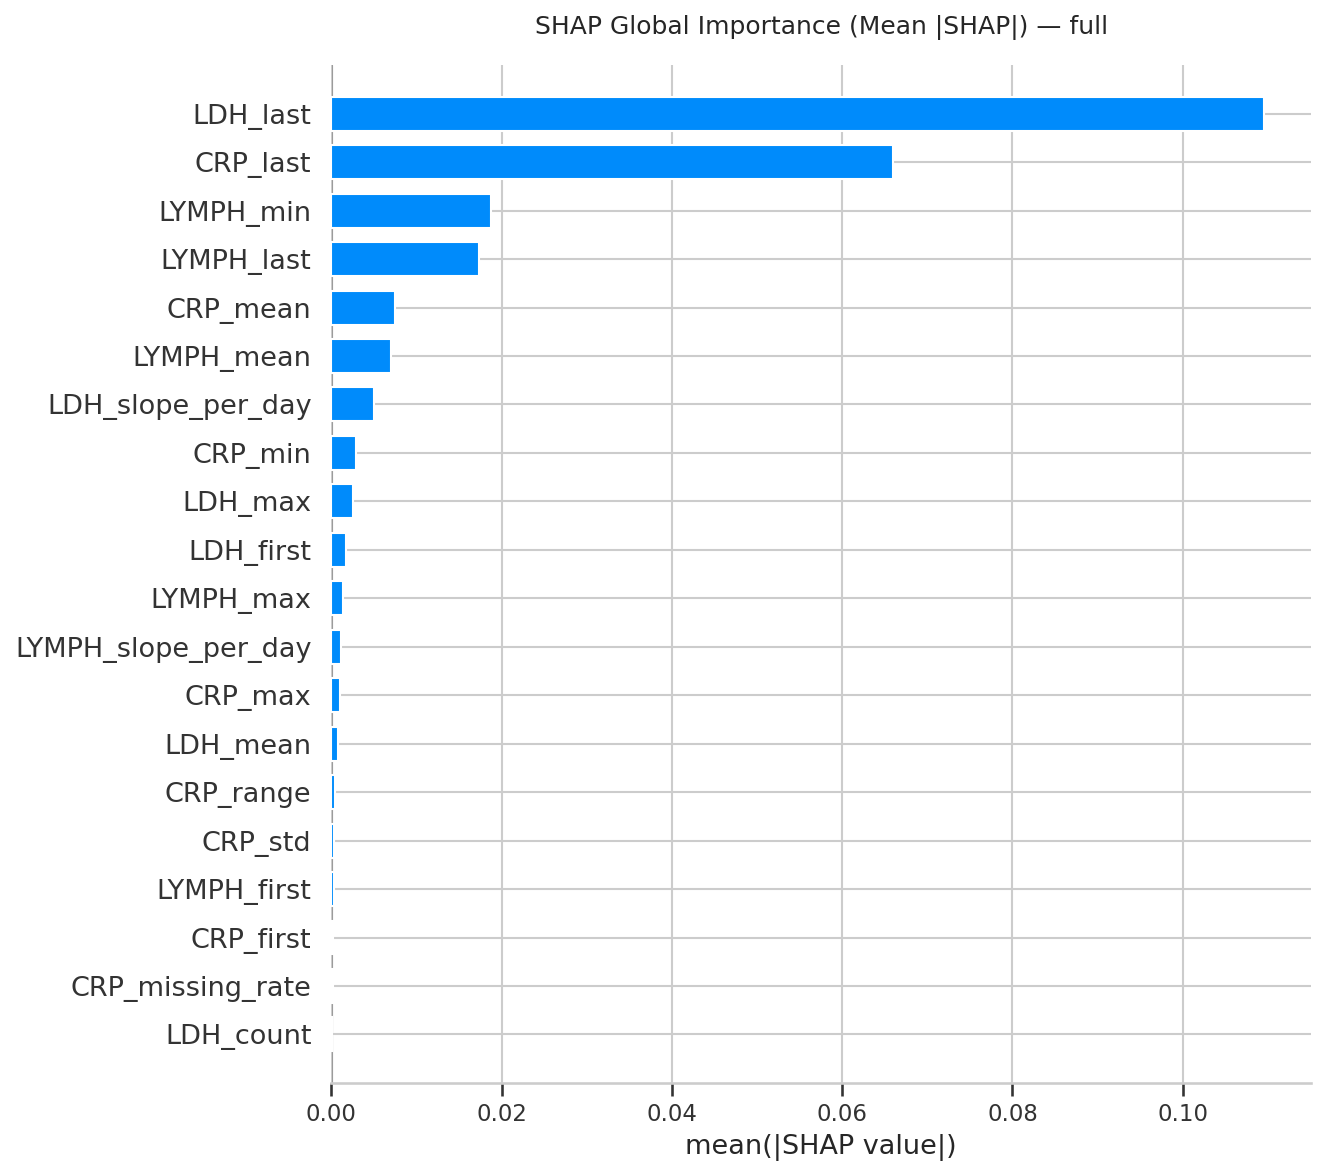


[full] Grouped biomarker SHAP importance:
biomarker  share_of_total
      LDH           0.490
      CRP           0.322
    LYMPH           0.188


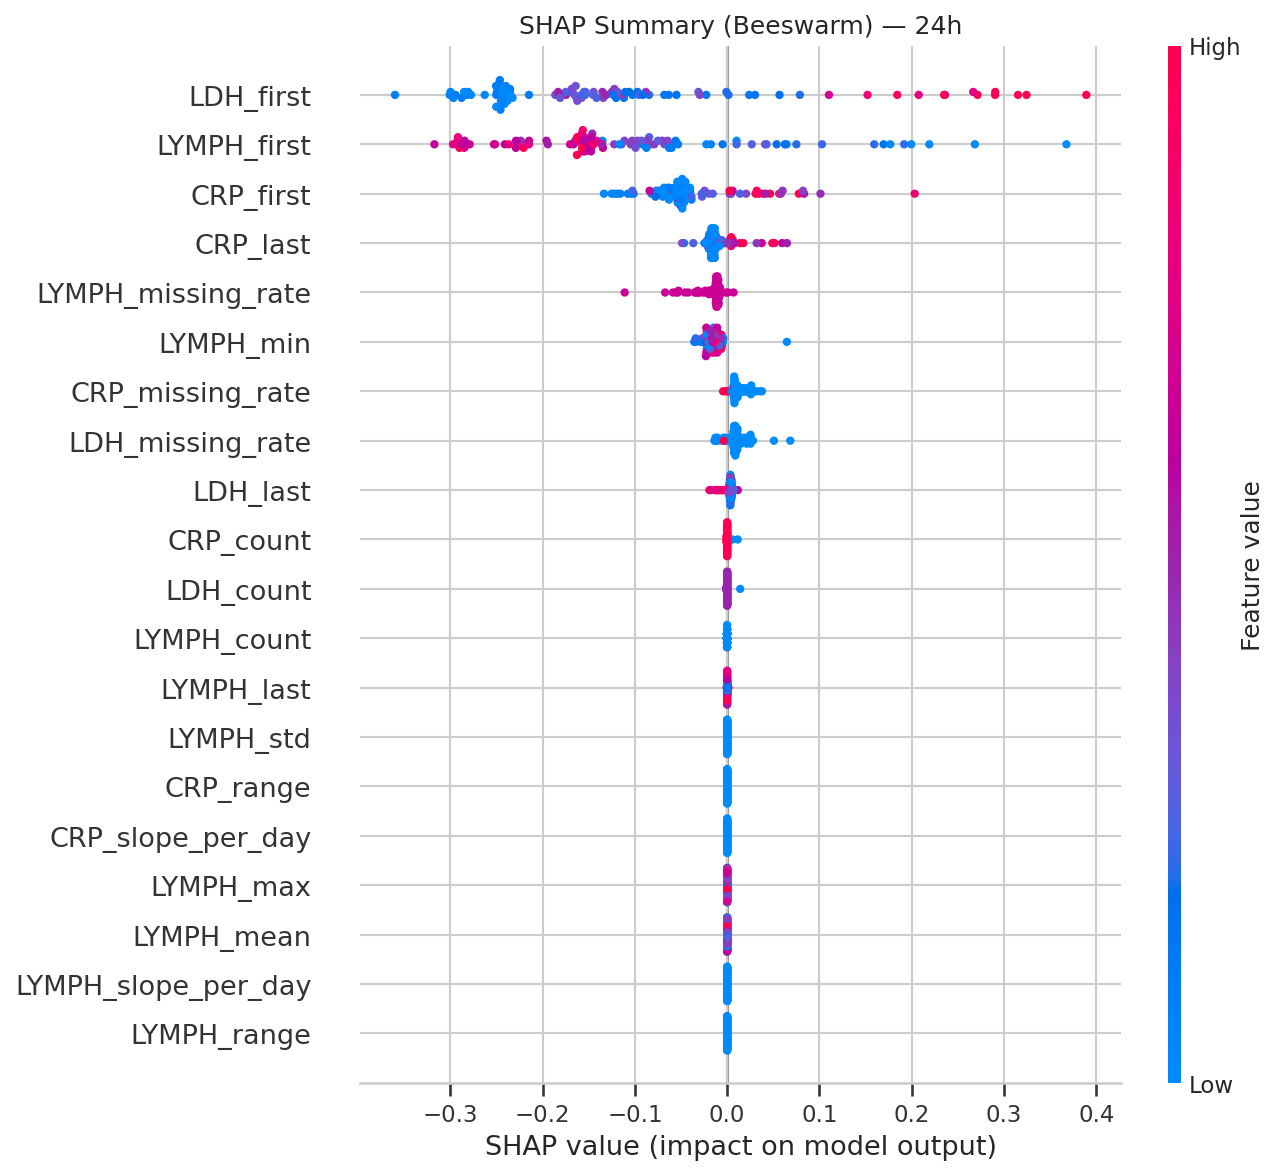

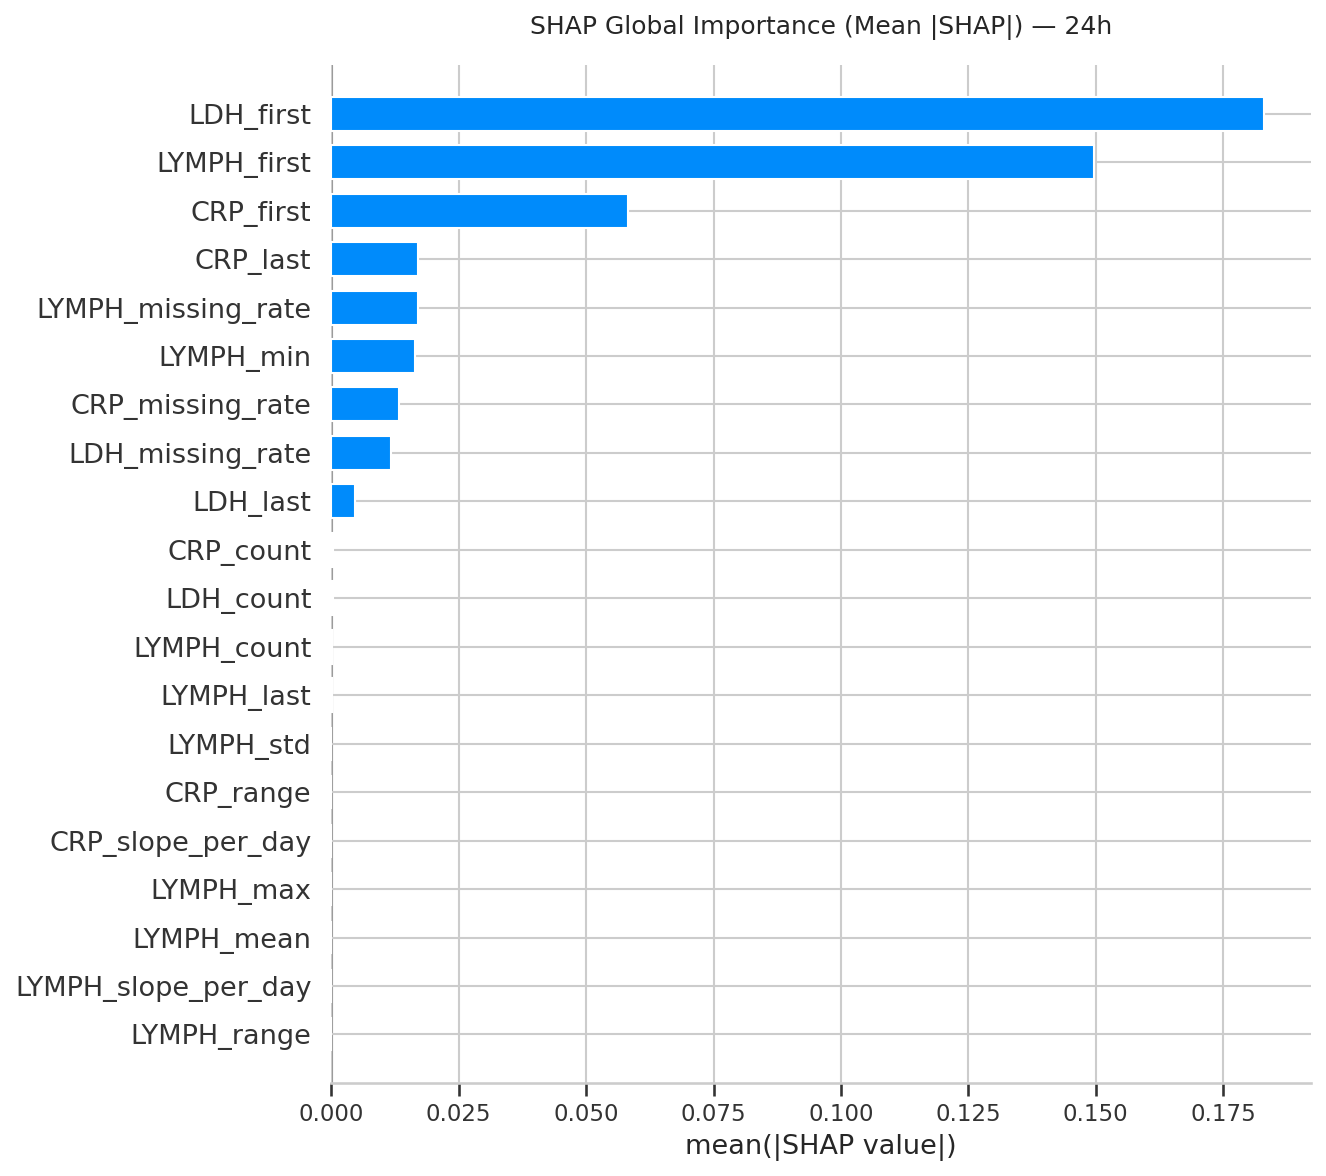


[24h] Grouped biomarker SHAP importance:
biomarker  share_of_total
      LDH           0.423
    LYMPH           0.388
      CRP           0.188


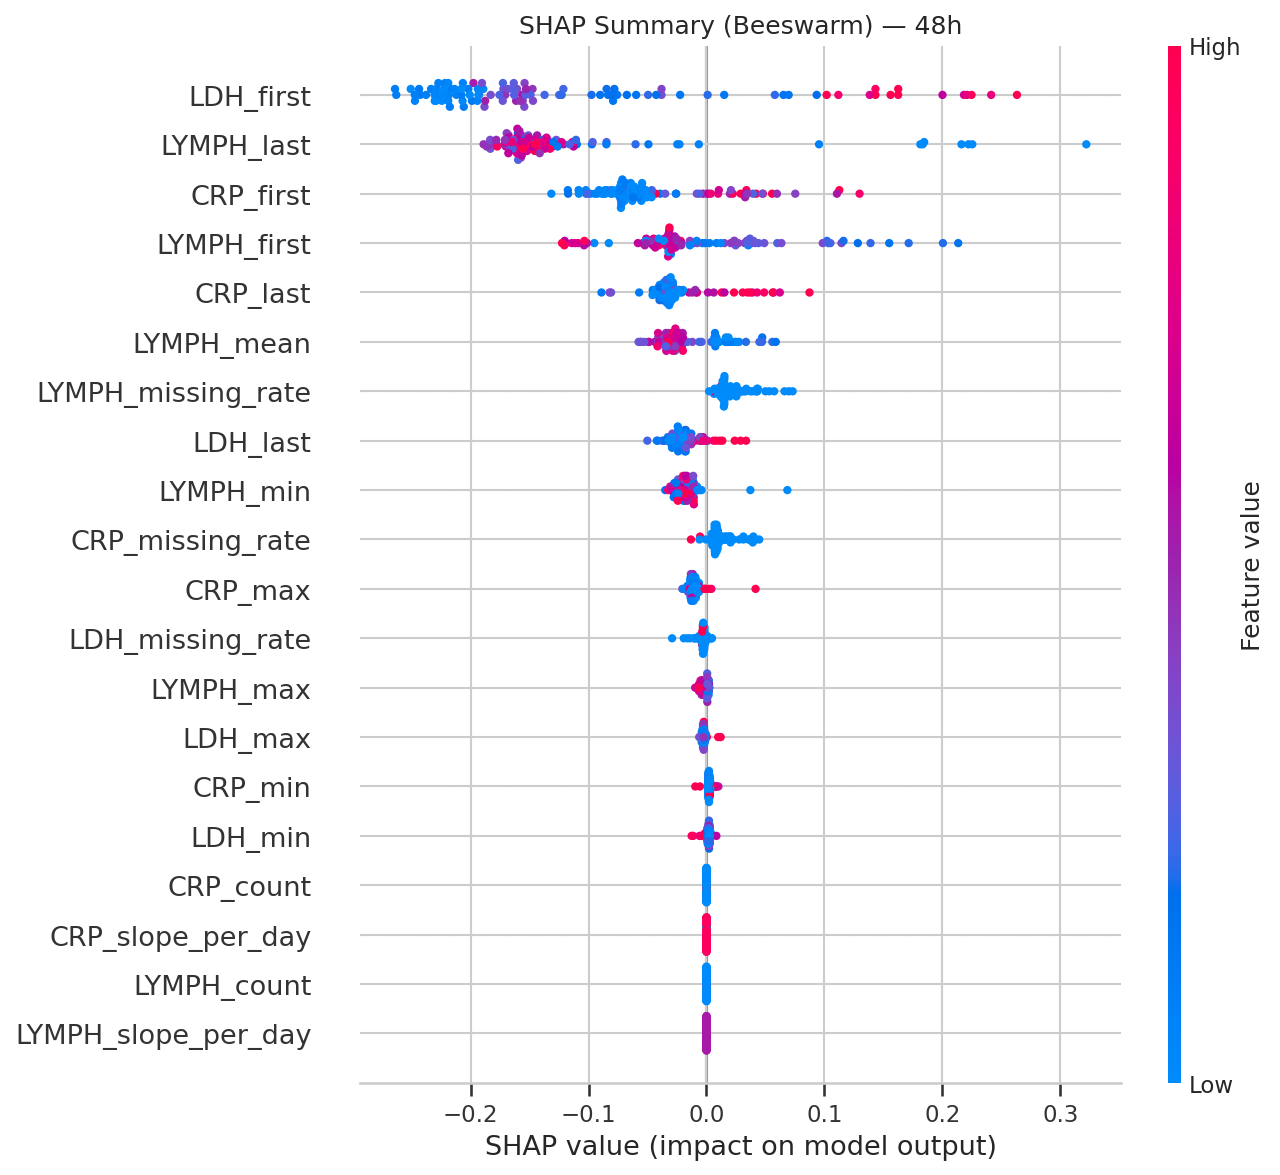

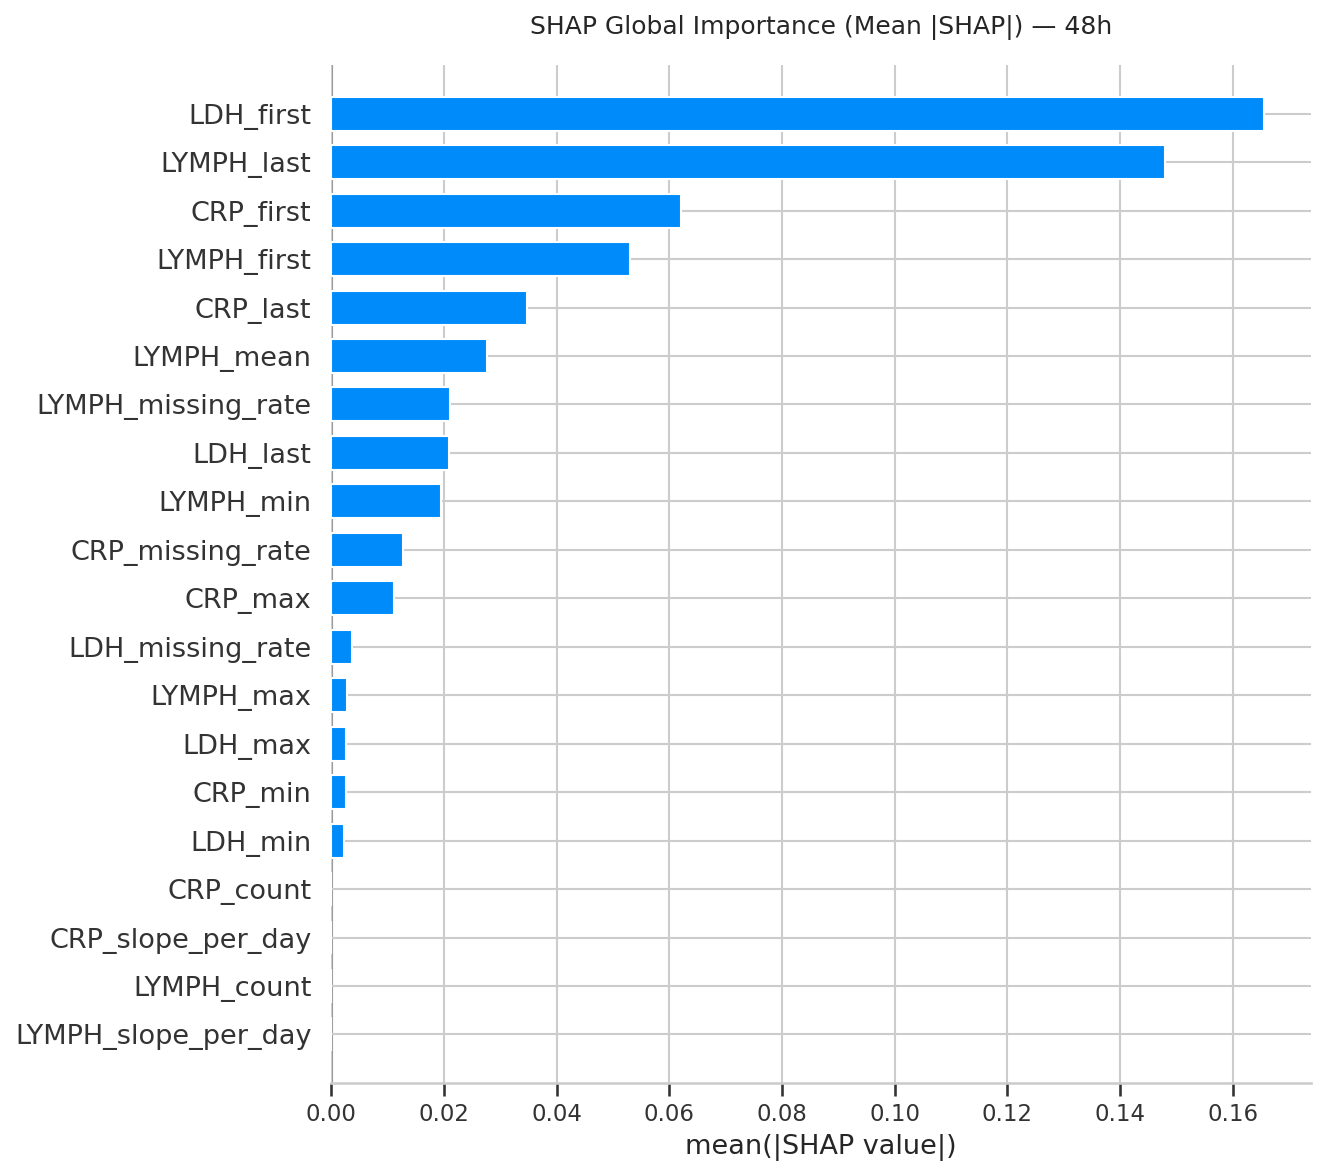


[48h] Grouped biomarker SHAP importance:
biomarker  share_of_total
    LYMPH           0.461
      LDH           0.330
      CRP           0.209


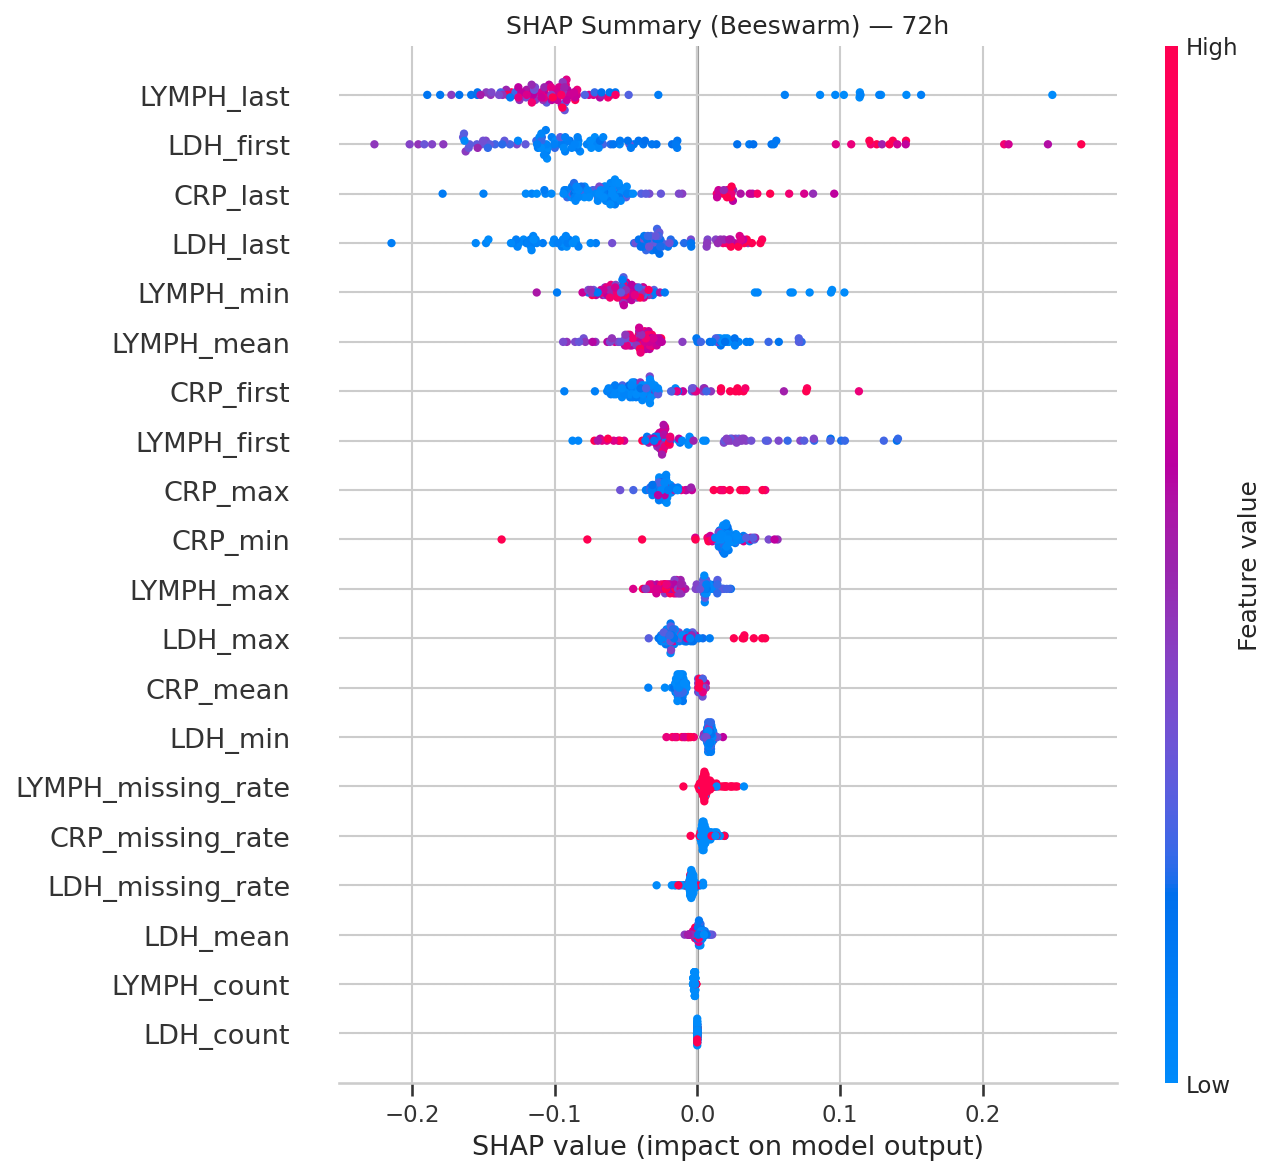

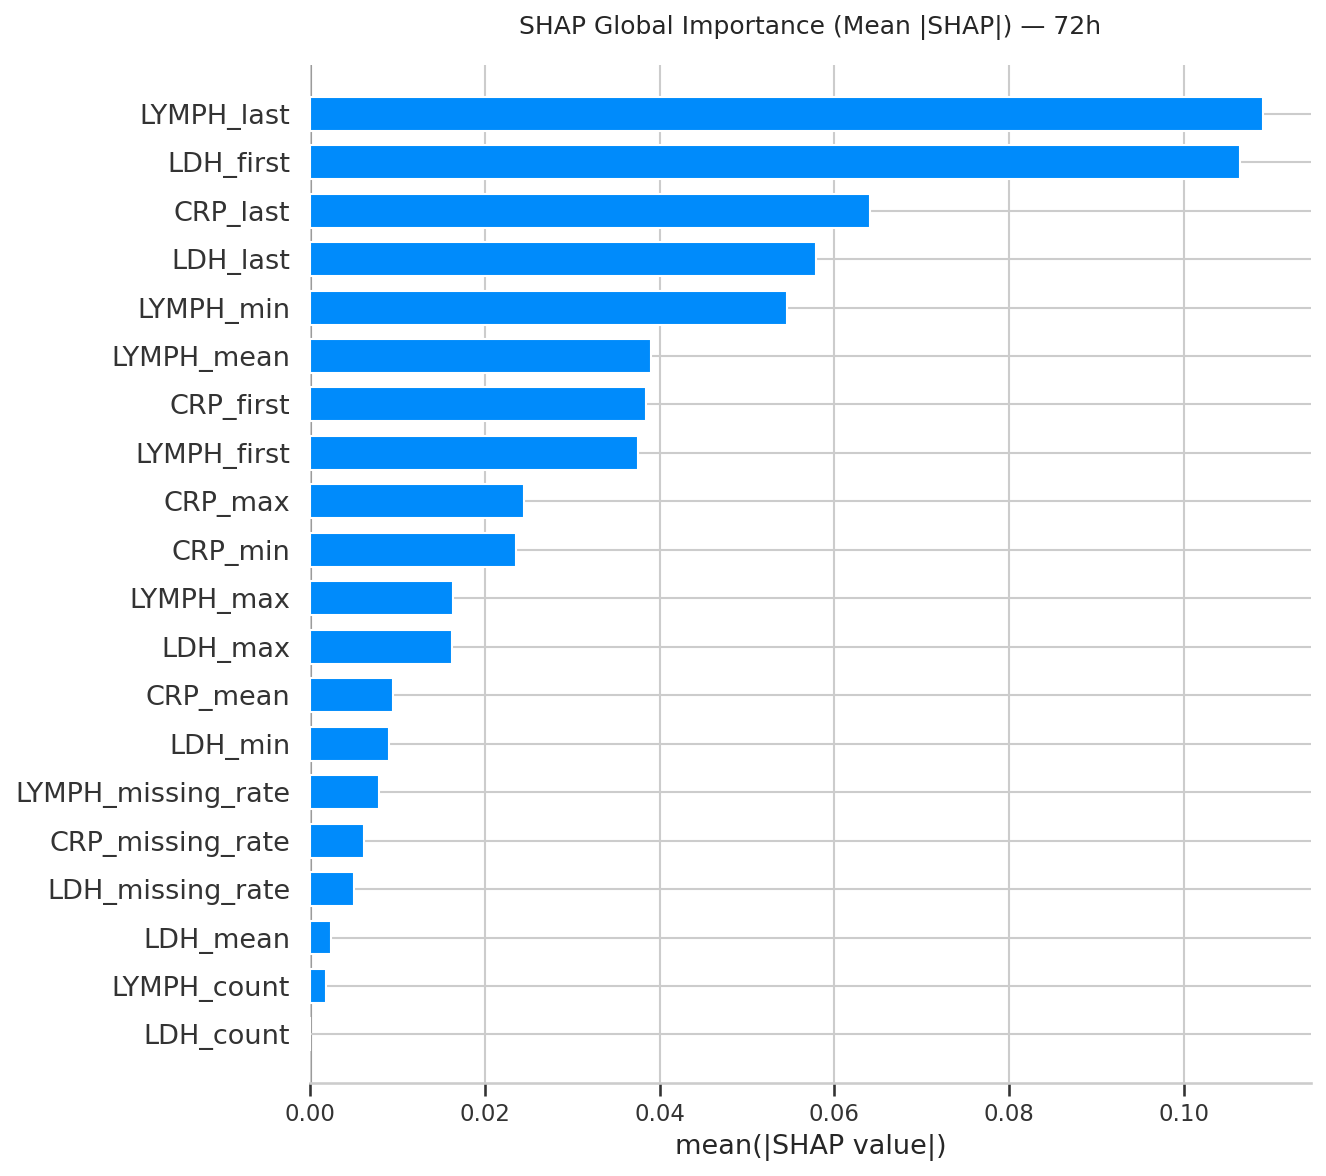


[72h] Grouped biomarker SHAP importance:
biomarker  share_of_total
    LYMPH           0.423
      LDH           0.313
      CRP           0.264

[OK] Saved: grouped_biomarker_shap_importance_all_windows.csv
[OK] Saved per-window: shap_importance_{window}.csv, shap_summary_beeswarm_{window}.png, shap_global_bar_{window}.png


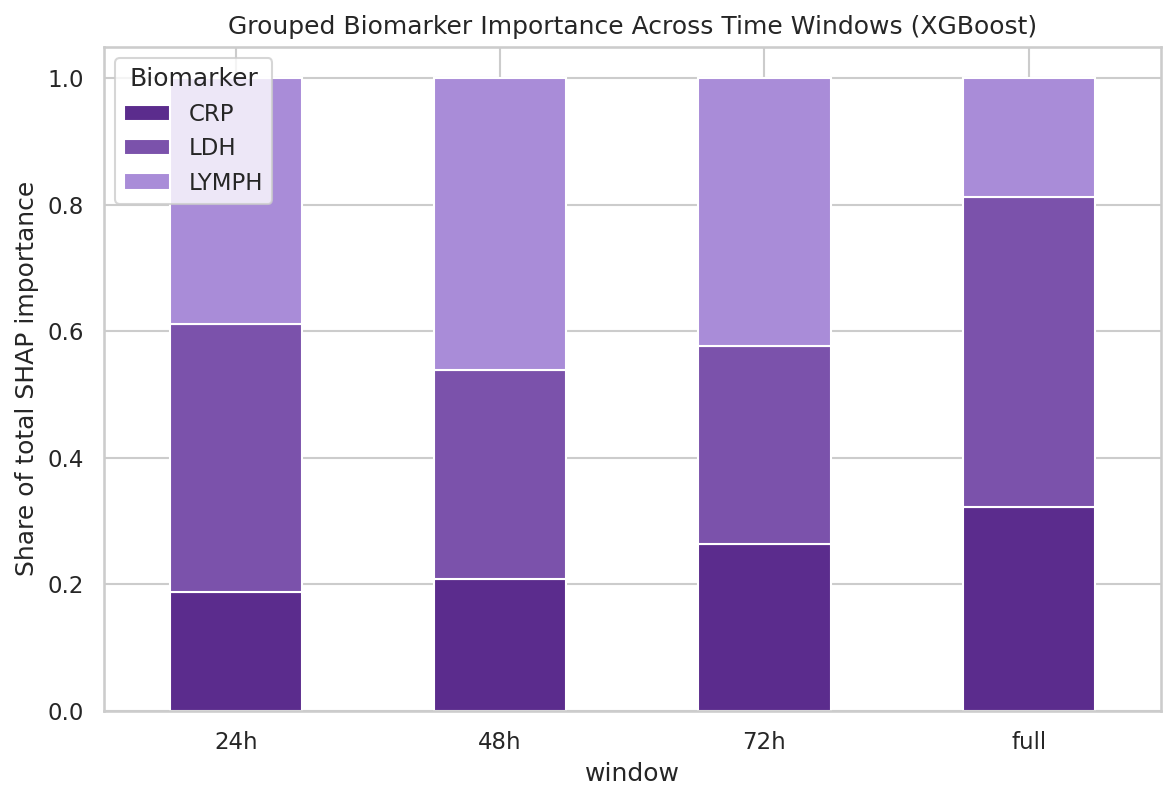

[OK] Saved: grouped_biomarker_shap_across_windows.png

[NOTE]
Top biomarker by window:
window
24h       LDH
48h     LYMPH
72h     LYMPH
full      LDH

The dominant biomarker is NOT consistent across windows: 24h->LDH, 48h->LYMPH,
72h->LYMPH, full->LDH. LYMPH takes over at 48h and 72h (LYMPH: 46.1% at 48h, 42.3% at
72h, vs LDH 33.0% / 31.3%). Only 13-14 deaths per window, so this is a careful
observation, not a strong claim.

Cell 20 complete.


In [21]:
grouped_importance_by_window = {}

for window_name, wr in window_results.items():
    win_feature_cols = wr["feature_cols"]
    win_shap_xgb = wr["shap_xgb"]
    win_X_test = wr["X_test_imp"]

    # SHAP plots
    save_global_shap_plots(win_shap_xgb, win_X_test, window_name, win_feature_cols)

    # mean |SHAP| table
    mean_abs_shap_win = pd.DataFrame({
        "feature": win_feature_cols,
        "mean_abs_shap": np.abs(win_shap_xgb).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    mean_abs_shap_win.to_csv(OUTPUT_DIR / f"shap_importance_{window_name}.csv", index=False)

    # per biomarker
    mean_abs_shap_win["biomarker"] = mean_abs_shap_win["feature"].map(
        lambda f: get_biomarker_for_feature(f, BIOMARKERS)
    )
    grouped_win = (
        mean_abs_shap_win.groupby("biomarker")["mean_abs_shap"]
        .sum().sort_values(ascending=False).reset_index()
    )
    grouped_win["share_of_total"] = grouped_win["mean_abs_shap"] / grouped_win["mean_abs_shap"].sum()
    grouped_win["window"] = window_name

    grouped_importance_by_window[window_name] = grouped_win

    print(f"\n[{window_name}] Grouped biomarker SHAP importance:")
    print(grouped_win[["biomarker", "share_of_total"]].round(3).to_string(index=False))

# save combined csv
grouped_all_windows = pd.concat(grouped_importance_by_window.values(), ignore_index=True)
grouped_all_windows.to_csv(OUTPUT_DIR / "grouped_biomarker_shap_importance_all_windows.csv", index=False)
print(f"\n[OK] Saved: grouped_biomarker_shap_importance_all_windows.csv")
print("[OK] Saved per-window: shap_importance_{window}.csv, "
      "shap_summary_beeswarm_{window}.png, shap_global_bar_{window}.png")

# 2. Plot the shift

pivot_grouped = grouped_all_windows.pivot(index="window", columns="biomarker", values="share_of_total")
pivot_grouped = pivot_grouped.reindex(["24h", "48h", "72h", "full"])

fig, ax = plt.subplots(figsize=(8, 5.5))
pivot_grouped.plot(kind="bar", stacked=True, ax=ax,
                    color=["#5B2C8D", "#7B52AB", "#A98CD8"])
ax.set_ylabel("Share of total SHAP importance")
ax.set_title("Grouped Biomarker Importance Across Time Windows (XGBoost)")
ax.set_xticklabels(pivot_grouped.index, rotation=0)
ax.legend(title="Biomarker")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grouped_biomarker_shap_across_windows.png", dpi=150)
plt.show()
print("[OK] Saved: grouped_biomarker_shap_across_windows.png")

# 3. Print whether the ranking changes

print("\n[NOTE]")
top_biomarker_per_window = pivot_grouped.idxmax(axis=1)
print("Top biomarker by window:")
print(top_biomarker_per_window.to_string())

if top_biomarker_per_window.nunique() > 1:
    print()
    print(textwrap.fill(
        f"The dominant biomarker is NOT consistent across windows: "
        f"{', '.join(f'{w}->{b}' for w, b in top_biomarker_per_window.items())}. "
        f"LYMPH takes over at 48h and 72h "
        f"(LYMPH: {pivot_grouped.loc['48h','LYMPH']*100:.1f}% at 48h, "
        f"{pivot_grouped.loc['72h','LYMPH']*100:.1f}% at 72h, vs LDH "
        f"{pivot_grouped.loc['48h','LDH']*100:.1f}% / {pivot_grouped.loc['72h','LDH']*100:.1f}%). "
        f"Only 13-14 deaths per window, so this is a careful observation, not a strong claim.",
        width=88
    ))
else:
    ldh_share_full = pivot_grouped.loc["full", "LDH"]
    ldh_share_24h = pivot_grouped.loc["24h", "LDH"]
    print(textwrap.fill(
        f"The same biomarker ({top_biomarker_per_window.iloc[0]}) ranks highest across "
        f"all windows, suggesting the relative importance of biomarkers is fairly stable "
        f"regardless of how much of the hospitalization has been observed.",
        width=88
    ))

print("\n" + "=" * 50)
print("Cell 20 complete.")
print("=" * 50)

## LSTM
Instead of summary features, an LSTM gets each patient's raw sequence (padded to 24 steps). We expected it to do worse, since most patients only have a few measurements per biomarker, and compare it with XGBoost on the same test set.

[OK] PyTorch 2.6.0+cu124 loaded.

Sequence tensors built:
  Train: (300, 24, 4), deaths: 139
  Val:   (75, 24, 4), deaths: 35
  Test:  (110, 24, 4), deaths: 13

Training LSTM (40 epochs, early-stopping on validation ROC-AUC)...
  Epoch 10/40: val ROC-AUC = 0.965 (best: 0.990)
  Epoch 20/40: val ROC-AUC = 0.968 (best: 0.990)
  Epoch 30/40: val ROC-AUC = 0.969 (best: 0.990)
  Epoch 40/40: val ROC-AUC = 0.971 (best: 0.990)
[OK] LSTM training complete. Best validation ROC-AUC: 0.990

--- LSTM (raw sequence input) - Test Set ---
  ROC-AUC : 0.969
  PR-AUC  : 0.932
  F1: 0.870   Recall: 0.769   Precision: 1.000

[OK] Saved: lstm_vs_xgboost_comparison.csv
                      model  roc_auc  pr_auc    f1  recall
 XGBoost (summary features)    0.994   0.959 0.889   0.923
LSTM (raw padded sequences)    0.969   0.932 0.870   0.769


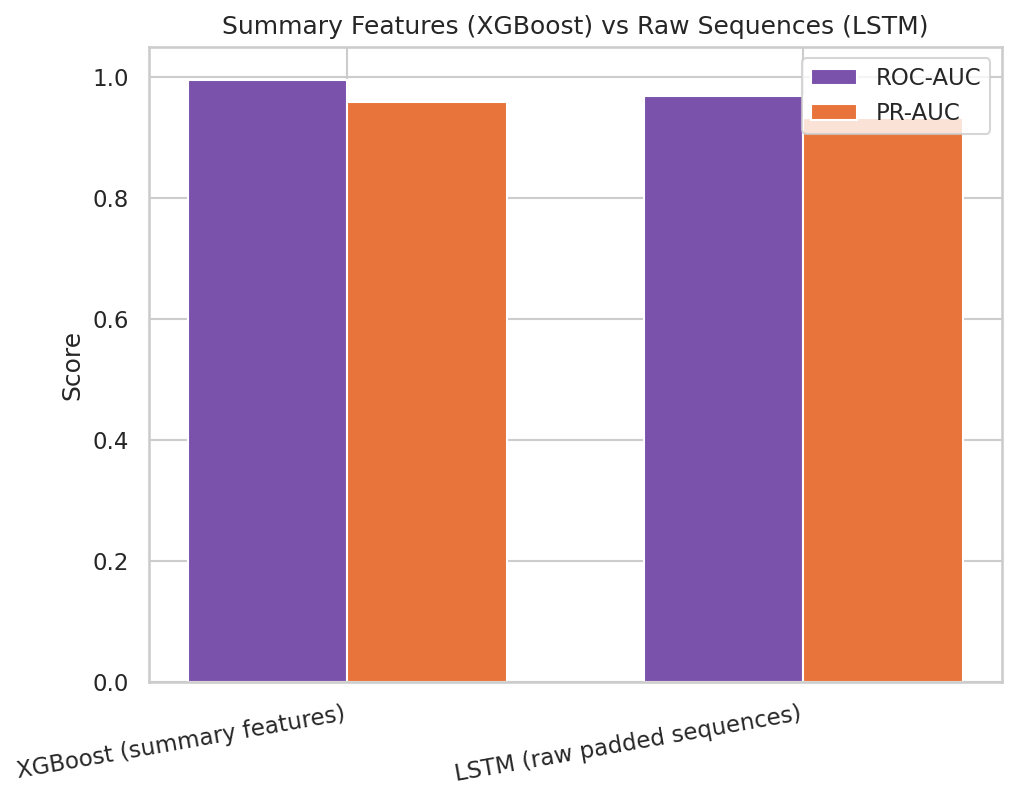

[OK] Saved: lstm_vs_xgboost_comparison.png

[CONCLUSION]
The LSTM (0.969) and XGBoost on summary features (0.994) are close, both near the
ceiling. We expected the LSTM to do worse because the data is so sparse. Our guess is
that it mostly uses the last few measurements, which is similar to the 'last value'
features. So accuracy alone doesn't pick a winner, the difference is in what kind of
explanation each one allows.

Cell 21 complete.


In [22]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
    print(f"[OK] PyTorch {torch.__version__} loaded.")
except ImportError:
    TORCH_AVAILABLE = False
    print("[WARN] PyTorch not available in this environment - skipping the LSTM "
          "comparison. This cell requires PyTorch (pre-installed on Google Colab "
          "by default; if missing, run: !pip install torch --quiet)")

if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

    # 1. Padded sequences per patient

    MAX_SEQ_LEN = 24  # longest patient has 24 rows

    # same patient splits as the tabular models
    train_ids = ids_train.values
    val_ids = ids_val.values

    def build_sequence_tensor(df_long: pd.DataFrame, patient_ids: np.ndarray,
                               biomarkers: list, max_len: int = MAX_SEQ_LEN):
        """
        X: (patients, max_len, biomarkers + time), NaN -> 0
        mask: True where there is a real measurement
        y: outcome
        """
        n_channels = len(biomarkers) + 1
        X = np.zeros((len(patient_ids), max_len, n_channels), dtype=np.float32)
        mask = np.zeros((len(patient_ids), max_len), dtype=bool)
        y = np.zeros(len(patient_ids), dtype=np.float32)

        max_hours_overall = df_long["hours_since_admission"].max()

        for i, pid in enumerate(patient_ids):
            patient_rows_all = df_long[df_long["PATIENT_ID"] == pid].sort_values("hours_since_admission")

            if len(patient_rows_all) == 0:
                # patient not in this dataframe
                y[i] = np.nan
                continue

            # take the outcome before filtering, so patients with no measurements still have a label
            y[i] = patient_rows_all["outcome"].iloc[0]

            has_any = patient_rows_all[biomarkers].notna().any(axis=1)
            patient_rows = patient_rows_all[has_any].head(max_len)

            n_steps = len(patient_rows)
            if n_steps == 0:
                # no measurements, leave as zeros
                continue

            for j, marker in enumerate(biomarkers):
                vals = patient_rows[marker].to_numpy(dtype=float)
                vals = np.nan_to_num(vals, nan=0.0)
                X[i, :n_steps, j] = vals

            hours_norm = patient_rows["hours_since_admission"].to_numpy(dtype=float) / max_hours_overall
            X[i, :n_steps, -1] = hours_norm
            mask[i, :n_steps] = True
            y[i] = patient_rows["outcome"].iloc[0]

        return X, mask, y


    X_seq_train, mask_train, y_seq_train = build_sequence_tensor(df_train_raw, train_ids, BIOMARKERS)
    X_seq_val,   mask_val,   y_seq_val   = build_sequence_tensor(df_train_raw, val_ids, BIOMARKERS)
    X_seq_test,  mask_test,  y_seq_test  = build_sequence_tensor(df_test_raw, ids_test.values, BIOMARKERS)

    print(f"\nSequence tensors built:")
    print(f"  Train: {X_seq_train.shape}, deaths: {int(y_seq_train.sum())}")
    print(f"  Val:   {X_seq_val.shape}, deaths: {int(y_seq_val.sum())}")
    print(f"  Test:  {X_seq_test.shape}, deaths: {int(y_seq_test.sum())}")

    # normalise with train stats (time is already 0-1)
    train_means = X_seq_train[mask_train][:, :len(BIOMARKERS)].mean(axis=0)
    train_stds  = X_seq_train[mask_train][:, :len(BIOMARKERS)].std(axis=0) + 1e-6

    for X_arr, m_arr in [(X_seq_train, mask_train), (X_seq_val, mask_val), (X_seq_test, mask_test)]:
        for c in range(len(BIOMARKERS)):
            X_arr[:, :, c] = np.where(m_arr, (X_arr[:, :, c] - train_means[c]) / train_stds[c], 0.0)

    # 2. LSTM model

    class SequenceDataset(Dataset):
        def __init__(self, X, mask, y):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.mask = torch.tensor(mask, dtype=torch.bool)
            self.y = torch.tensor(y, dtype=torch.float32)

        def __len__(self):
            return len(self.y)

        def __getitem__(self, idx):
            return self.X[idx], self.mask[idx], self.y[idx]


    class SmallLSTM(nn.Module):
        """Small LSTM (hidden 16), we only have 300 training patients."""
        def __init__(self, n_channels: int, hidden_size: int = 16):
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_channels, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.3)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x, lengths):
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            _, (h_n, _) = self.lstm(packed)
            out = self.dropout(h_n[-1])
            return self.fc(out).squeeze(-1)


    def lengths_from_mask(mask_batch: torch.Tensor) -> torch.Tensor:
        """real length of each sequence (at least 1)"""
        lengths = mask_batch.sum(dim=1)
        return torch.clamp(lengths, min=1)

    # 3. Training

    train_ds = SequenceDataset(X_seq_train, mask_train, y_seq_train)
    val_ds   = SequenceDataset(X_seq_val, mask_val, y_seq_val)
    test_ds  = SequenceDataset(X_seq_test, mask_test, y_seq_test)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    lstm_model = SmallLSTM(n_channels=len(BIOMARKERS) + 1)
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.005, weight_decay=1e-4)

    # weighted loss like the other models
    n_pos_seq = y_seq_train.sum()
    n_neg_seq = len(y_seq_train) - n_pos_seq
    pos_weight = torch.tensor(n_neg_seq / n_pos_seq, dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    N_EPOCHS = 40
    best_val_auc = 0.0
    best_state = None

    print(f"\nTraining LSTM ({N_EPOCHS} epochs, early-stopping on validation ROC-AUC)...")
    for epoch in range(N_EPOCHS):
        lstm_model.train()
        for X_batch, mask_batch, y_batch in train_loader:
            lengths = lengths_from_mask(mask_batch)
            optimizer.zero_grad()
            logits = lstm_model(X_batch, lengths)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        # validation
        lstm_model.eval()
        with torch.no_grad():
            X_val_t = torch.tensor(X_seq_val, dtype=torch.float32)
            mask_val_t = torch.tensor(mask_val, dtype=torch.bool)
            val_lengths = lengths_from_mask(mask_val_t)
            val_logits = lstm_model(X_val_t, val_lengths)
            val_proba = torch.sigmoid(val_logits).numpy()
            val_auc = roc_auc_score(y_seq_val, val_proba)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{N_EPOCHS}: val ROC-AUC = {val_auc:.3f} (best: {best_val_auc:.3f})")

    lstm_model.load_state_dict(best_state)
    print(f"[OK] LSTM training complete. Best validation ROC-AUC: {best_val_auc:.3f}")

    # 4. Test set evaluation

    lstm_model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_seq_test, dtype=torch.float32)
        mask_test_t = torch.tensor(mask_test, dtype=torch.bool)
        test_lengths = lengths_from_mask(mask_test_t)
        test_logits = lstm_model(X_test_t, test_lengths)
        lstm_test_proba = torch.sigmoid(test_logits).numpy()

    lstm_test_pred = (lstm_test_proba >= 0.5).astype(int)
    lstm_roc_auc = roc_auc_score(y_seq_test, lstm_test_proba)
    lstm_pr_auc = average_precision_score(y_seq_test, lstm_test_proba)
    lstm_f1 = f1_score(y_seq_test, lstm_test_pred, zero_division=0)
    lstm_recall = recall_score(y_seq_test, lstm_test_pred, zero_division=0)
    lstm_precision = precision_score(y_seq_test, lstm_test_pred, zero_division=0)

    print(f"\n--- LSTM (raw sequence input) - Test Set ---")
    print(f"  ROC-AUC : {lstm_roc_auc:.3f}")
    print(f"  PR-AUC  : {lstm_pr_auc:.3f}")
    print(f"  F1: {lstm_f1:.3f}   Recall: {lstm_recall:.3f}   Precision: {lstm_precision:.3f}")

    # 5. LSTM vs XGBoost table

    lstm_vs_xgb = pd.DataFrame([
        {"model": "XGBoost (summary features)", "roc_auc": results_xgb["roc_auc"],
         "pr_auc": results_xgb["pr_auc"], "f1": results_xgb["f1"], "recall": results_xgb["recall"]},
        {"model": "LSTM (raw padded sequences)", "roc_auc": lstm_roc_auc,
         "pr_auc": lstm_pr_auc, "f1": lstm_f1, "recall": lstm_recall},
    ])
    lstm_vs_xgb.to_csv(OUTPUT_DIR / "lstm_vs_xgboost_comparison.csv", index=False)
    print(f"\n[OK] Saved: lstm_vs_xgboost_comparison.csv")
    print(lstm_vs_xgb.round(3).to_string(index=False))

    # 6. Plot

    fig, ax = plt.subplots(figsize=(7, 5.5))
    x_pos = np.arange(len(lstm_vs_xgb))
    width = 0.35
    ax.bar(x_pos - width/2, lstm_vs_xgb["roc_auc"], width, label="ROC-AUC", color="#7B52AB")
    ax.bar(x_pos + width/2, lstm_vs_xgb["pr_auc"], width, label="PR-AUC", color="#E8743B")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(lstm_vs_xgb["model"], rotation=10, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title("Summary Features (XGBoost) vs Raw Sequences (LSTM)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "lstm_vs_xgboost_comparison.png", dpi=150)
    plt.show()
    print("[OK] Saved: lstm_vs_xgboost_comparison.png")

    auc_gap = results_xgb["roc_auc"] - lstm_roc_auc
    print("\n[CONCLUSION]")
    if auc_gap > 0.03:
        msg = (f"The LSTM ({lstm_roc_auc:.3f}) is clearly worse than XGBoost on summary features "
               f"({results_xgb['roc_auc']:.3f}). With ~2 measurements per biomarker there is not much "
               f"sequence to learn from, so the summary features work better here.")
    elif auc_gap < -0.03:
        msg = (f"The LSTM ({lstm_roc_auc:.3f}) beats XGBoost on summary features "
               f"({results_xgb['roc_auc']:.3f}), so the raw sequence seems to hold information "
               f"our summary features miss.")
    else:
        msg = (f"The LSTM ({lstm_roc_auc:.3f}) and XGBoost on summary features "
               f"({results_xgb['roc_auc']:.3f}) are close, both near the ceiling. We expected the LSTM "
               f"to do worse because the data is so sparse. Our guess is that it mostly uses the last few "
               f"measurements, which is similar to the 'last value' features. So accuracy alone doesn't "
               f"pick a winner, the difference is in what kind of explanation each one allows.")
    print(textwrap.fill(msg, width=88))

print("\n" + "=" * 50)
print("Cell 21 complete.")
print("=" * 50)

## Explaining the LSTM: Gradient x Input
Gradient x Input gives an attribution for every (time step, biomarker), so besides which biomarker mattered we can also see when in the stay it mattered. We also test faithfulness by removing the top-k cells.

[OK] Computed Gradient x Input attributions: (110, 24, 3) (patients, timesteps, biomarkers)

LSTM biomarker importance (Gradient x Input, rolled up over time):
biomarker  lstm_grad_x_input  lstm_normalized
    LYMPH             0.3870           0.5199
      CRP             0.2096           0.2816
      LDH             0.1478           0.1986

[NOTE] Could not auto-align with tabular SHAP table (name 'biomarker_shap_df' is not defined).
       Set tabular_rank manually from Cell 14's biomarker table.

Temporal localization of attribution (n=110 patients):
  Mean peak position : 0.30  (0=first measurement, 1=last)
  Fraction peaking in last third of stay: 0.24
  -> If this clusters near 1.0, the LSTM relies mostly on the LAST
     measurements, which would explain why it matches our 'last value'
     summary features (the hypothesis from Cell 21).
  k= 1: mean death-probability drop after occluding top-1 cells = 0.0550
  k= 3: mean death-probability drop after occluding top-3 cells = 0.1

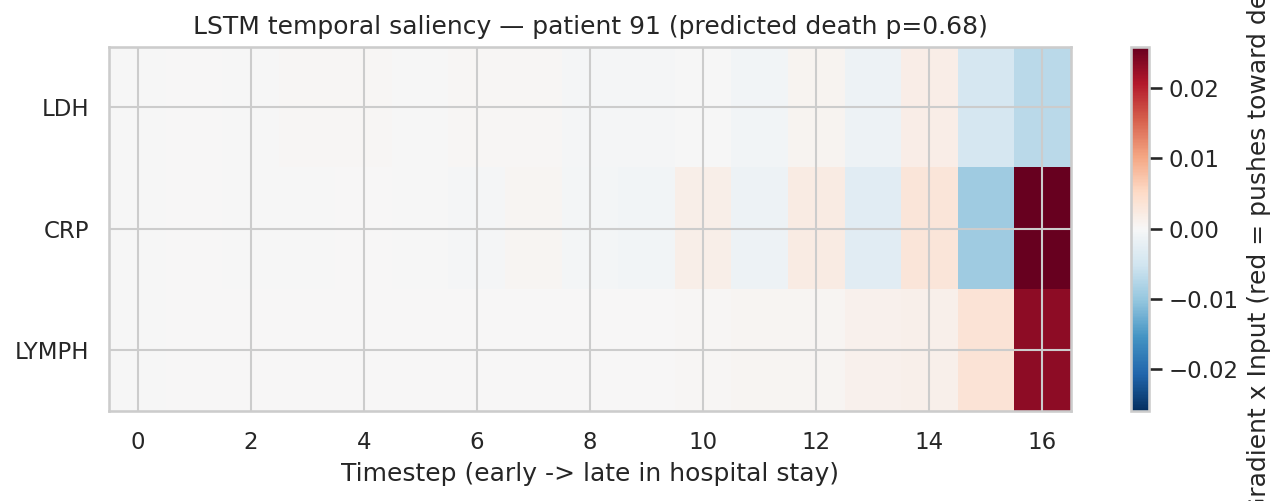


[OK] Saved: lstm_temporal_saliency_heatmap.png (patient index 90)

TEMPORAL XAI SUMMARY
  Top biomarker (LSTM)       : LYMPH
  Mean attribution peak time : 0.30 (0=first, 1=last)
  Temporal faithfulness @k=5 : 0.1429
  (peak time near 1 would mean the LSTM mostly uses the last measurements)


In [23]:
if TORCH_AVAILABLE:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy.stats import spearmanr

    OUTPUT_DIR.mkdir(exist_ok=True)
    lstm_model.eval()

    # 1. Gradient x Input: attr = x * d(logit)/dx, padding set to 0 after

    X_test_grad = torch.tensor(X_seq_test, dtype=torch.float32, requires_grad=True)
    mask_test_t = torch.tensor(mask_test, dtype=torch.bool)
    test_lengths = lengths_from_mask(mask_test_t)

    logits = lstm_model(X_test_grad, test_lengths)
    # summing is fine, each patient only depends on its own input
    logits.sum().backward()

    grads = X_test_grad.grad.detach().numpy()
    attributions = grads * X_seq_test
    # drop the time channel and padding
    attributions = attributions[:, :, :len(BIOMARKERS)]
    attributions = attributions * mask_test[:, :, None]

    print(f"[OK] Computed Gradient x Input attributions: {attributions.shape} "
          f"(patients, timesteps, biomarkers)")

    # 2. Per biomarker: sum over time, mean over patients

    abs_attr = np.abs(attributions)
    per_patient_biomarker = abs_attr.sum(axis=1)
    lstm_biomarker_importance = per_patient_biomarker.mean(axis=0)

    lstm_imp_df = pd.DataFrame({
        "biomarker": BIOMARKERS,
        "lstm_grad_x_input": lstm_biomarker_importance,
    }).sort_values("lstm_grad_x_input", ascending=False)
    # as fractions so it compares with SHAP
    lstm_imp_df["lstm_normalized"] = (
        lstm_imp_df["lstm_grad_x_input"] / lstm_imp_df["lstm_grad_x_input"].sum()
    )
    lstm_imp_df.to_csv(OUTPUT_DIR / "lstm_biomarker_importance.csv", index=False)

    print("\nLSTM biomarker importance (Gradient x Input, rolled up over time):")
    print(lstm_imp_df.round(4).to_string(index=False))

    # 3. Does the LSTM agree with tabular SHAP?

    try:
        tabular_rank = (
            biomarker_shap_df.set_index("biomarker")["mean_abs_shap"]
            if "mean_abs_shap" in biomarker_shap_df.columns
            else biomarker_shap_df.set_index("biomarker").iloc[:, 0]
        )
        lstm_rank = lstm_imp_df.set_index("biomarker")["lstm_grad_x_input"]

        aligned = pd.DataFrame({
            "tabular_shap": tabular_rank,
            "lstm_grad": lstm_rank,
        }).dropna()

        rho, pval = spearmanr(aligned["tabular_shap"], aligned["lstm_grad"])
        print(f"\nCross-model biomarker-ranking agreement (Spearman): rho = {rho:.3f}")
        print("  (Do the tabular and temporal models agree on WHICH biomarkers matter?)")
        print(aligned.round(4).to_string())
        agreement_available = True
    except (NameError, KeyError) as e:
        print(f"\n[NOTE] Could not auto-align with tabular SHAP table ({e}).")
        print("       Set tabular_rank manually from Cell 14's biomarker table.")
        rho = np.nan
        agreement_available = False

    # 4. Where in the stay is the peak (0 = first measurement, 1 = last)

    peak_positions = []
    for i in range(attributions.shape[0]):
        n_steps = int(mask_test[i].sum())
        if n_steps < 2:
            continue
        per_step = abs_attr[i, :n_steps, :].sum(axis=1)
        peak_step = per_step.argmax()
        peak_positions.append(peak_step / (n_steps - 1))

    peak_positions = np.array(peak_positions)
    print(f"\nTemporal localization of attribution (n={len(peak_positions)} patients):")
    print(f"  Mean peak position : {peak_positions.mean():.2f}  (0=first measurement, 1=last)")
    print(f"  Fraction peaking in last third of stay: "
          f"{(peak_positions > 0.66).mean():.2f}")
    print("  -> If this clusters near 1.0, the LSTM relies mostly on the LAST")
    print("     measurements, which would explain why it matches our 'last value'")
    print("     summary features (the hypothesis from Cell 21).")

    # 5. Faithfulness: set the top-k cells to 0 (the mean) and see how much the prediction drops

    def lstm_proba(X_arr):
        with torch.no_grad():
            xt = torch.tensor(X_arr, dtype=torch.float32)
            lg = lstm_model(xt, lengths_from_mask(mask_test_t))
            return torch.sigmoid(lg).numpy()

    base_proba = lstm_proba(X_seq_test)
    K_VALUES = [1, 3, 5, 10]
    faith_rows = []

    for k in K_VALUES:
        X_occluded = X_seq_test.copy()
        for i in range(X_occluded.shape[0]):
            flat = abs_attr[i].flatten()
            if flat.sum() == 0:
                continue
            top_idx = np.argsort(flat)[-k:]
            for idx in top_idx:
                t, c = np.unravel_index(idx, abs_attr[i].shape)
                X_occluded[i, t, c] = 0.0
        occ_proba = lstm_proba(X_occluded)
        # only patients predicted as deaths
        died_pred = base_proba >= 0.5
        drop = (base_proba[died_pred] - occ_proba[died_pred]).mean() if died_pred.any() else 0.0
        faith_rows.append({"k": k, "mean_prob_drop": drop})
        print(f"  k={k:2d}: mean death-probability drop after occluding top-{k} cells = {drop:.4f}")

    faith_df = pd.DataFrame(faith_rows)
    faith_df.to_csv(OUTPUT_DIR / "lstm_temporal_faithfulness.csv", index=False)

    # 6. Heatmap for one confident death

    death_preds = np.where((base_proba >= 0.5) & (y_seq_test == 1))[0]
    if len(death_preds) > 0:
        ex = death_preds[np.argmax(base_proba[death_preds])]
        n_steps = int(mask_test[ex].sum())
        heat = attributions[ex, :n_steps, :].T

        fig, ax = plt.subplots(figsize=(9, 3.5))
        vmax = np.abs(heat).max() + 1e-9
        im = ax.imshow(heat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_yticks(range(len(BIOMARKERS)))
        ax.set_yticklabels(BIOMARKERS)
        ax.set_xlabel("Timestep (early -> late in hospital stay)")
        ax.set_title(f"LSTM temporal saliency - patient {int(ids_test.iloc[ex])} "
                     f"(predicted death p={base_proba[ex]:.2f})")
        fig.colorbar(im, ax=ax, label="Gradient x Input (red = pushes toward death)")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "lstm_temporal_saliency_heatmap.png", dpi=150)
        plt.show()
        print(f"\n[OK] Saved: lstm_temporal_saliency_heatmap.png (patient index {ex})")

    # 7. Summary
    print("\n" + "=" * 60)
    print("TEMPORAL XAI SUMMARY")
    print("=" * 60)
    print(f"  Top biomarker (LSTM)       : {lstm_imp_df.iloc[0]['biomarker']}")
    if agreement_available:
        print(f"  Agreement with tabular SHAP: Spearman rho = {rho:.3f}")
    print(f"  Mean attribution peak time : {peak_positions.mean():.2f} (0=first, 1=last)")
    print(f"  Temporal faithfulness @k=5 : {faith_df.loc[faith_df['k']==5,'mean_prob_drop'].values[0]:.4f}")
    print("  (peak time near 1 would mean the LSTM mostly uses the last measurements)")
    print("=" * 60)

else:
    print("[SKIP] Cell 22 requires the trained LSTM from Cell 21 (PyTorch not available).")

## Explaining the LSTM: WindowSHAP
Second temporal method, based on Shapley values like SHAP. The 24 steps are split into 4 windows and each (window, biomarker) block is one feature for KernelSHAP (Nayebi et al., 2023). We wrote it ourselves with shap's KernelExplainer instead of using the original script. Run on 25 patients because it is slow.

WindowSHAP setup: 4 windows x 3 biomarkers = 12 coalition features
  Each window spans 6 timesteps.

Running WindowSHAP on 25 patients (KernelSHAP per patient - this is the slow step)...
  ...5/25 patients done
  ...10/25 patients done
  ...15/25 patients done
  ...20/25 patients done
  ...25/25 patients done
[OK] WindowSHAP values computed.

WindowSHAP biomarker importance (rolled up over windows):
biomarker  windowshap  windowshap_normalized
    LYMPH      0.0839                 0.4552
      CRP      0.0593                 0.3215
      LDH      0.0412                 0.2233


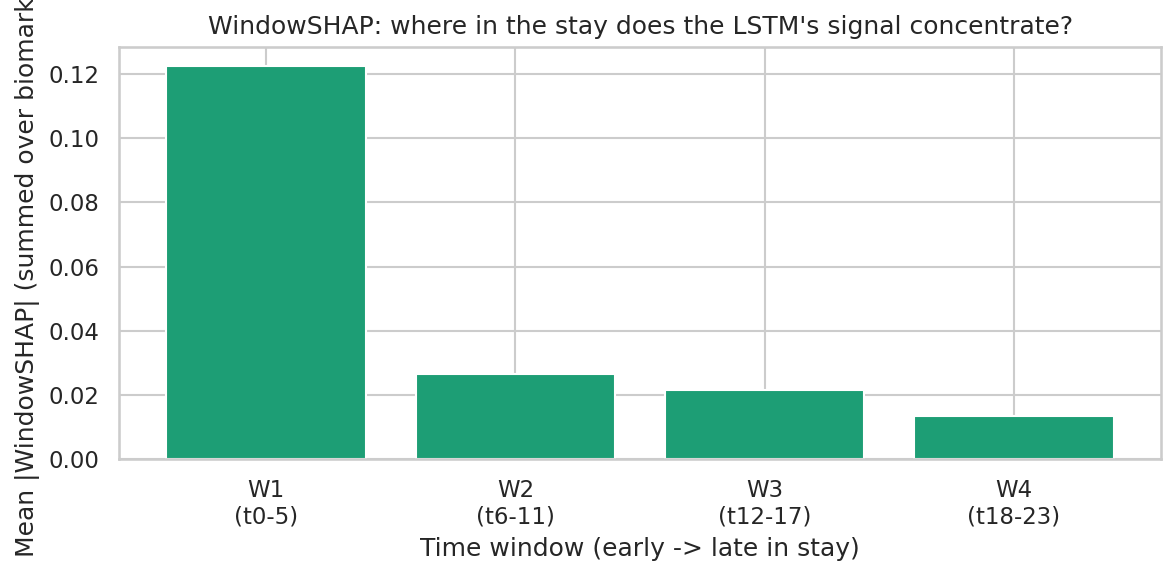


[OK] Saved: windowshap_temporal_profile.png
  Most important window: W1 (timesteps (0, 6))
  -> If the LAST window dominates, this corroborates the Cell 22
     finding that the LSTM leans on late measurements.

Cell 23 complete - WindowSHAP biomarker importances ready for the
four-method comparison in the next cell.


In [24]:
if TORCH_AVAILABLE:
    import numpy as np
    import pandas as pd
    import shap
    import matplotlib.pyplot as plt

    lstm_model.eval()
    mask_test_t = torch.tensor(mask_test, dtype=torch.bool)

    # 1. Split the 24 steps into windows, each (window, biomarker) is one SHAP feature

    N_WINDOWS = 4                      # 4 windows of 6 steps
    n_biomarkers = len(BIOMARKERS)
    win_size = MAX_SEQ_LEN // N_WINDOWS
    window_bounds = [(w * win_size, (w + 1) * win_size) for w in range(N_WINDOWS)]
    # feature index = window * n_biomarkers + biomarker
    n_coalition_features = N_WINDOWS * n_biomarkers

    print(f"WindowSHAP setup: {N_WINDOWS} windows x {n_biomarkers} biomarkers "
          f"= {n_coalition_features} coalition features")
    print(f"  Each window spans {win_size} timesteps.")

    # masked blocks are set to 0, which is the train mean after normalising
    BACKGROUND_VALUE = 0.0

    def lstm_predict_from_flat(coalition_matrix, base_sequence, base_mask):
        """
        1 in the coalition = keep that (window, biomarker) block, 0 = set it to the background.
        Returns P(death) for every masked version.
        """
        n_samples = coalition_matrix.shape[0]
        X_variants = np.tile(base_sequence[None, :, :], (n_samples, 1, 1)).astype(np.float32)

        for s in range(n_samples):
            for feat in range(n_coalition_features):
                if coalition_matrix[s, feat] == 0:
                    w_idx = feat // n_biomarkers
                    b_idx = feat % n_biomarkers
                    t0, t1 = window_bounds[w_idx]
                    X_variants[s, t0:t1, b_idx] = BACKGROUND_VALUE

        with torch.no_grad():
            xt = torch.tensor(X_variants, dtype=torch.float32)
            lengths = torch.clamp(base_mask.sum().repeat(n_samples), min=1)
            logits = lstm_model(xt, lengths)
            return torch.sigmoid(logits).numpy()

    # 2. Run on a subset, KernelSHAP is slow (same subset as LIME if we have it)

    try:
        ws_subset = list(lime_subset_indices)
    except NameError:
        ws_subset = list(range(min(25, X_seq_test.shape[0])))

    print(f"\nRunning WindowSHAP on {len(ws_subset)} patients "
          f"(KernelSHAP per patient - this is the slow step)...")

    windowshap_values = np.zeros((len(ws_subset), N_WINDOWS, n_biomarkers))

    for si, i in enumerate(ws_subset):
        base_seq = X_seq_test[i]
        base_m = mask_test_t[i]

        f = lambda C: lstm_predict_from_flat(C, base_seq, base_m)
        background = np.zeros((1, n_coalition_features))
        explainer = shap.KernelExplainer(f, background)
        present = np.ones((1, n_coalition_features))
        sv = explainer.shap_values(present, nsamples=200, silent=True)
        sv = np.array(sv).reshape(N_WINDOWS, n_biomarkers)
        windowshap_values[si] = sv

        if (si + 1) % 5 == 0:
            print(f"  ...{si + 1}/{len(ws_subset)} patients done")

    print("[OK] WindowSHAP values computed.")

    # 3. Per biomarker

    abs_ws = np.abs(windowshap_values)
    ws_biomarker_importance = abs_ws.sum(axis=1).mean(axis=0)

    ws_imp_df = pd.DataFrame({
        "biomarker": BIOMARKERS,
        "windowshap": ws_biomarker_importance,
    }).sort_values("windowshap", ascending=False)
    ws_imp_df["windowshap_normalized"] = (
        ws_imp_df["windowshap"] / ws_imp_df["windowshap"].sum()
    )
    ws_imp_df.to_csv(OUTPUT_DIR / "windowshap_biomarker_importance.csv", index=False)

    print("\nWindowSHAP biomarker importance (rolled up over windows):")
    print(ws_imp_df.round(4).to_string(index=False))

    # 4. Importance per window (early vs late)

    per_window_importance = abs_ws.sum(axis=2).mean(axis=0)
    window_labels = [f"W{w+1}\n(t{window_bounds[w][0]}-{window_bounds[w][1]-1})"
                     for w in range(N_WINDOWS)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(window_labels, per_window_importance, color="#1D9E75")
    ax.set_ylabel("Mean |WindowSHAP| (summed over biomarkers)")
    ax.set_xlabel("Time window (early -> late in stay)")
    ax.set_title("WindowSHAP: where in the stay does the LSTM's signal concentrate?")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "windowshap_temporal_profile.png", dpi=150)
    plt.show()
    print("\n[OK] Saved: windowshap_temporal_profile.png")
    print(f"  Most important window: W{per_window_importance.argmax()+1} "
          f"(timesteps {window_bounds[per_window_importance.argmax()]})")
    print("  -> If the LAST window dominates, this corroborates the Cell 22")
    print("     finding that the LSTM leans on late measurements.")

    print("\n" + "=" * 60)
    print("Cell 23 complete - WindowSHAP biomarker importances ready for the")
    print("four-method comparison in the next cell.")
    print("=" * 60)

else:
    print("[SKIP] Cell 23 requires the trained LSTM from Cell 21.")

## Comparing all four methods
All four methods are brought down to one importance per biomarker, so they can be compared. They are different algorithms, so the question is whether they agree, not whether they measure the same thing.

[NOTE] lime_feature_importance not found - pulling LIME from its saved CSV or skipping. Set it from your LIME cell if this column is missing.
FOUR-METHOD BIOMARKER IMPORTANCE (normalized fractions, sum=1 per column)
           SHAP (tabular)  Grad x Input (temporal)  WindowSHAP (temporal)
biomarker                                                                
LDH                 0.490                    0.199                  0.223
CRP                 0.322                    0.282                  0.321
LYMPH               0.188                    0.520                  0.455

Rank per method (1 = most important biomarker):
           SHAP (tabular)  Grad x Input (temporal)  WindowSHAP (temporal)
biomarker                                                                
LDH                     1                        3                      3
CRP                     2                        2                      2
LYMPH                   3                        1                   

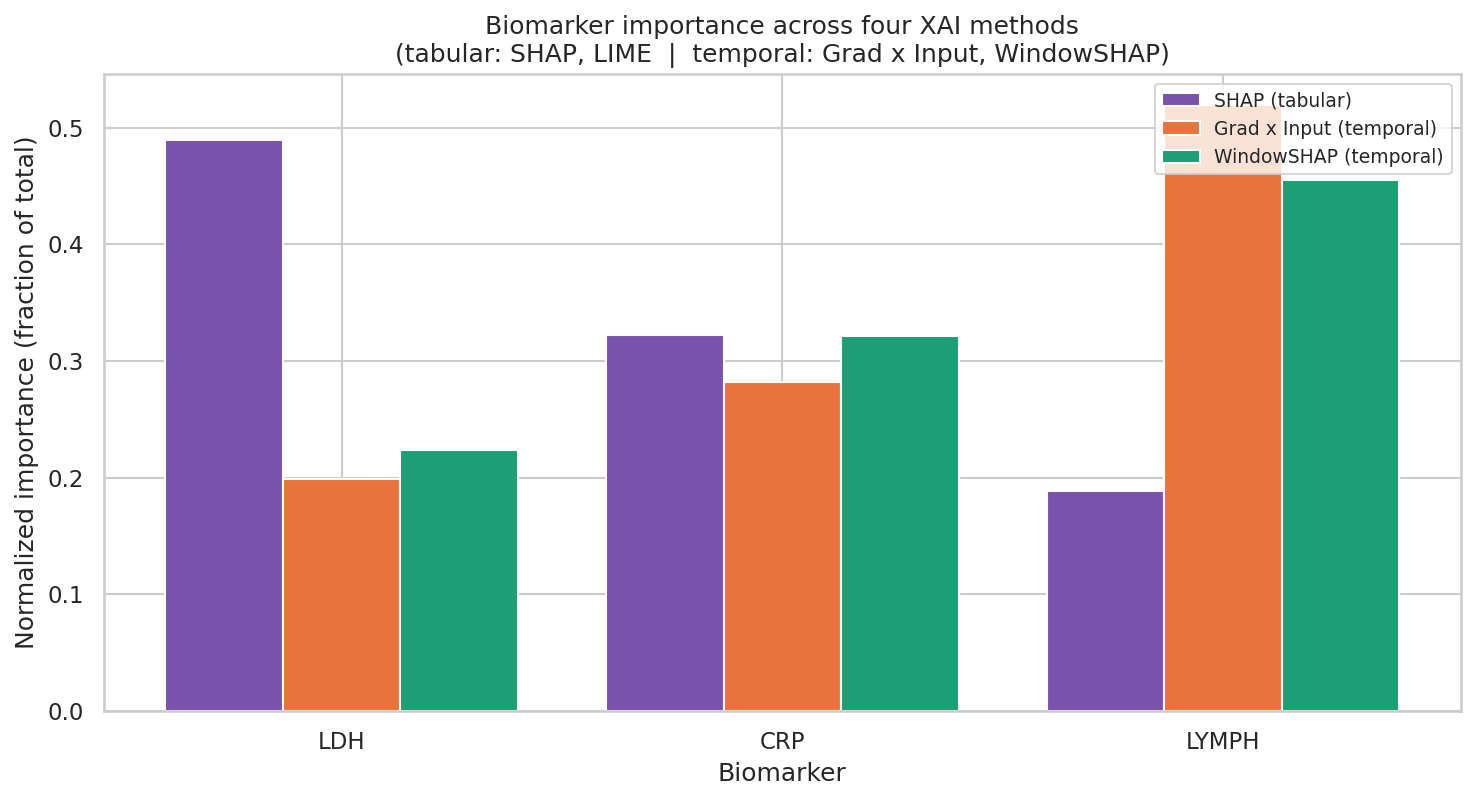


[OK] Saved: four_method_comparison_barchart.png

DETAILED VIEW 1 - Tabular SHAP, top 12 of 30 features
(the granularity the biomarker rollup hides: is it the LAST value,
 the SLOPE, the MAX that drives risk?)
            feature  shap_mean_abs
           LDH_last         0.1096
           CRP_last         0.0660
          LYMPH_min         0.0188
         LYMPH_last         0.0173
           CRP_mean         0.0075
         LYMPH_mean         0.0070
  LDH_slope_per_day         0.0050
            CRP_min         0.0029
            LDH_max         0.0026
          LDH_first         0.0017
          LYMPH_max         0.0014
LYMPH_slope_per_day         0.0012


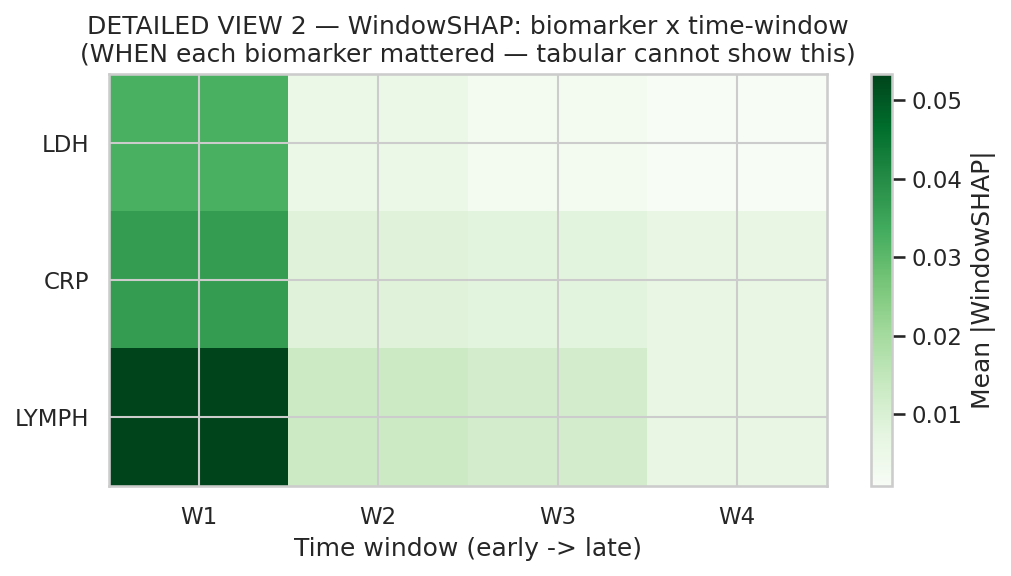


[OK] Saved: windowshap_biomarker_window_heatmap.png

SUMMARY
  Headline figure : four_method_comparison_barchart.png
  Comparison table: four_method_biomarker_comparison.csv
  Agreement matrix: four_method_agreement_spearman.csv
  Detail (tabular): tabular_full_feature_ranking.csv  (which feature TYPE)
  Detail (temporal): windowshap_biomarker_window_heatmap.png  (which TIME)

  Across all four methods, the most important biomarker is: LYMPH
  Tabular shows which feature type mattered, temporal shows when.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Biomarker importance for each method, as fractions that sum to 1

def normalize(d):
    s = sum(d.values())
    return {k: (v / s if s else 0.0) for k, v in d.items()}

method_importances = {}

# SHAP
shap_abs_mean = np.abs(shap_vals_xgb).mean(axis=0)
shap_by_biomarker = {b: 0.0 for b in BIOMARKERS}
for j, feat in enumerate(feature_cols):
    for b in BIOMARKERS:
        if feat.startswith(b + "_"):
            shap_by_biomarker[b] += shap_abs_mean[j]
method_importances["SHAP (tabular)"] = normalize(shap_by_biomarker)

# LIME
try:
    lime_by_biomarker = {b: 0.0 for b in BIOMARKERS}
    for feat, w in lime_feature_importance.items():
        for b in BIOMARKERS:
            if feat.startswith(b + "_"):
                lime_by_biomarker[b] += abs(w)
    method_importances["LIME (tabular)"] = normalize(lime_by_biomarker)
except NameError:
    print("[NOTE] lime_feature_importance not found - pulling LIME from its saved CSV "
          "or skipping. Set it from your LIME cell if this column is missing.")

# Grad x Input
try:
    grad_by_biomarker = dict(zip(lstm_imp_df["biomarker"], lstm_imp_df["lstm_grad_x_input"]))
    method_importances["Grad x Input (temporal)"] = normalize(grad_by_biomarker)
except NameError:
    print("[NOTE] lstm_imp_df (Cell 22) not found - run Cell 22 first for Grad x Input.")

# WindowSHAP
try:
    ws_by_biomarker = dict(zip(ws_imp_df["biomarker"], ws_imp_df["windowshap"]))
    method_importances["WindowSHAP (temporal)"] = normalize(ws_by_biomarker)
except NameError:
    print("[NOTE] ws_imp_df (Cell 23) not found - run Cell 23 first for WindowSHAP.")

# 2. Table

comparison = pd.DataFrame(method_importances).reindex(BIOMARKERS)
comparison.index.name = "biomarker"
comparison.to_csv(OUTPUT_DIR / "four_method_biomarker_comparison.csv")

print("=" * 64)
print("FOUR-METHOD BIOMARKER IMPORTANCE (normalized fractions, sum=1 per column)")
print("=" * 64)
print(comparison.round(3).to_string())

# rank per method
rankings = comparison.rank(ascending=False).astype(int)
print("\nRank per method (1 = most important biomarker):")
print(rankings.to_string())

# 3. Spearman between each pair of methods

methods = list(comparison.columns)
agree = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m1 in methods:
    for m2 in methods:
        rho, _ = spearmanr(comparison[m1], comparison[m2])
        agree.loc[m1, m2] = rho
agree = agree.astype(float)
agree.to_csv(OUTPUT_DIR / "four_method_agreement_spearman.csv")

print("\nPairwise agreement (Spearman rho of biomarker importance):")
print(agree.round(2).to_string())

# tabular vs temporal agreement
tab_methods = [m for m in methods if "tabular" in m]
tmp_methods = [m for m in methods if "temporal" in m]
cross_vals = [agree.loc[a, b] for a in tab_methods for b in tmp_methods]
if cross_vals:
    print(f"\nMean tabular<->temporal agreement: {np.mean(cross_vals):.2f}")
    print("  (High = the two data representations agree on WHICH biomarkers matter,")
    print("   despite using completely different models and explanation methods.)")

# 4. Bar chart

fig, ax = plt.subplots(figsize=(10, 5.5))
n_methods = len(methods)
x = np.arange(len(BIOMARKERS))
width = 0.8 / n_methods
palette = ["#7B52AB", "#E8743B", "#1D9E75", "#3B8BD4", "#D4537E"]

for k, m in enumerate(methods):
    offset = (k - (n_methods - 1) / 2) * width
    ax.bar(x + offset, comparison[m].values, width, label=m, color=palette[k % len(palette)])

ax.set_xticks(x)
ax.set_xticklabels(BIOMARKERS)
ax.set_ylabel("Normalized importance (fraction of total)")
ax.set_xlabel("Biomarker")
ax.set_title("Biomarker importance across four XAI methods\n"
             "(tabular: SHAP, LIME  |  temporal: Grad x Input, WindowSHAP)")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "four_method_comparison_barchart.png", dpi=150)
plt.show()
print("\n[OK] Saved: four_method_comparison_barchart.png")

# 5. Top features for tabular SHAP (which of the 10 per biomarker)

tabular_detail = pd.DataFrame({
    "feature": feature_cols,
    "shap_mean_abs": shap_abs_mean,
}).sort_values("shap_mean_abs", ascending=False)
tabular_detail.to_csv(OUTPUT_DIR / "tabular_full_feature_ranking.csv", index=False)

print("\n" + "=" * 64)
print("DETAILED VIEW 1 - Tabular SHAP, top 12 of 30 features")
print("(the granularity the biomarker rollup hides: is it the LAST value,")
print(" the SLOPE, the MAX that drives risk?)")
print("=" * 64)
print(tabular_detail.head(12).round(4).to_string(index=False))

# 6. WindowSHAP heatmap (when each biomarker mattered)

if TORCH_AVAILABLE:
    try:
        mean_ws = np.abs(windowshap_values).mean(axis=0)
        fig, ax = plt.subplots(figsize=(7, 4))
        im = ax.imshow(mean_ws.T, aspect="auto", cmap="Greens")
        ax.set_yticks(range(len(BIOMARKERS)))
        ax.set_yticklabels(BIOMARKERS)
        ax.set_xticks(range(N_WINDOWS))
        ax.set_xticklabels([f"W{w+1}" for w in range(N_WINDOWS)])
        ax.set_xlabel("Time window (early -> late)")
        ax.set_title("DETAILED VIEW 2 - WindowSHAP: biomarker x time-window\n"
                     "(WHEN each biomarker mattered - tabular cannot show this)")
        fig.colorbar(im, ax=ax, label="Mean |WindowSHAP|")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "windowshap_biomarker_window_heatmap.png", dpi=150)
        plt.show()
        print("\n[OK] Saved: windowshap_biomarker_window_heatmap.png")
    except NameError:
        print("[NOTE] windowshap_values not found - run Cell 23 for the temporal heatmap.")

# 7. Summary
print("\n" + "=" * 64)
print("SUMMARY")
print("=" * 64)
print("  Headline figure : four_method_comparison_barchart.png")
print("  Comparison table: four_method_biomarker_comparison.csv")
print("  Agreement matrix: four_method_agreement_spearman.csv")
print("  Detail (tabular): tabular_full_feature_ranking.csv  (which feature TYPE)")
print("  Detail (temporal): windowshap_biomarker_window_heatmap.png  (which TIME)")
top_biomarker = comparison.mean(axis=1).idxmax()
print(f"\n  Across all four methods, the most important biomarker is: {top_biomarker}")
print("  Tabular shows which feature type mattered, temporal shows when.")
print("=" * 64)

## One patient, two models
The same patient explained by XGBoost + SHAP and by LSTM + WindowSHAP.

Comparing explanations for patient 86 (test index 85); died=1


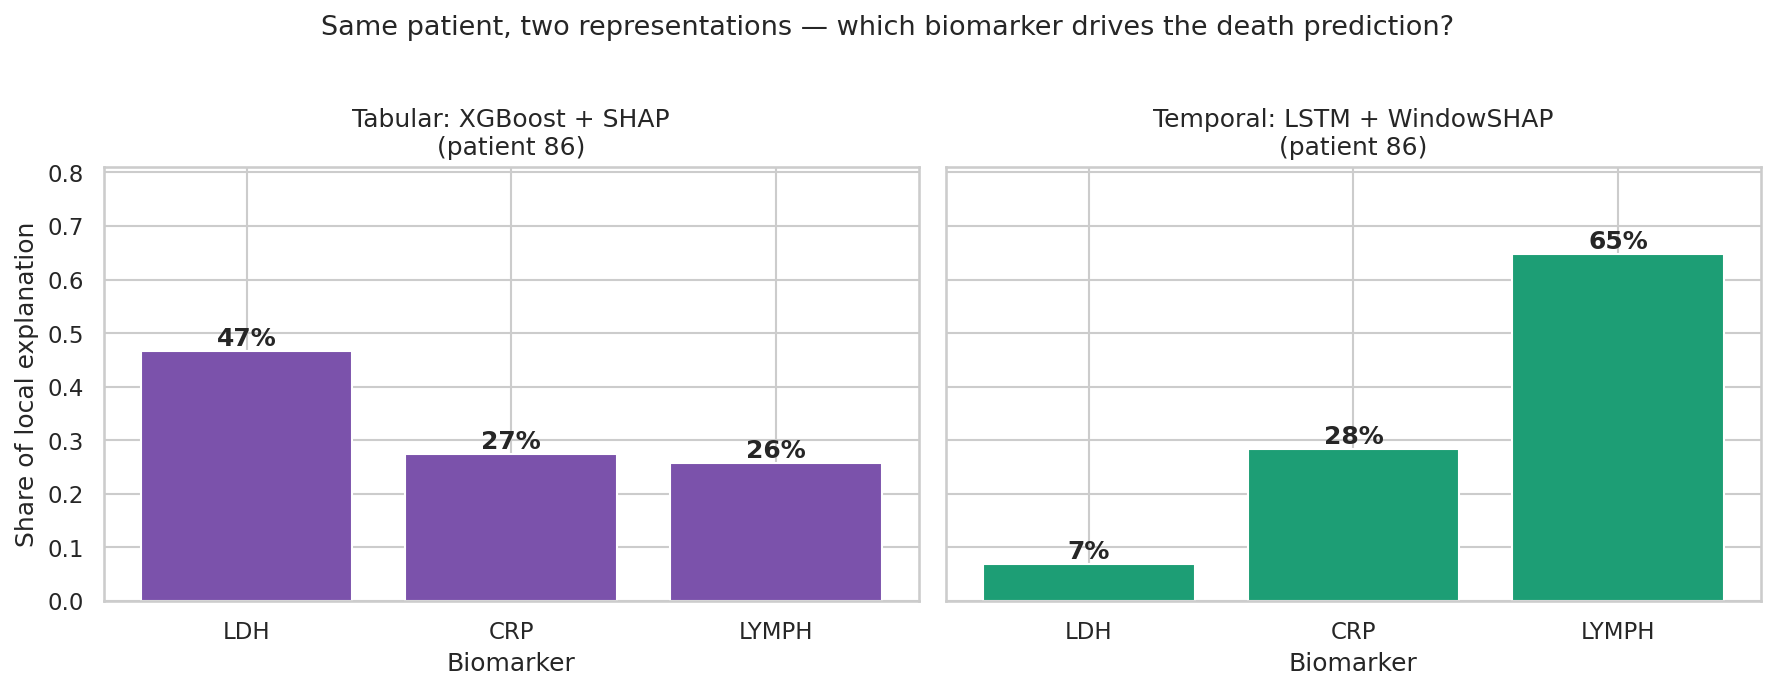

[OK] Saved: local_shap_vs_windowshap_same_patient.png

LOCAL CONTRAST - patient 86
  Tabular (SHAP)      top biomarker: LDH  (47% of local explanation)
  Temporal (WindowSHAP) top biomarker: LYMPH  (65% of local explanation)

  -> For the SAME patient, the two representations disagree on the
     primary driver: LDH (tabular) vs LYMPH (temporal).
     This is the four-method global finding, shown locally.


In [26]:
if TORCH_AVAILABLE:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1. Pick a patient who died, was predicted as death, and has WindowSHAP values

    base_proba_lstm = None
    try:
        # LSTM probabilities
        with torch.no_grad():
            xt = torch.tensor(X_seq_test, dtype=torch.float32)
            lengths = lengths_from_mask(torch.tensor(mask_test, dtype=torch.bool))
            base_proba_lstm = torch.sigmoid(lstm_model(xt, lengths)).numpy()
    except Exception as e:
        print(f"[NOTE] Could not recompute LSTM probabilities ({e}); using y as fallback.")

    chosen = None
    for si, idx in enumerate(ws_subset):
        died = (y_seq_test[idx] == 1)
        pred_death = (base_proba_lstm[idx] >= 0.5) if base_proba_lstm is not None else died
        if died and pred_death:
            chosen = (si, idx)
            break
    if chosen is None:                       # otherwise just take one from the subset
        chosen = (0, ws_subset[0])
    ws_pos, test_idx = chosen
    patient_id = int(ids_test.iloc[test_idx]) if hasattr(ids_test, "iloc") else int(test_idx)
    print(f"Comparing explanations for patient {patient_id} "
          f"(test index {test_idx}); died={int(y_seq_test[test_idx])}")

    # 2. Tabular SHAP per biomarker
    shap_row = np.abs(shap_vals_xgb[test_idx])
    tab_by_biomarker = {b: 0.0 for b in BIOMARKERS}
    for j, feat in enumerate(feature_cols):
        for b in BIOMARKERS:
            if feat.startswith(b + "_"):
                tab_by_biomarker[b] += shap_row[j]
    tab_total = sum(tab_by_biomarker.values()) or 1.0
    tab_frac = {b: tab_by_biomarker[b] / tab_total for b in BIOMARKERS}

    # 3. WindowSHAP per biomarker, same patient
    ws_patient = np.abs(windowshap_values[ws_pos])
    tmp_by_biomarker = ws_patient.sum(axis=0)
    tmp_total = tmp_by_biomarker.sum() or 1.0
    tmp_frac = {BIOMARKERS[k]: tmp_by_biomarker[k] / tmp_total for k in range(len(BIOMARKERS))}

    # 4. Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    tab_vals = [tab_frac[b] for b in BIOMARKERS]
    tmp_vals = [tmp_frac[b] for b in BIOMARKERS]

    axes[0].bar(BIOMARKERS, tab_vals, color="#7B52AB")
    axes[0].set_title(f"Tabular: XGBoost + SHAP\n(patient {patient_id})")
    axes[0].set_ylabel("Share of local explanation")
    for i, v in enumerate(tab_vals):
        axes[0].text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")

    axes[1].bar(BIOMARKERS, tmp_vals, color="#1D9E75")
    axes[1].set_title(f"Temporal: LSTM + WindowSHAP\n(patient {patient_id})")
    for i, v in enumerate(tmp_vals):
        axes[1].text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")

    for ax in axes:
        ax.set_ylim(0, max(max(tab_vals), max(tmp_vals)) * 1.25)
        ax.set_xlabel("Biomarker")

    plt.suptitle(
        f"Same patient, two representations - which biomarker drives the death prediction?",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "local_shap_vs_windowshap_same_patient.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Saved: local_shap_vs_windowshap_same_patient.png")

    # 5. Print
    tab_top = max(tab_frac, key=tab_frac.get)
    tmp_top = max(tmp_frac, key=tmp_frac.get)
    print("\n" + "=" * 60)
    print(f"LOCAL CONTRAST - patient {patient_id}")
    print("=" * 60)
    print(f"  Tabular (SHAP)      top biomarker: {tab_top}  "
          f"({tab_frac[tab_top]:.0%} of local explanation)")
    print(f"  Temporal (WindowSHAP) top biomarker: {tmp_top}  "
          f"({tmp_frac[tmp_top]:.0%} of local explanation)")
    if tab_top != tmp_top:
        print(f"\n  -> For the SAME patient, the two representations disagree on the")
        print(f"     primary driver: {tab_top} (tabular) vs {tmp_top} (temporal).")
        print(f"     This is the four-method global finding, shown locally.")
    else:
        print(f"\n  -> Both agree the primary driver is {tab_top} for this patient.")
    print("=" * 60)

else:
    print("[SKIP] Cell 25 requires the LSTM (Cell 21) and WindowSHAP (Cell 23).")

## WindowSHAP over all patients
The plots above are for one patient. Here the WindowSHAP values are averaged over the 25 patients.

Using Cell 23's WindowSHAP values: 25 patients.


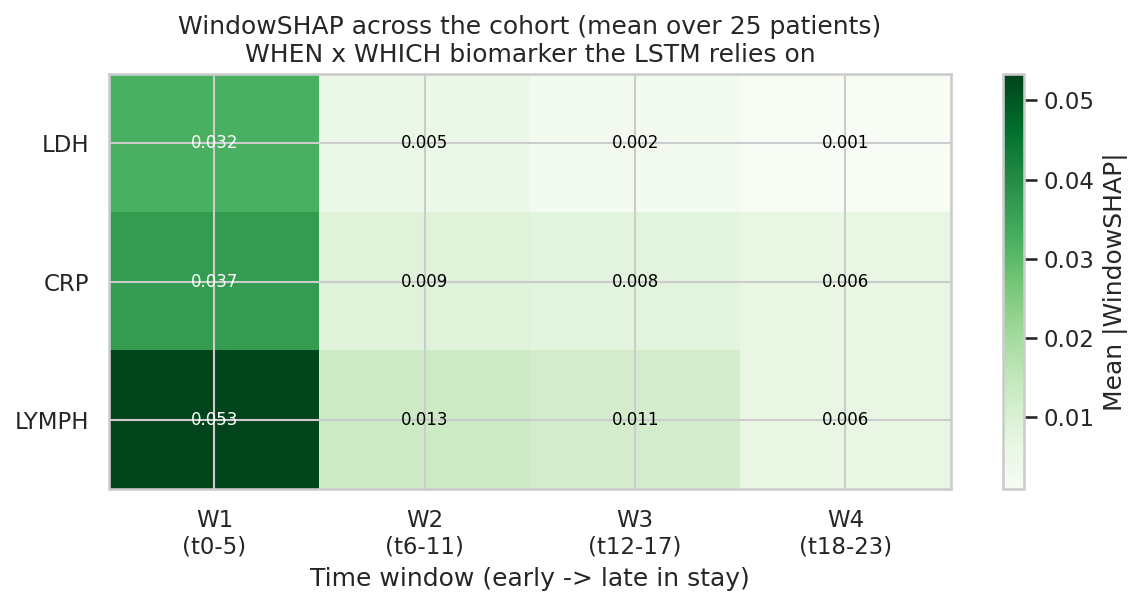

[OK] Saved: windowshap_cohort_heatmap.png


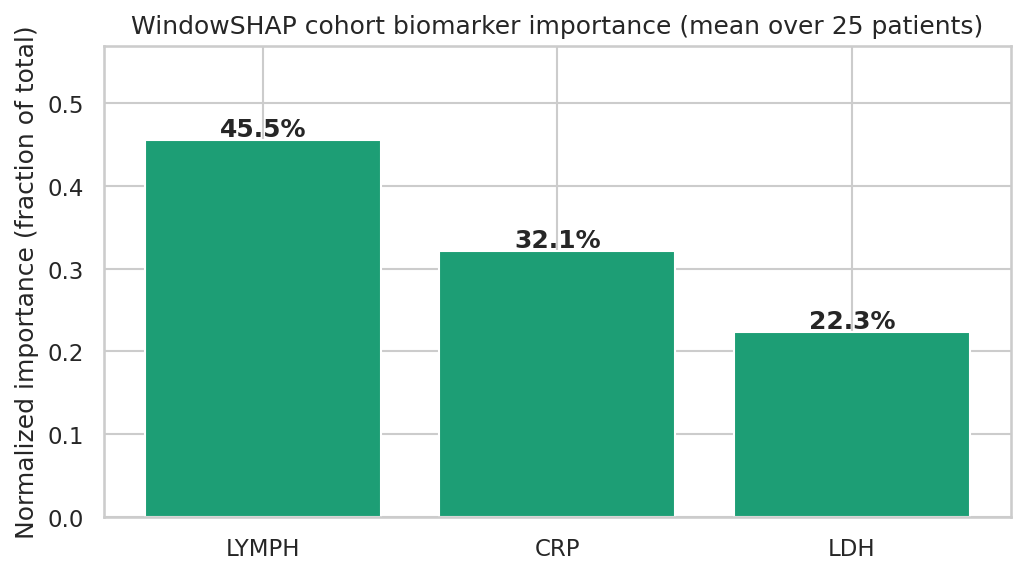


Cohort biomarker importance:
biomarker  mean_abs_windowshap  normalized
    LYMPH               0.0839      0.4552
      CRP               0.0593      0.3215
      LDH               0.0412      0.2233
[OK] Saved: windowshap_cohort_biomarker_bar.png


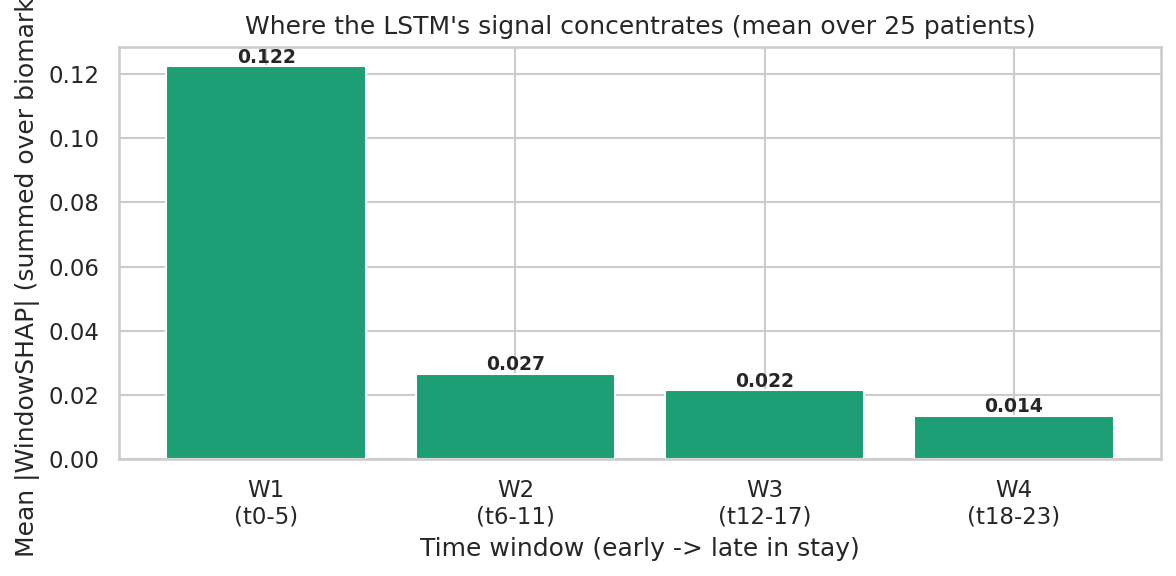


[OK] Saved: windowshap_cohort_temporal_profile.png

COHORT WINDOWSHAP SUMMARY  (n = 25 patients)
  Top biomarker (cohort)   : LYMPH (45.5%)
  Most important window    : W1 (timesteps (0, 6))
  Share of signal in W1    : 66.4%
  -> This is the population-level version of the single-patient
     figure: across patients, the LSTM relies most on LYMPH in the early window.


In [27]:
if TORCH_AVAILABLE:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # set to True to run on all 110 test patients (slow, 10-25 min)
    RUN_ALL = False

    if RUN_ALL:
        import shap
        print("RUN_ALL=True -> recomputing WindowSHAP on every test patient (slow)...")
        all_idx = list(range(X_seq_test.shape[0]))
        N = len(all_idx)
        windowshap_all = np.zeros((N, N_WINDOWS, len(BIOMARKERS)))
        for si, i in enumerate(all_idx):
            base_seq = X_seq_test[i]
            base_m   = torch.tensor(mask_test[i], dtype=torch.bool)
            f = lambda C: lstm_predict_from_flat(C, base_seq, base_m)
            background = np.zeros((1, N_WINDOWS * len(BIOMARKERS)))
            explainer  = shap.KernelExplainer(f, background)
            present    = np.ones((1, N_WINDOWS * len(BIOMARKERS)))
            sv = explainer.shap_values(present, nsamples=200, silent=True)
            windowshap_all[si] = np.array(sv).reshape(N_WINDOWS, len(BIOMARKERS))
            if (si + 1) % 10 == 0:
                print(f"  ...{si+1}/{N} patients done")
        ws_array = windowshap_all
        print(f"[OK] WindowSHAP computed for all {N} patients.")
    else:
        ws_array = windowshap_values     # the subset
        print(f"Using Cell 23's WindowSHAP values: {ws_array.shape[0]} patients.")

    abs_ws = np.abs(ws_array)
    n_patients = abs_ws.shape[0]

    # 1. Cohort-average biomarker x window heatmap
    mean_heat = abs_ws.mean(axis=0)

    fig, ax = plt.subplots(figsize=(8, 4.2))
    im = ax.imshow(mean_heat.T, aspect="auto", cmap="Greens")
    ax.set_yticks(range(len(BIOMARKERS)))
    ax.set_yticklabels(BIOMARKERS)
    ax.set_xticks(range(N_WINDOWS))
    ax.set_xticklabels([f"W{w+1}\n(t{window_bounds[w][0]}-{window_bounds[w][1]-1})"
                        for w in range(N_WINDOWS)])
    ax.set_xlabel("Time window (early -> late in stay)")
    ax.set_title(f"WindowSHAP across the cohort (mean over {n_patients} patients)\n"
                 f"WHEN x WHICH biomarker the LSTM relies on")
    fig.colorbar(im, ax=ax, label="Mean |WindowSHAP|")
    for w in range(N_WINDOWS):
        for b in range(len(BIOMARKERS)):
            ax.text(w, b, f"{mean_heat[w, b]:.3f}", ha="center", va="center",
                    color="black" if mean_heat[w, b] < mean_heat.max()*0.6 else "white",
                    fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "windowshap_cohort_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[OK] Saved: windowshap_cohort_heatmap.png")

    # 2. Cohort biomarker importance (rolled up over windows)
    biomarker_imp = abs_ws.sum(axis=1).mean(axis=0)
    imp_df = pd.DataFrame({
        "biomarker": BIOMARKERS,
        "mean_abs_windowshap": biomarker_imp,
        "normalized": biomarker_imp / biomarker_imp.sum(),
    }).sort_values("mean_abs_windowshap", ascending=False)
    imp_df.to_csv(OUTPUT_DIR / "windowshap_cohort_biomarker_importance.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    order = imp_df["biomarker"].tolist()
    vals  = imp_df["normalized"].tolist()
    bars  = ax.bar(order, vals, color="#1D9E75")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.1%}",
                ha="center", fontweight="bold")
    ax.set_ylabel("Normalized importance (fraction of total)")
    ax.set_title(f"WindowSHAP cohort biomarker importance (mean over {n_patients} patients)")
    ax.set_ylim(0, max(vals)*1.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "windowshap_cohort_biomarker_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nCohort biomarker importance:")
    print(imp_df.round(4).to_string(index=False))
    print("[OK] Saved: windowshap_cohort_biomarker_bar.png")

    # 3. Per-window temporal profile (cohort average)
    per_window = abs_ws.sum(axis=2).mean(axis=0)
    fig, ax = plt.subplots(figsize=(8, 4))
    wlabels = [f"W{w+1}\n(t{window_bounds[w][0]}-{window_bounds[w][1]-1})"
               for w in range(N_WINDOWS)]
    bars = ax.bar(wlabels, per_window, color="#1D9E75")
    for bar, v in zip(bars, per_window):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f"{v:.3f}",
                ha="center", fontweight="bold", fontsize=9)
    ax.set_ylabel("Mean |WindowSHAP| (summed over biomarkers)")
    ax.set_xlabel("Time window (early -> late in stay)")
    ax.set_title(f"Where the LSTM's signal concentrates (mean over {n_patients} patients)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "windowshap_cohort_temporal_profile.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n[OK] Saved: windowshap_cohort_temporal_profile.png")

    # summary
    top_b = imp_df.iloc[0]["biomarker"]
    top_w = int(per_window.argmax()) + 1
    frac_w1 = per_window[0] / per_window.sum()
    print("\n" + "=" * 60)
    print(f"COHORT WINDOWSHAP SUMMARY  (n = {n_patients} patients)")
    print("=" * 60)
    print(f"  Top biomarker (cohort)   : {top_b} "
          f"({imp_df.iloc[0]['normalized']:.1%})")
    print(f"  Most important window    : W{top_w} "
          f"(timesteps {window_bounds[top_w-1]})")
    print(f"  Share of signal in W1    : {frac_w1:.1%}")
    print("  -> This is the population-level version of the single-patient")
    print("     figure: across patients, the LSTM relies most on", top_b,
          "in the early window.")
    print("=" * 60)

else:
    print("[SKIP] Cell 26 requires the LSTM (Cell 21) and WindowSHAP (Cell 23).")